In [4]:
import os
import sys
import django

# Pastikan path ke folder root benar
project_root = "c:/babyspa-data"
if project_root not in sys.path:
    sys.path.append(project_root)

# PERBAIKAN: Gunakan 'core.settings' sesuai isi file settings.py kamu
os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'core.settings')
os.environ["DJANGO_ALLOW_ASYNC_UNSAFE"] = "true"

try:
    django.setup()
    print("✅ Django berhasil diinisialisasi menggunakan core.settings!")
except Exception as e:
    print(f"❌ Gagal inisialisasi: {e}")

# Sekarang baru import service dari app babyspa_data
from babyspa_data.services.ahp_service import AHPService

✅ Django berhasil diinisialisasi menggunakan core.settings!


In [5]:
from django.db import connection, transaction

with transaction.atomic():
    with connection.cursor() as cursor:
        # 1. Matikan proteksi foreign key sementara (khusus SQLite)
        cursor.execute("PRAGMA foreign_keys = OFF;")
        
        # 2. Hancurkan data di tabel perantara Many-to-Many
        cursor.execute("DELETE FROM babyspa_data_productrecommendation_antecedent;")
        cursor.execute("DELETE FROM babyspa_data_productrecommendation_consequent;")
        
        # 3. Hancurkan data di tabel induk rekomendasi
        cursor.execute("DELETE FROM babyspa_data_productrecommendation;")
        
        # 4. Hidupkan kembali proteksi
        cursor.execute("PRAGMA foreign_keys = ON;")

print("✅ Semua data perantara yang mengunci migrasi berhasil dibersihkan!")

✅ Semua data perantara yang mengunci migrasi berhasil dibersihkan!


In [6]:
from babyspa_data.models.customer_segment import CustomerSegment
from babyspa_data.models.cluster_lrfm import ClusterLRFM
from babyspa_data.models.product import ProductScore, ProductRecommendation
CustomerSegment.active_objects.all().delete(hard=True)
ClusterLRFM.active_objects.all().delete(hard=True)
ProductScore.active_objects.all().delete(hard=True)
ProductRecommendation.active_objects.all().delete(hard=True)
print("✅ Data berhasil dihapus dari tabel CustomerSegment, ClusterLRFM, ProductScore, dan ProductRecommendation!")

✅ Data berhasil dihapus dari tabel CustomerSegment, ClusterLRFM, ProductScore, dan ProductRecommendation!


In [7]:
from babyspa_data.models.cluster_lrfm import LRFMReference

# Data berdasarkan gambar yang diunggah
lrfm_data = [
    ("↑↑↑↑", "Core Loyal Customer", "Pelanggan Inti"),
    ("↑↑↑↓", "Core High-Frequency Customer", "Pelanggan Inti"),
    ("↑↑↓↑", "Core Platinum Customer", "Pelanggan Inti"),
    ("↓↑↑↑", "Potential Loyal Customer", "Pelanggan Potensial"),
    ("↓↑↑↓", "Potential High-Frequency Customer", "Pelanggan Potensial"),
    ("↓↑↓↑", "Potential High-Value Customer", "Pelanggan Potensial"),
    ("↑↓↑↑", "Lost High-Value Customer", "Pelanggan Hilang"),
    ("↑↓↑↓", "Lost High-Frequency Customer", "Pelanggan Hilang"),
    ("↑↓↓↑", "Lost High-Consumption Customer", "Pelanggan Hilang"),
    ("↑↓↓↓", "Lost Uncertain Customer", "Pelanggan Hilang"),
    ("↓↓↓↓", "New Active Customer", "Pelanggan Baru"),
    ("↓↓↑↓", "New Promotional Customer", "Pelanggan Baru"),
]

for symbol, group, main in lrfm_data:
    LRFMReference.active_objects.get_or_create(
        symbol=symbol,
        defaults={'group_name': group, 'main_category': main}
    )
print("Master LRFMReference berhasil diperbarui.")

Master LRFMReference berhasil diperbarui.


In [8]:
# Data tambahan untuk melengkapi 16 kombinasi simbol L-R-F-M
# Ini hanya akan menambah data yang belum ada (get_or_create)
lrfm_additional_data = [
    # --- Segmen Dormant (High L, Low R) ---
    ("↑↓↓↓", "Hibernating Customer", "Pelanggan Berisiko"),
    ("↑↑↓↓", "Stable Warm Customer", "Pelanggan Inti"),
    
    # --- Segmen One-Time/Promosional (Low L, Low R) ---
    ("↓↓↑↑", "Lost Potential", "Pelanggan Hilang"),
    ("↓↓↓↑", "One-Time Big Spender", "Pelanggan Hilang"),
    ("↓↓↓↓", "Inactive Newbie", "Pelanggan Baru"),
    
    # --- Segmen New Active (Low L, High R) ---
    ("↓↑↓↓", "New Active Customer", "Pelanggan Baru"),
]

for symbol, group, main in lrfm_additional_data:
    LRFMReference.active_objects.get_or_create(
        symbol=symbol,
        defaults={
            'group_name': group, 
            'main_category': main,
            'description': f"Segmen otomatis untuk simbol {symbol}"
        }
    )
print("Kombinasi tambahan LRFMReference berhasil ditambahkan.")

Kombinasi tambahan LRFMReference berhasil ditambahkan.


In [9]:
import pandas as pd

# 1. Menampilkan seluruh isi teks dalam sel (tidak dipotong ...)
pd.set_option('display.max_colwidth', None)

# 2. Menampilkan semua kolom (jika dataframe punya banyak kolom)
pd.set_option('display.max_columns', None)

# 3. Menampilkan semua baris (hati-hati jika data sangat besar)
# pd.set_option('display.max_rows', None) 

# 4. Mengatur lebar tampilan agar tidak terbungkus (wrap) ke baris baru
pd.set_option('display.width', 1000)

## RAW EXPLORATION

In [10]:
import pandas as pd
import re
from babyspa_data.services.raw_exploration import RawDataExplorer, mask_customer_name, clean_price


=== 1. EKSPLORASI MASTER CUSTOMERS ===
=== Head of Data Pelanggan ===


,ID,Name,Membership ID,Blocked,Block Reason,Appointments,No Shows,Total Sales,Total Invoice,Outstanding,Gender,Mobile Number,Telephone,Email,Tags,Accepts Marketing,Adress,Date of Birth,Added,Last Visit,Note,Loyalty Point
0,14784756,H***U,NaN,No,0,1,0,0.00,0,0,M,"6,281,235,583,593.00",NaN,NaN,NaN,No,BANGIREJO,2018-02-01,2026-03-17 02:23:55,2026-03-17 09:23:55,NaN,0
1,14784743,A***I,NaN,No,0,1,0,0.00,0,0,F,"6,285,655,391,341.00",NaN,NaN,NaN,No,BAUSASRAN,1989-07-10,2026-03-17 02:20:37,2026-03-17 09:20:37,NaN,0
2,14784700,E***O,NaN,No,0,1,0,0.00,0,0,M,"6,287,870,786,888.00",NaN,NaN,NaN,No,PURI GADING AA-9,2025-09-09,2026-03-17 02:08:28,2026-03-17 09:08:28,NaN,0
3,14784679,J***a,NaN,No,0,1,0,0.00,0,0,F,"6,281,225,018,881.00",NaN,NaN,NaN,No,"Purbowardayan RT 01/ 02, Tegalharjo, Jebres.",2023-09-05,2026-03-17 02:01:25,2026-03-17 09:01:25,NaN,0
4,14784632,Q***I,NaN,No,0,1,0,0.00,0,0,F,"6,281,391,214,188.00",NaN,NaN,NaN,No,DEMANGAN YK,2020-05-05,2026-03-17 01:41:55,2026-03-17 08:41:55,NaN,0


=== Basic Info: Data Pelanggan ===
Total Baris: 23749 | Total Kolom: 22
Jumlah Duplikat (Baris): 0



,Tipe Data,Total Non-Null,Total Null,Persentase Null (%)
ID,int64,23749,0,0.00
Name,str,23749,0,0.00
Membership ID,str,17861,5888,24.79
Blocked,str,23749,0,0.00
Block Reason,int64,23749,0,0.00
Appointments,int64,23749,0,0.00
No Shows,int64,23749,0,0.00
Total Sales,float64,23749,0,0.00
Total Invoice,int64,23749,0,0.00
Outstanding,int64,23749,0,0.00


=== Categorical Summary: Data Pelanggan ===

Kolom: Gender | Unique Values: 3
Gender
F          11691
M           8954
disable     2848
Name: count, dtype: int64
------------------------------


None

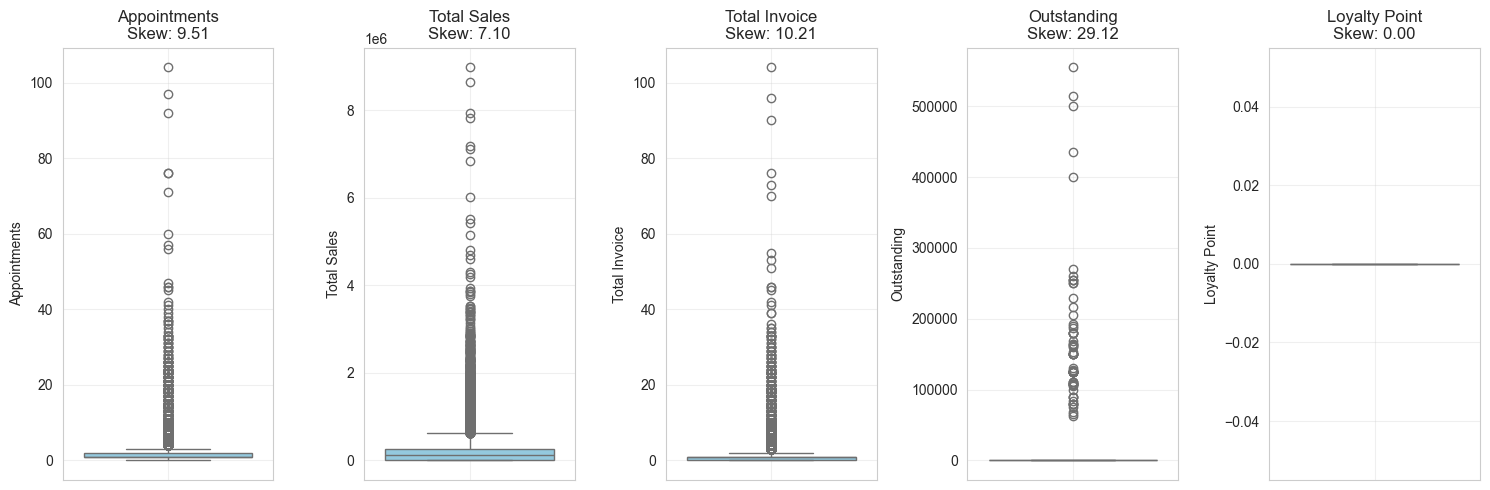

,Fitur,Skewness,Kurtosis,Outlier_IQR (%),Median (P50),P99,Max (P100),Gap Max/P99,Severity,Rekomendasi
0,Appointments,9.51,176.78,10.6%,1.00,15.00,104.00,6.93,EXTREME,Praproses Lanjut Dibutuhkan
1,Total Sales,7.10,99.40,6.3%,"127,500.00","1,626,580.00","8,982,000.00",5.52,EXTREME,Praproses Lanjut Dibutuhkan
2,Total Invoice,10.21,205.44,13.9%,1.00,14.00,104.00,7.43,EXTREME,Praproses Lanjut Dibutuhkan
3,Outstanding,29.12,"1,073.61",0.3%,0.00,0.00,"555,000.00",Infinite,EXTREME,Praproses Lanjut Dibutuhkan
4,Loyalty Point,0.00,0.00,0.0%,0.00,0.00,0.00,Infinite,LOW,Aman / Optional


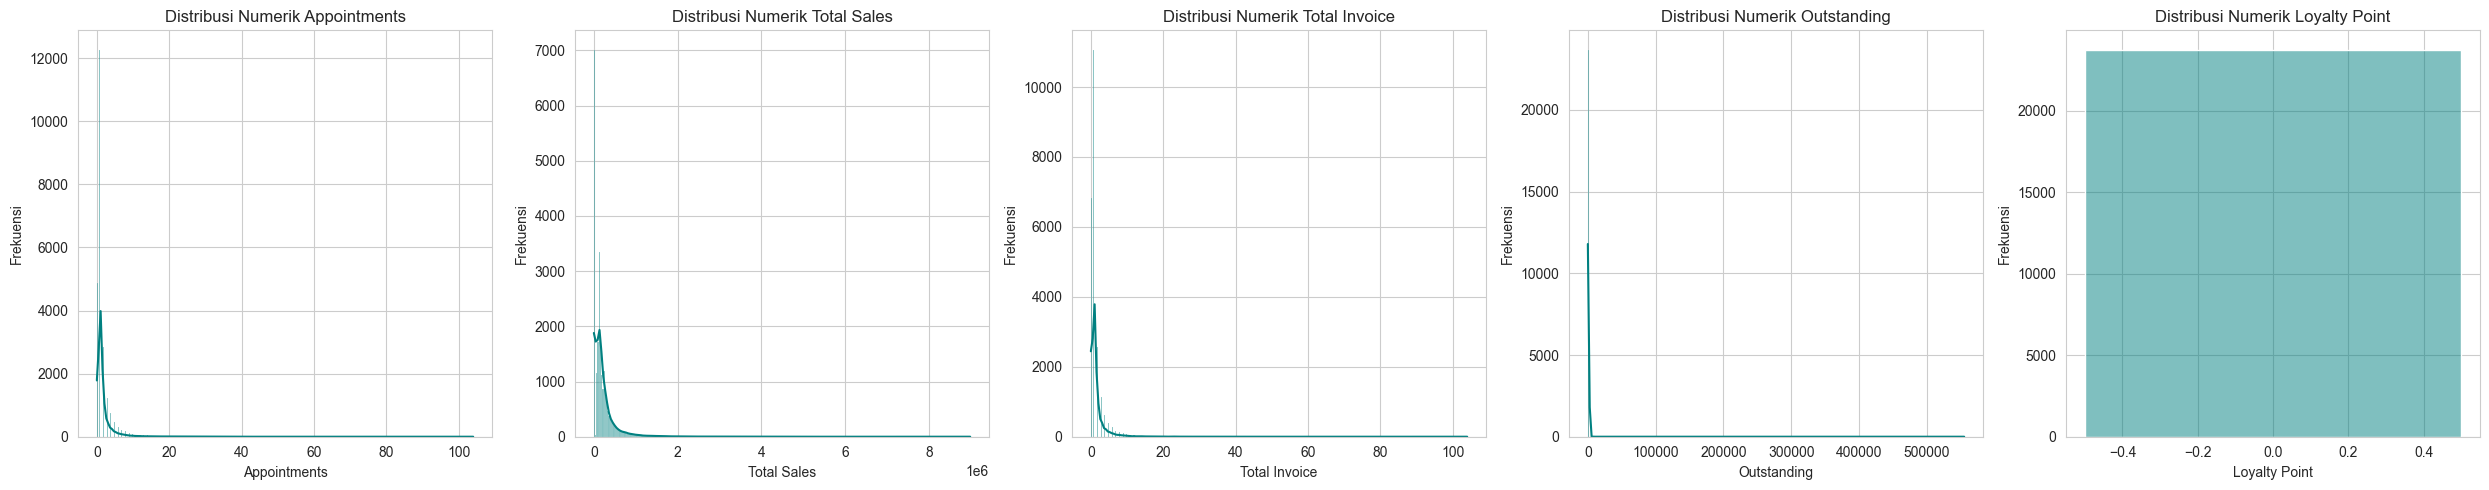

In [11]:
# --- 1. EKSPLORASI MASTER CUSTOMERS ---
print("=== 1. EKSPLORASI MASTER CUSTOMERS ===")
df_customers = pd.read_csv('data/raw/master_customers.csv')

if 'Name' in df_customers.columns:
    df_customers['Name'] = df_customers['Name'].apply(mask_customer_name)

exp_cust = RawDataExplorer(df_customers, "Data Pelanggan")
display(exp_cust.get_head(5))
display(exp_cust.get_basic_info())
display(exp_cust.get_categorical_summary(['Gender']))

cust_num_cols = exp_cust.get_numeric_cols()
if cust_num_cols:
    display(exp_cust.diagnose_outliers(cust_num_cols, show_plot=True))
    exp_cust.plot_distributions(cust_num_cols)


=== 2. EKSPLORASI MASTER ITEMS ===
=== Head of Data Produk ===


,Type,Treatment Name,Group Name,Item Name,Variant Name,Description,Retail Price,Special Price,Duration,Gender,Enable Point,Extra Time,Extra Time Mins,Enable Online,Enable At Customer Location,Cost Price,Material
0,Service,Body Massage,MASSAGE,SUNNY BABY AND KID MASSAGE,NaN,CEK TUMBUH KEMBANG + MASSAGE (45') + INFRARED (0-3 MONTH),"135,000.00","0,00",45min,Everyone,0,N,0,1,1,"0,00",NaN
1,Service,Body Massage,SUNNY BRIGHT BABY 3-12 M,SUNNY BRIGHT BABY 3-12 M,NaN,CEK TUMBUH KEMBANG + SWIM (15') + MASSAGE (45') + INFRARED (3-12 MONTH),"165,000.00","0,00",1h,Everyone,0,N,0,1,1,"0,00",NaN
2,Service,Body Massage,MASSAGE,BABY AND KID MASSAGE,NaN,CEK TUMBUH KEMBANG + MASSAGE (45') + INFRARED,"90,000.00","0,00",45min,Everyone,0,N,0,1,1,"0,00",NaN
3,Service,Body Massage,SUNNY BRIGHT BABY 3-12 M,SUNNY BRIGHT BABY,NaN,CEK TUMBUH KEMBANG + SWIM (15') + MASSAGE (45') + INFRARED,"135,000.00","0,00",1h,Everyone,0,N,0,1,1,"0,00",NaN
4,Service,Body Massage,SUNNY BRIGHT KIDS,BRIGHT KIDS,NaN,CEK TUMBUH KEMBANG + MASSAGE (40') + RENDAM BUBBLE (20') + INFRARED,"160,000.00","0,00",1h,Everyone,0,N,0,1,1,"0,00",NaN


=== Basic Info: Data Produk ===
Total Baris: 98 | Total Kolom: 17
Jumlah Duplikat (Baris): 0



,Tipe Data,Total Non-Null,Total Null,Persentase Null (%)
Type,str,98,0,0.00
Treatment Name,str,98,0,0.00
Group Name,str,98,0,0.00
Item Name,str,98,0,0.00
Variant Name,str,5,93,94.90
Description,str,43,55,56.12
Retail Price,float64,98,0,0.00
Special Price,str,98,0,0.00
Duration,str,98,0,0.00
Gender,str,98,0,0.00


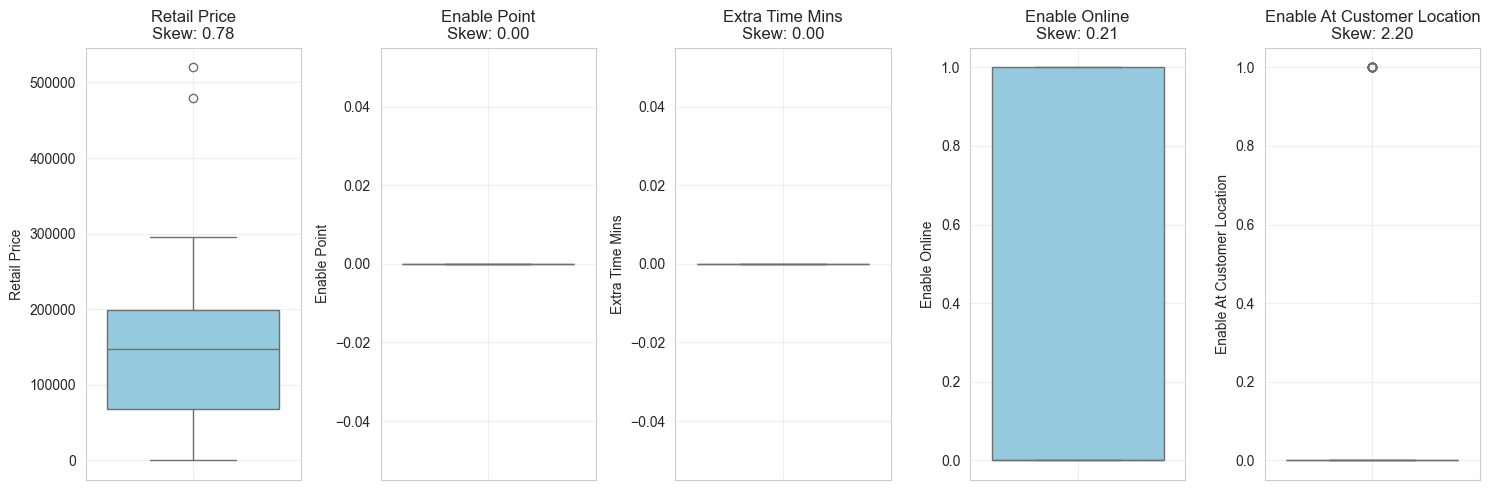

,Fitur,Skewness,Kurtosis,Outlier_IQR (%),Median (P50),P99,Max (P100),Gap Max/P99,Severity,Rekomendasi
0,Retail Price,0.78,1.98,2.0%,"147,500.00","481,200.00","520,000.00",1.08,LOW,Aman / Optional
1,Enable Point,0.00,0.00,0.0%,0.00,0.00,0.00,Infinite,LOW,Aman / Optional
2,Extra Time Mins,0.00,0.00,0.0%,0.00,0.00,0.00,Infinite,LOW,Aman / Optional
3,Enable Online,0.21,-2.00,0.0%,0.00,1.00,1.00,1.00,LOW,Aman / Optional
4,Enable At Customer Location,2.20,2.90,13.3%,0.00,1.00,1.00,1.00,HIGH,Saran Winsor (0.99)


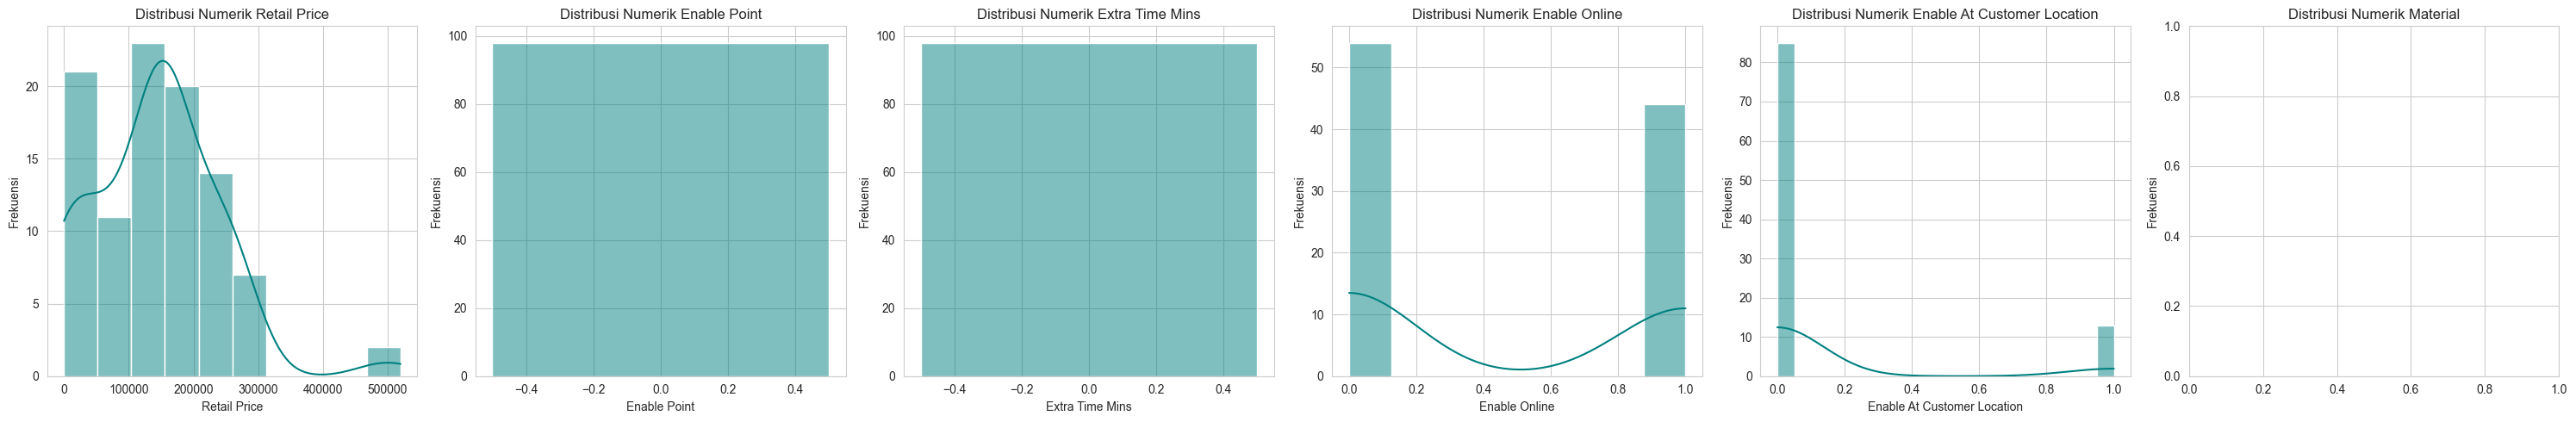

In [12]:
# --- 2. EKSPLORASI MASTER ITEMS ---
print("\n=== 2. EKSPLORASI MASTER ITEMS ===")
df_items = pd.read_csv('data/raw/master_items.csv')
df_items['Retail Price'] = df_items['Retail Price'].apply(clean_price)
exp_items = RawDataExplorer(df_items, "Data Produk")

display(exp_items.get_head(5))
display(exp_items.get_basic_info())

item_num_cols = exp_items.get_numeric_cols()
if item_num_cols:
    display(exp_items.diagnose_outliers(item_num_cols, show_plot=True))
    exp_items.plot_distributions(item_num_cols)

if 'addons?' in df_items.columns:
    print("\nDistribusi Produk Add-ons:")
    print(df_items['addons?'].value_counts())


In [13]:
df_items

,Type,Treatment Name,Group Name,Item Name,Variant Name,Description,Retail Price,Special Price,Duration,Gender,Enable Point,Extra Time,Extra Time Mins,Enable Online,Enable At Customer Location,Cost Price,Material
0,Service,Body Massage,MASSAGE,SUNNY BABY AND KID MASSAGE,NaN,CEK TUMBUH KEMBANG + MASSAGE (45') + INFRARED (0-3 MONTH),"135,000.00","0,00",45min,Everyone,0,N,0,1,1,"0,00",NaN
1,Service,Body Massage,SUNNY BRIGHT BABY 3-12 M,SUNNY BRIGHT BABY 3-12 M,NaN,CEK TUMBUH KEMBANG + SWIM (15') + MASSAGE (45') + INFRARED (3-12 MONTH),"165,000.00","0,00",1h,Everyone,0,N,0,1,1,"0,00",NaN
2,Service,Body Massage,MASSAGE,BABY AND KID MASSAGE,NaN,CEK TUMBUH KEMBANG + MASSAGE (45') + INFRARED,"90,000.00","0,00",45min,Everyone,0,N,0,1,1,"0,00",NaN
3,Service,Body Massage,SUNNY BRIGHT BABY 3-12 M,SUNNY BRIGHT BABY,NaN,CEK TUMBUH KEMBANG + SWIM (15') + MASSAGE (45') + INFRARED,"135,000.00","0,00",1h,Everyone,0,N,0,1,1,"0,00",NaN
4,Service,Body Massage,SUNNY BRIGHT KIDS,BRIGHT KIDS,NaN,CEK TUMBUH KEMBANG + MASSAGE (40') + RENDAM BUBBLE (20') + INFRARED,"160,000.00","0,00",1h,Everyone,0,N,0,1,1,"0,00",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,Service,Body Massage,MOM CARE,BUNDLING MID PREGNANCY,NaN,NaN,0.00,"0,00",1h 45min,Everyone,0,N,0,0,0,"0,00",NaN
94,Service,Other,MOM CARE,BUNDLING LAKTASI,NaN,NaN,0.00,"0,00",1h,Female,0,N,0,0,0,"0,00",NaN
95,Service,Body Massage,SUNNY BRIGHT KIDS,SUNNY LITE GRESIK,NaN,NaN,"137,500.00","137.500,00",30min,Everyone,0,N,0,0,0,"0,00",NaN
96,Service,Fisioterapi,GENERAL FISIOTERAPI,DRY NEEDLE,NaN,NaN,"100,000.00","100.000,00",30min,Everyone,0,N,0,0,0,"0,00",NaN


In [14]:
if 'Group  Name' in df_items.columns:
    print("\nDistribusi Nilai pada Kolom Group Name:")
    print(df_items['Group  Name'].value_counts())
    print("-" * 40)


Distribusi Nilai pada Kolom Group Name:
Group  Name
MOM CARE                    27
SUNNY BRIGHT KIDS           14
MASSAGE                     12
COUGH AND COLD TREATMENT    11
SUNNY BRIGHT BABY 3-12 M     9
STIMULASI TUMBUH KEMBANG     9
GENERAL FISIOTERAPI          9
GROOMING BABY                4
GTM TREATMENT                3
Name: count, dtype: int64
----------------------------------------


In [15]:

if 'Treatment Name' in df_items.columns:
    print("\nDistribusi Nilai pada Kolom Treatment Name:")
    print(df_items['Treatment Name'].value_counts())
    print("-" * 40)


Distribusi Nilai pada Kolom Treatment Name:
Treatment Name
Body Massage         45
Fisioterapi          24
Other                16
Pregnancy Massage     9
Hair Cut              4
Name: count, dtype: int64
----------------------------------------



=== 3. EKSPLORASI TRANSACTION HEADERS ===
=== Head of Data Transaksi (Header) ===


,Invoice#,Customer,Status,Invoice Date,Due Date,Invoice Time,Location,Total Tips,Gross total,Branch_ID,Branch_Name
0,17,W***n,PAID,2022-12-31,2022-12-31,31 Dec 2022 12:48,SOLO MANAHAN,0,"250,000.00",4807,Solo_Manahan
1,16,z***l,PAID,2022-12-31,2022-12-31,31 Dec 2022 12:43,SOLO MANAHAN,0,"250,000.00",4807,Solo_Manahan
2,15,d***i,PAID,2022-12-31,2022-12-31,31 Dec 2022 12:36,SOLO MANAHAN,0,"80,000.00",4807,Solo_Manahan
3,14,M***S,VOIDED,2022-12-22,2022-12-22,22 Dec 2022 14:07,SOLO MANAHAN,0,"80,000.00",4807,Solo_Manahan
4,13,M***S,VOIDED,2022-12-22,2022-12-22,22 Dec 2022 13:57,SOLO MANAHAN,0,"80,000.00",4807,Solo_Manahan


=== Basic Info: Data Transaksi (Header) ===
Total Baris: 39080 | Total Kolom: 11
Jumlah Duplikat (Baris): 0



,Tipe Data,Total Non-Null,Total Null,Persentase Null (%)
Invoice#,str,39080,0,0.00
Customer,str,39080,0,0.00
Status,str,39080,0,0.00
Invoice Date,datetime64[us],39080,0,0.00
Due Date,str,39080,0,0.00
Invoice Time,str,39080,0,0.00
Location,str,39080,0,0.00
Total Tips,int64,39080,0,0.00
Gross total,float64,39080,0,0.00
Branch_ID,int64,39080,0,0.00


=== Categorical Summary: Data Transaksi (Header) ===

Kolom: Status | Unique Values: 4
Status
PAID        36828
VOIDED       2169
UNPAID         82
REFUNDED        1
Name: count, dtype: int64
------------------------------

Kolom: Location | Unique Values: 5
Location
SOLO MANAHAN    17592
MAGUWO          10720
SOLO BARU        4435
BAUSASRAN        3997
GRESIK           2336
Name: count, dtype: int64
------------------------------


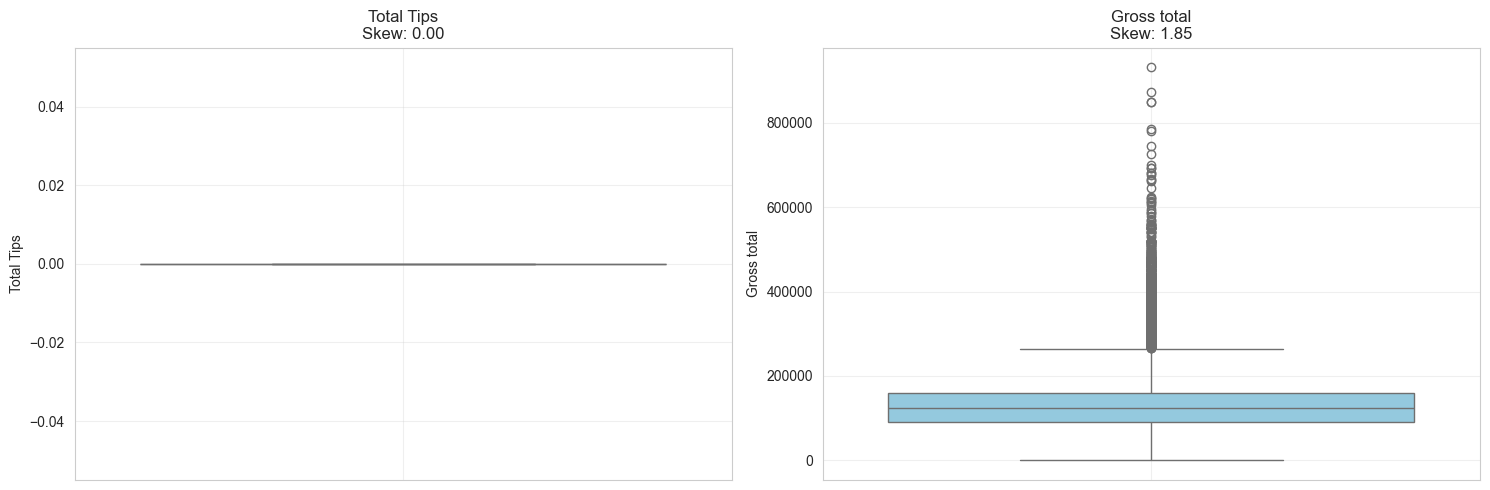

,Fitur,Skewness,Kurtosis,Outlier_IQR (%),Median (P50),P99,Max (P100),Gap Max/P99,Severity,Rekomendasi
0,Total Tips,0.00,0.00,0.0%,0.00,0.00,0.00,Infinite,LOW,Aman / Optional
1,Gross total,1.85,6.83,5.5%,"125,000.00","386,210.00","931,000.00",2.41,EXTREME,Praproses Lanjut Dibutuhkan


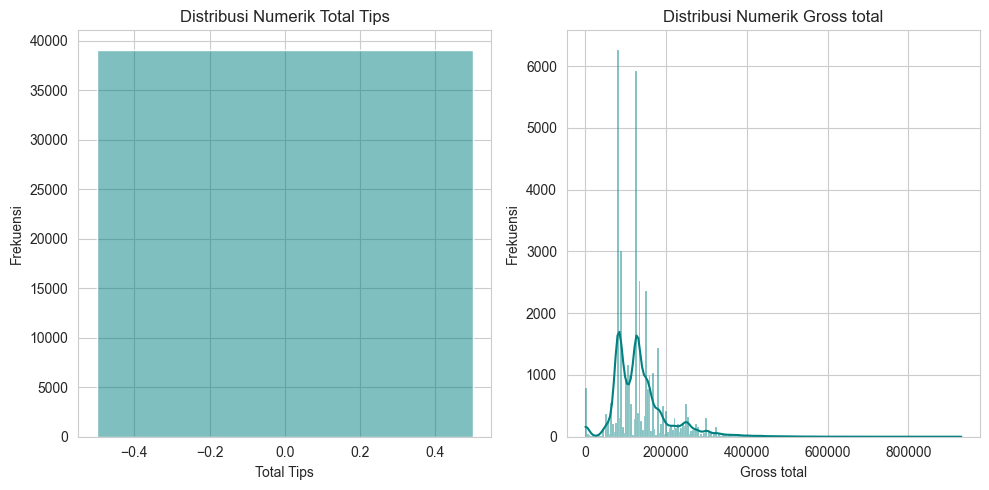

=== Datetime Summary: Data Transaksi (Header) ===

Kolom: Invoice Date
  Tgl Paling Awal (Min) : 2022-12-10 00:00:00
  Tgl Paling Akhir (Max): 2026-03-17 00:00:00
  Rentang Waktu         : 1193 days 00:00:00
----------------------------------------


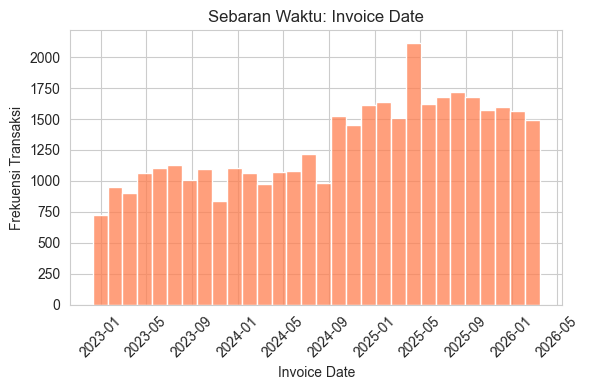

In [16]:
# --- 3. EKSPLORASI TRANSACTION HEADERS ---
print("\n=== 3. EKSPLORASI TRANSACTION HEADERS ===")
df_headers = pd.read_csv('data/raw/master_transaction_headers.csv')

col_gross = 'Gross total' if 'Gross total' in df_headers.columns else 'Gross Total'
if col_gross in df_headers.columns:
    df_headers[col_gross] = pd.to_numeric(
        df_headers[col_gross].astype(str).str.replace(r'[^\d.]', '', regex=True), 
        errors='coerce'
    )

if 'Customer' in df_headers.columns:
    df_headers['Customer'] = df_headers['Customer'].apply(mask_customer_name)

if 'Location' in df_headers.columns:
    df_headers['Location'] = df_headers['Location'].str.replace(r'(?i)sunny\s*', '', regex=True).str.strip()

if 'Branch_Name' in df_headers.columns:
    df_headers['Branch_Name'] = df_headers['Branch_Name'].str.replace(r'(?i)sunny_?', '', regex=True).str.strip()

if 'Invoice Date' in df_headers.columns:
    df_headers['Invoice Date'] = pd.to_datetime(df_headers['Invoice Date'], errors='coerce')

exp_headers = RawDataExplorer(df_headers, "Data Transaksi (Header)")
display(exp_headers.get_head(5))
display(exp_headers.get_basic_info())
exp_headers.get_categorical_summary(['Status', 'Location'])

header_num_cols = exp_headers.get_numeric_cols()
if header_num_cols:
    display(exp_headers.diagnose_outliers(header_num_cols, show_plot=True))
    exp_headers.plot_distributions(header_num_cols)

dt_cols = exp_headers.get_datetime_cols()
if dt_cols:
    exp_headers.get_datetime_summary(dt_cols)
    exp_headers.plot_datetime_distributions(dt_cols)


=== 4. EKSPLORASI TRANSACTION ITEMS ===
=== Head of Data Detail Transaksi (Items) ===


,Ref #,Channel,Created Date,Created By,Client,Service,Location Resource,Scheduled Date,Time,Location,Duration,Staff,Price,Status,Notes,Branch_ID,Branch_Name
0,XW05NK8H,POINT OF SALE,2022-12-31 05:39:19,ADMIN,zizil,MID PREGNANCY SOLO,MOM SPA B,2022-12-31,16:00,SUNNY SOLO MANAHAN,1h 45min,NANDHA AULIA DEWI,"200,000.00",CANCELED,NaN,4807,Solo_Manahan
1,L8G60XCT,POINT OF SALE,2022-12-31 05:52:37,ADMIN,zizil,LACTATION CARE SOLO,MOM SPA B,2022-12-31,10:00,SUNNY SOLO MANAHAN,1h,DESY WIDIYANTI,"135,000.00",NEW,NaN,4807,Solo_Manahan
2,1DEWAR6N,POINT OF SALE,2022-12-31 05:52:37,ADMIN,zizil,GROOMING BABY,BABY SPA B,2022-12-31,11:00,SUNNY SOLO MANAHAN,30min,SAFITRI ZILZILA,"65,000.00",NEW,NaN,4807,Solo_Manahan
3,3R8S6JFO,POINT OF SALE,2022-12-31 05:45:37,ADMIN,NaN,BRIGHT KIDS,KID SPA B,2022-12-31,15:00,SUNNY SOLO MANAHAN,1h,MUSTIKA CHRISTYANDANI,"125,000.00",NEW,NaN,4807,Solo_Manahan
4,TF1H64D3,POINT OF SALE,2022-12-31 05:45:37,ADMIN,NaN,BRIGHT KIDS,KID SPA A,2022-12-31,16:00,SUNNY SOLO MANAHAN,1h,NANDHA AULIA DEWI,"125,000.00",NEW,NaN,4807,Solo_Manahan


=== Basic Info: Data Detail Transaksi (Items) ===
Total Baris: 51348 | Total Kolom: 17
Jumlah Duplikat (Baris): 0



,Tipe Data,Total Non-Null,Total Null,Persentase Null (%)
Ref #,str,51348,0,0.00
Channel,str,51348,0,0.00
Created Date,str,51348,0,0.00
Created By,str,51348,0,0.00
Client,str,50941,407,0.79
Service,str,51348,0,0.00
Location Resource,str,5251,46097,89.77
Scheduled Date,str,51348,0,0.00
Time,str,51348,0,0.00
Location,str,51348,0,0.00


=== Categorical Summary: Data Detail Transaksi (Items) ===

Kolom: Status | Unique Values: 7
Status
COMPLETED    43090
CANCELED      5751
NEW           1173
STARTED        856
ARRIVED        407
NO SHOW         64
CONFIRMED        7
Name: count, dtype: int64
------------------------------


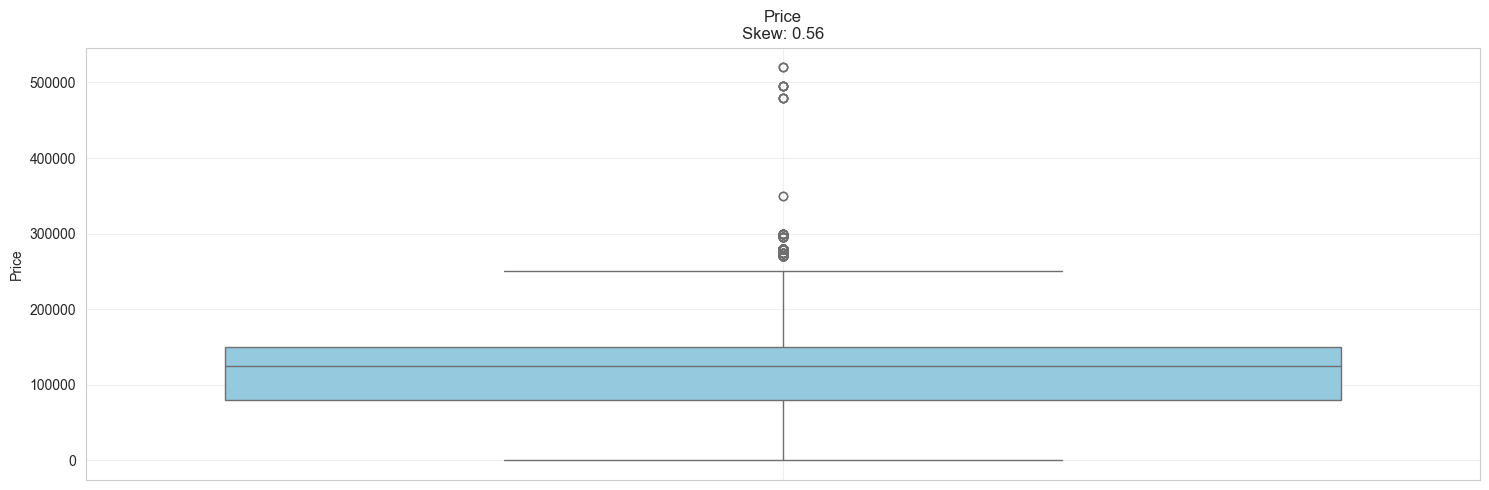

,Fitur,Skewness,Kurtosis,Outlier_IQR (%),Median (P50),P99,Max (P100),Gap Max/P99,Severity,Rekomendasi
0,Price,0.56,1.54,0.5%,"125,000.00","250,000.00","520,000.00",2.08,EXTREME,Praproses Lanjut Dibutuhkan


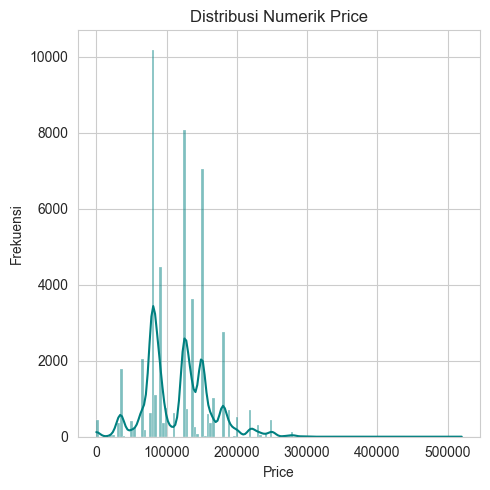

In [17]:
# --- 4. EKSPLORASI TRANSACTION ITEMS ---
# ==============================================================================
# 4. EKSPLORASI DATA DETAIL TRANSAKSI (ITEMS)
# ==============================================================================
print("\n=== 4. EKSPLORASI TRANSACTION ITEMS ===")
df_trx_items = pd.read_csv('data/raw/master_transaction_items.csv')

# -> SENSOR NAMA PELANGGAN
if 'Customer' in df_trx_items.columns:
    df_trx_items['Customer'] = df_trx_items['Customer'].apply(mask_customer_name)

# -> SENSOR KATA "SUNNY" PADA KOLOM CREATED BY (Antisipasi case-sensitive)
col_created = 'Created By' if 'Created By' in df_trx_items.columns else ('Created by' if 'Created by' in df_trx_items.columns else None)
if col_created:
    df_trx_items[col_created] = df_trx_items[col_created].str.replace(r'(?i)sunny_?\s*', '', regex=True).str.strip()

# -> KONVERSI TOTAL PRICE KE FLOAT
if 'Total Price' in df_trx_items.columns:
    df_trx_items['Total Price'] = pd.to_numeric(
        df_trx_items['Total Price'].astype(str).str.replace(r'[^\d.]', '', regex=True), 
        errors='coerce'
    )

exp_trx_items = RawDataExplorer(df_trx_items, "Data Detail Transaksi (Items)")
display(exp_trx_items.get_head(5))
display(exp_trx_items.get_basic_info())

# get_categorical_summary sudah ada print() di dalamnya, jadi tidak perlu display()
exp_trx_items.get_categorical_summary(['Status'])

# -> EKSEKUSI OTOMATIS SEMUA KOLOM NUMERIK
trx_item_num_cols = exp_trx_items.get_numeric_cols()
if trx_item_num_cols:
    display(exp_trx_items.diagnose_outliers(trx_item_num_cols, show_plot=True))
    exp_trx_items.plot_distributions(trx_item_num_cols)

## AHP LRFM dan RFM/P


In [18]:
from babyspa_data.services.ahp_service import AHPService


In [19]:
df_ahp = pd.read_csv("data/raw/AHP_2.csv")


In [20]:

ahp_service = AHPService(batch_name="Analisis Skripsi Baby Spa 2026")

df_hasil_ahp = ahp_service.run()

In [21]:
ahp_preview = ahp_service.print_preview()


=== PREVIEW HASIL AHP: Analisis Skripsi Baby Spa 2026 ===
      Kategori Bobot L  Bobot R  Bobot F  Bobot M   CR  Konsisten  Responden
          LRFM    0.10     0.36     0.39     0.15 0.06       True          2
Produk (RFM/P)       -     0.35     0.46     0.18 0.15       True          2



In [22]:
from babyspa_data.models.ahp_configuration import AHPConfiguration
df_pembobotan_ahp = pd.DataFrame(list(AHPConfiguration.active_objects.all().values()))

In [23]:
df_pembobotan_ahp

,id,created_at,updated_at,deleted_at,name,context,w_length,w_recency,w_frequency,w_monetary
0,c0554d24-8278-4ac2-8780-92e1f2fc0718,2026-04-01 10:46:49.915840+00:00,2026-05-31 10:54:08.978389+00:00,None,Analisis Skripsi Baby Spa 2026 - LRFM,LRFM,0.10,0.36,0.39,0.15
1,b0d76c51-e8b4-4692-8b2d-c50907529e24,2026-04-01 10:46:49.924364+00:00,2026-05-31 10:54:08.985448+00:00,None,Analisis Skripsi Baby Spa 2026 - Product,PRODUCT,0.00,0.35,0.46,0.18


## Pra-pemrosesan Data

### Pra Rekayasa

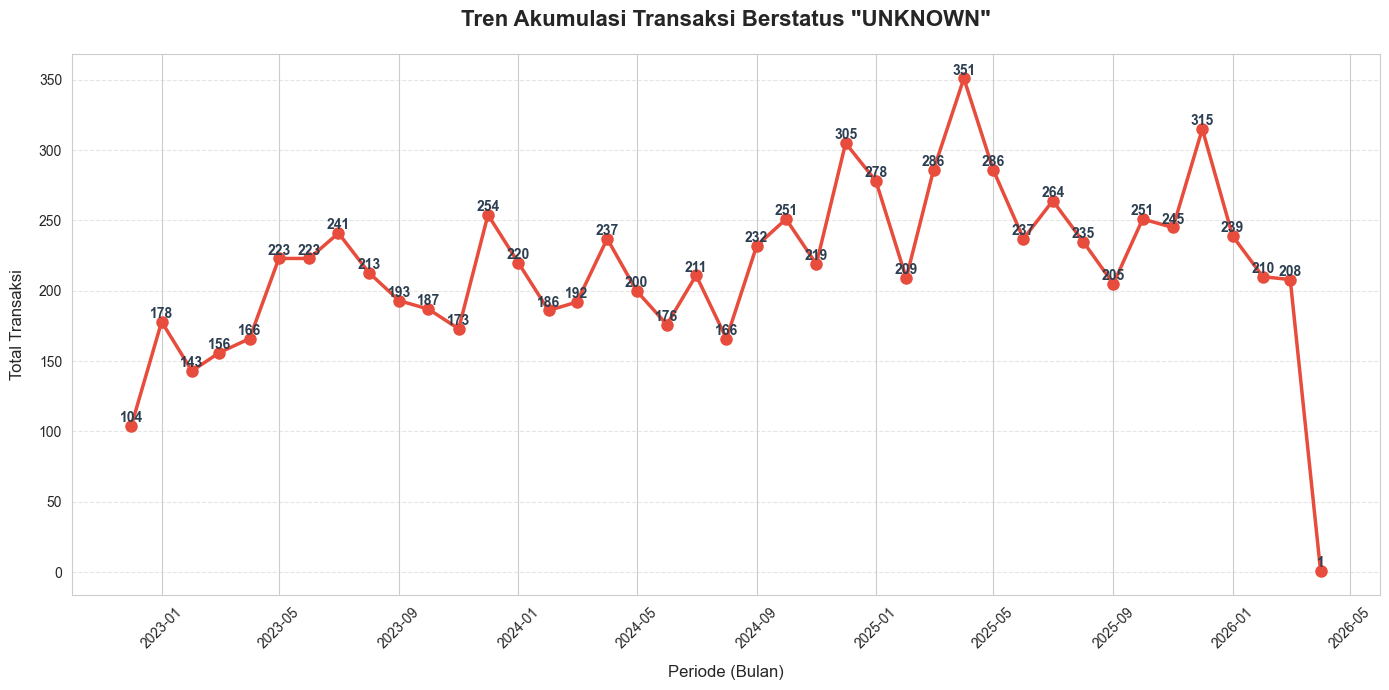

✅ Pemrosesan Selesai.
📊 Total Transaksi UNKNOWN: 8869
📂 Grafik telah disimpan sebagai: tren_transaksi_unknown.png


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from django.db.models.functions import TruncMonth
from django.db.models import Count
from babyspa_data.models.transactions import Transaction

# =================================================================
# 1. PENGAMBILAN DATA (DATA ACQUISITION)
# =================================================================

# Menyaring transaksi dengan status 'UNKNOWN' (case-insensitive)
# Kemudian mengelompokkan data berdasarkan bulan untuk melihat tren
stats_unknown = (
    Transaction.active_objects.filter(status__iexact='UNKNOWN')
    .annotate(month=TruncMonth('scheduled_date'))
    .values('month')
    .annotate(total_count=Count('id'))
    .order_by('month')
)

# Mengonversi hasil query menjadi DataFrame Pandas
df_temporal = pd.DataFrame(list(stats_unknown))

# =================================================================
# 2. VALIDASI DAN PEMBERSIHAN DATA (PREPROCESSING)
# =================================================================

if df_temporal.empty:
    print("⚠️ Tidak ditemukan data transaksi dengan status 'UNKNOWN'.")
else:
    # Memastikan format tanggal benar dan menghapus informasi zona waktu
    # Hal ini dilakukan agar kompatibel dengan library plotting Matplotlib
    df_temporal['month'] = pd.to_datetime(df_temporal['month']).dt.tz_localize(None)
    
    # Menghitung total keseluruhan untuk informasi di log
    total_data = df_temporal['total_count'].sum()

    # =============================================================
    # 3. VISUALISASI DATA (PLOTTING)
    # =============================================================

    # Mengatur ukuran kanvas agar tidak terlalu sempit
    plt.figure(figsize=(14, 7))
    
    # Membuat grafik garis dengan penanda titik
    plt.plot(
        df_temporal['month'], 
        df_temporal['total_count'], 
        marker='o',           # Penanda titik bulat
        markersize=8,         # Ukuran penanda
        linestyle='-',        # Garis lurus
        color='#e74c3c',      # Warna merah terang (Soft Red)
        linewidth=2.5,        # Ketebalan garis
        label='Jumlah Transaksi'
    )

    # --- Kustomisasi Tampilan Grafik ---
    
    plt.title('Tren Akumulasi Transaksi Berstatus "UNKNOWN"', fontsize=16, pad=20, fontweight='bold')
    plt.xlabel('Periode (Bulan)', fontsize=12, labelpad=10)
    plt.ylabel('Total Transaksi', fontsize=12, labelpad=10)
    
    # Menambahkan grid agar nilai lebih mudah dibaca secara horizontal
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    
    # Memutar label tanggal agar tidak saling bertumpukan
    plt.xticks(rotation=45)

    # --- Penambahan Label Nilai pada Titik ---
    
    for x, y in zip(df_temporal['month'], df_temporal['total_count']):
        plt.text(
            x, y + 0.5,       # Posisi teks sedikit di atas titik
            str(y),           # Nilai yang ditampilkan
            ha='center',      # Perataan tengah
            va='bottom',      # Perataan bawah
            fontsize=10, 
            fontweight='bold',
            color='#2c3e50'
        )

    # Menambahkan ruang ekstra di bagian bawah agar label tanggal tidak terpotong
    plt.tight_layout()

    # =============================================================
    # 4. PENYIMPANAN DAN OUTPUT
    # =============================================================

    file_name = 'tren_transaksi_unknown.png'
    plt.savefig(file_name, dpi=300) # Simpan dengan resolusi tinggi
    plt.show()

    print(f"✅ Pemrosesan Selesai.")
    print(f"📊 Total Transaksi UNKNOWN: {total_data}")
    print(f"📂 Grafik telah disimpan sebagai: {file_name}")

### Rekayasa Data

In [25]:

import pandas as pd
from django.db.models import Min, Max, Count, Sum, F, ExpressionWrapper, fields
from django.db.models.functions import Extract, Now
from babyspa_data.models import Transaction, TransactionItem

# 1. Mengambil Tanggal Transaksi Terakhir sebagai Referensi (pengganti timezone.now)
latest_transaction_date = Transaction.active_objects.latest('scheduled_date').scheduled_date
print(f"Tanggal referensi yang digunakan (transaksi terbaru): {latest_transaction_date}")


Tanggal referensi yang digunakan (transaksi terbaru): 2026-04-05 00:00:00+00:00


In [26]:
from django.db.models import Min, Max, Count, Sum, F, Q, OuterRef, Subquery
import pandas as pd
from babyspa_data.models import Transaction, TransactionItem, Customer

# ==============================================================================
# 1. CARI ID TRANSAKSI UNKNOWN YANG SELURUH ITEMNYA CANCELED (DATA CLEANSING)
# ==============================================================================
# PERBAIKAN: Jangan filter items di awal kueri utama agar tidak memicu INNER JOIN parsial
bad_transaction_ids = Transaction.active_objects.filter(
    status__in=['UNKNOWN', 'unknown']
).annotate(
    total_items=Count('items__id', distinct=True),
    canceled_items=Count('items__id', filter=Q(items__status__in=['CANCELED', 'canceled']), distinct=True)
).filter(
    total_items=F('canceled_items'),
    total_items__gt=0 # Pastikan transaksi memang memiliki item
).values_list('id', flat=True)


# ==============================================================================
# 2. KUERI UTAMA DF_LRFM (TETAP PAKAI TRANSACTION AGAR STRUKTUR TIDAK BERUBAH)
# ==============================================================================
customer_query = Transaction.active_objects.filter(
    status__in=['PAID', 'UNKNOWN', 'paid', 'unknown']
).exclude(
    id__in=bad_transaction_ids 
).values('customer_id').annotate(
    first_visit=Min('scheduled_date'),
    last_visit=Max('scheduled_date'),
    frequency=Count('id'),
    monetary=Sum('total_price'), 
    # PERBAIKAN UTAMA: Ambil DOB menggunakan Subquery untuk menjamin skema LEFT JOIN (Row tidak akan hilang)
    dob=Subquery(
        Customer.active_objects.filter(id=OuterRef('customer_id')).values('date_of_birth')[:1]
    )
)

# 2. Ambil tanggal transaksi terbaru
latest_transaction_date = Transaction.active_objects.aggregate(max_date=Max('scheduled_date'))['max_date']
latest_data_fetch = Transaction.active_objects.aggregate(max_date=Max('created_at'))['max_date'] 


# ==============================================================================
# 3. PROSES DATAFRAME (PANDAS)
# ==============================================================================
df_lrfm = pd.DataFrame(list(customer_query))

if not df_lrfm.empty:
    # Sinkronisasi zona waktu ke naive
    def to_naive(series):
        return pd.to_datetime(series).dt.tz_localize(None)

    df_lrfm['last_visit'] = to_naive(df_lrfm['last_visit'])
    df_lrfm['first_visit'] = to_naive(df_lrfm['first_visit'])
    df_lrfm['dob'] = to_naive(df_lrfm['dob'])
    
    ref_date = pd.to_datetime(latest_transaction_date).tz_localize(None) if latest_transaction_date else pd.Timestamp.now()
    ref_fetch_date = pd.to_datetime(latest_data_fetch).tz_localize(None) if latest_data_fetch else pd.Timestamp.now()
        
    # Imputasi nilai DOB yang kosong menggunakan modus
    if df_lrfm['dob'].notna().any():
        mode_year = df_lrfm['dob'].dt.year.mode()[0]
        mode_month = df_lrfm['dob'].dt.month.mode()[0]
        default_dob = pd.to_datetime(f"{int(mode_year)}-{int(mode_month):02d}-01")
    else:
        default_dob = pd.to_datetime("2000-01-01")
        
    df_lrfm['dob'] = df_lrfm['dob'].fillna(default_dob)
    
    # Kalkulasi Metrik LRFM + Age
    df_lrfm['length'] = (df_lrfm['last_visit'] - df_lrfm['first_visit']).dt.days
    df_lrfm['recency'] = (ref_date - df_lrfm['last_visit']).dt.days
    df_lrfm['age'] = (ref_fetch_date - df_lrfm['dob']).dt.days / 30.436875
    
    # Winsorization / Clip nilai ekstrem usia (0 hingga 99 tahun dalam satuan bulan)
    df_lrfm['age'] = df_lrfm['age'].clip(lower=0, upper=1188)
    
    # Memilih kolom akhir
    df_lrfm = df_lrfm[['customer_id', 'length', 'recency', 'frequency', 'monetary', 'age']]

In [27]:
df_lrfm

,customer_id,length,recency,frequency,monetary,age
0,0000ef16-d8e8-4caa-b346-68bb8428e1bf,114,970,4,"600,000.00",95.71
1,0001d86d-15a7-430d-b5cc-a8a51fa36ce5,0,923,1,"100,000.00",369.09
2,00049e67-800f-441d-85ac-d986466ea66b,0,135,1,"210,000.00",5.26
3,000928fd-08a3-4685-a46c-3d8c5547dda0,0,685,1,"135,000.00",437.27
4,000cc1fd-6560-40da-9e95-e00ba9854bd1,219,143,3,"560,000.00",64.40
...,...,...,...,...,...,...
18190,ffe446db-dddb-4b8e-a8f7-e13790242d4a,0,435,1,"230,000.00",17.84
18191,ffeee5c6-a2ef-46be-a3d4-3e19b4b571d8,0,219,1,"135,000.00",16.13
18192,fff0d746-863c-4613-80e6-cd70094c37c8,0,91,1,"135,000.00",6.80
18193,fff31e39-6016-4a39-82fb-7104e7266a4f,0,1065,1,"125,000.00",45.87


In [28]:
# ==========================================
# PEMBENTUKAN df_rfm_p (Product Analysis)
# ==========================================

product_query = TransactionItem.active_objects.values(
    'product_id', 
    'product__item_name',
    'product__erp_item_id'
).annotate(
    last_sold=Max('transaction__scheduled_date'),
    frequency=Count('id'),
    monetary=Sum(F('quantity') * F('sale_price'))
)

df_rfm_p = pd.DataFrame(list(product_query))

if not df_rfm_p.empty:
    # R (Recency): Jarak hari sejak produk terakhir terjual
    df_rfm_p['recency'] = (latest_transaction_date - df_rfm_p['last_sold']).dt.days
    
    # Konversi monetary ke integer (jika tidak butuh sen) atau float biasa
    # Ini menghilangkan format e+07 saat inspeksi dataframe
    df_rfm_p['monetary'] = df_rfm_p['monetary'].astype(float)
    
    df_rfm_p = df_rfm_p.rename(columns={'product__item_name': 'item_name', 'product__erp_item_id': 'erp_item_id'})
    df_rfm_p = df_rfm_p[['product_id', 'item_name', 'erp_item_id', 'recency', 'frequency', 'monetary']]


In [29]:

# Pastikan tidak ada NaN, lalu ubah ke integer
df_rfm_p['monetary'] = df_rfm_p['monetary'].fillna(0).astype('float32')

# Tampilkan
df_rfm_p.head()


,product_id,item_name,erp_item_id,recency,frequency,monetary
0,02cc25da-42a2-4962-8bd5-294f16d29d9d,SIBLING BABY SPA GRESIK,None,56,54,"8,620,000.00"
1,031240f6-2de3-4b88-ad7e-2a2365a4b584,SIBLING KID SPA GRESIK,None,8,200,"32,960,000.00"
2,08a70e94-eb92-41b0-9442-baf74edb62ff,STIMULASI TUMBUH KEMBANG 1 X PERTEMUAN,None,21,78,"10,380,000.00"
3,1071f8c8-9fbd-4d1f-bb42-599ceb9770a1,HOMECARE GROOMING,None,319,1,"165,000.00"
4,10c2b5d2-01e6-40f8-895b-22fbcf8685ba,SUNNY BRIGHT KIDS,None,17,2926,"532,206,816.00"


In [30]:

df_rfm_p.info()

<class 'pandas.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   product_id   98 non-null     object 
 1   item_name    98 non-null     str    
 2   erp_item_id  0 non-null      object 
 3   recency      98 non-null     int64  
 4   frequency    98 non-null     int64  
 5   monetary     98 non-null     float32
dtypes: float32(1), int64(2), object(2), str(1)
memory usage: 4.3+ KB


In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def diagnosa_outlier(df, cols):
    # Filter kolom yang benar-benar ada di dataframe untuk menghindari KeyError
    cols = [c for c in cols if c in df.columns]
    if not cols:
        print("Error: Tidak ada kolom yang cocok ditemukan di DataFrame.")
        return pd.DataFrame()

    report_data = []

    for col in cols:
        series = df[col]
        n = len(series)

        # 1. Statistik Dasar
        skew = series.skew()
        kurt = series.kurtosis()

        # 2. Cek Percentile Kunci
        p50 = series.median()
        p99 = series.quantile(0.99)
        p100 = series.max()

        # 3. Hitung Outlier via IQR Rule
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1
        upper_fence = Q3 + (1.5 * IQR)
        outlier_count_iqr = series[series > upper_fence].count()
        outlier_pct_iqr = (outlier_count_iqr / n) * 100

        # 4. Analisis Gap Ekstrem (P99 vs Max)
        gap_ratio = p100 / p99 if p99 != 0 else 0

        # 5. Logika Rekomendasi berdasarkan tingkat keparahan skewness[cite: 1]
        if  skew > 3:
            severity = "EXTREME"
            rec = "Wajib Transformasi "
        elif skew > 1:
            severity = "HIGH"
            rec = "Saran Transformasi "
        else:
            severity = "LOW"
            rec = "Aman / Optional"

        report_data.append({
            'Fitur': col,
            'Skewness': round(skew, 2),
            'Kurtosis': round(kurt, 2),
            'Outlier_IQR (%)': f"{round(outlier_pct_iqr, 1)}%",
            'Median (P50)': round(p50, 2),
            'P99 (Batas 99%)': round(p99, 2),
            'Max (P100)': round(p100, 2),
            'Gap Max/P99': round(gap_ratio, 2) if p99!=0 else "Inf",
            'Severity': severity,
            'Rekomendasi': rec
        })

    # Visualisasi Boxplot secara otomatis[cite: 1]
    plt.figure(figsize=(18, 5))
    for i, col in enumerate(cols):
        plt.subplot(1, len(cols), i+1)
        sns.boxplot(y=df[col], color='skyblue')
        plt.title(f'{col}\nSkew: {df[col].skew():.2f}')
        plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return pd.DataFrame(report_data)

=== HASIL DIAGNOSA SKEWNESS & OUTLIER: df_lrfm ===


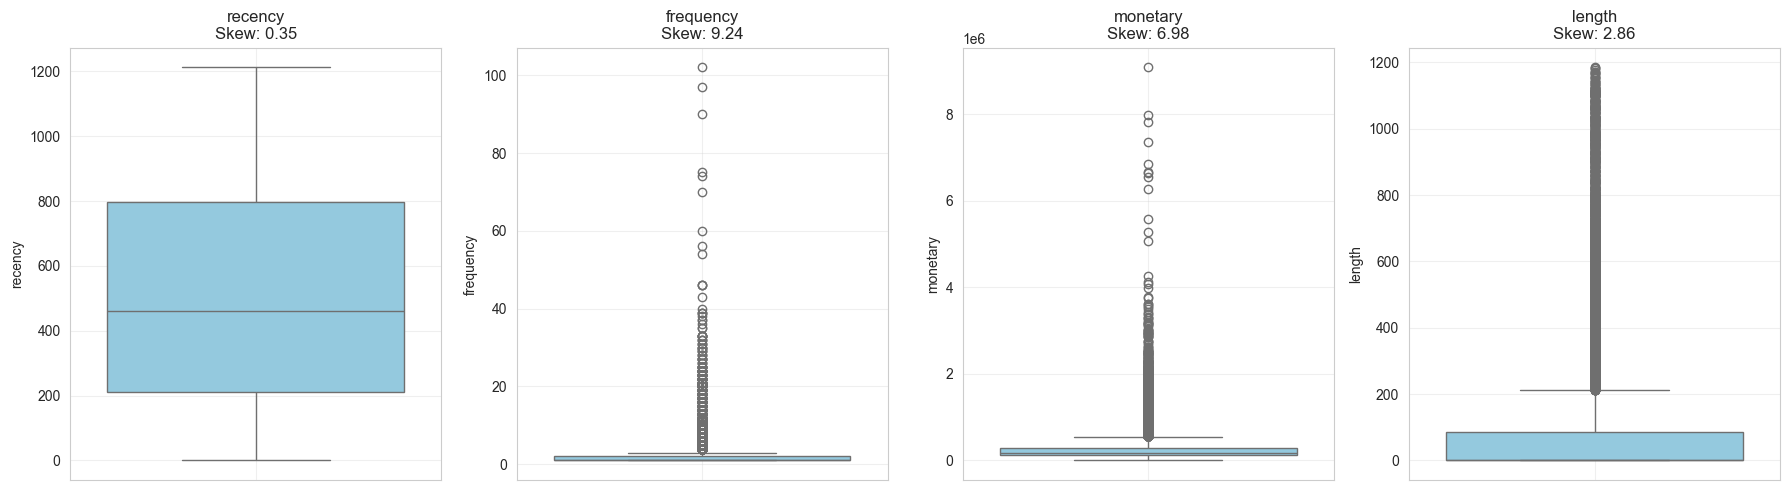

,Fitur,Skewness,Kurtosis,Outlier_IQR (%),Median (P50),P99 (Batas 99%),Max (P100),Gap Max/P99,Severity,Rekomendasi
0,recency,0.35,-1.07,0.0%,460.00,"1,191.00","1,212.00",1.02,LOW,Aman / Optional
1,frequency,9.24,160.78,13.4%,1.00,17.00,102.00,6.00,EXTREME,Wajib Transformasi
2,monetary,6.98,90.73,10.0%,"165,000.00","1,820,300.00","9,085,000.00",4.99,EXTREME,Wajib Transformasi
3,length,2.86,8.77,15.4%,0.00,968.06,"1,185.00",1.22,HIGH,Saran Transformasi


In [32]:
# Target fitur LRFM[cite: 1]
target_lrfm = ['recency', 'frequency', 'monetary', 'length']

print("=== HASIL DIAGNOSA SKEWNESS & OUTLIER: df_lrfm ===")
report_lrfm = diagnosa_outlier(df_lrfm, target_lrfm)
display(report_lrfm)


=== HASIL DIAGNOSA SKEWNESS & OUTLIER: df_rfm_p ===


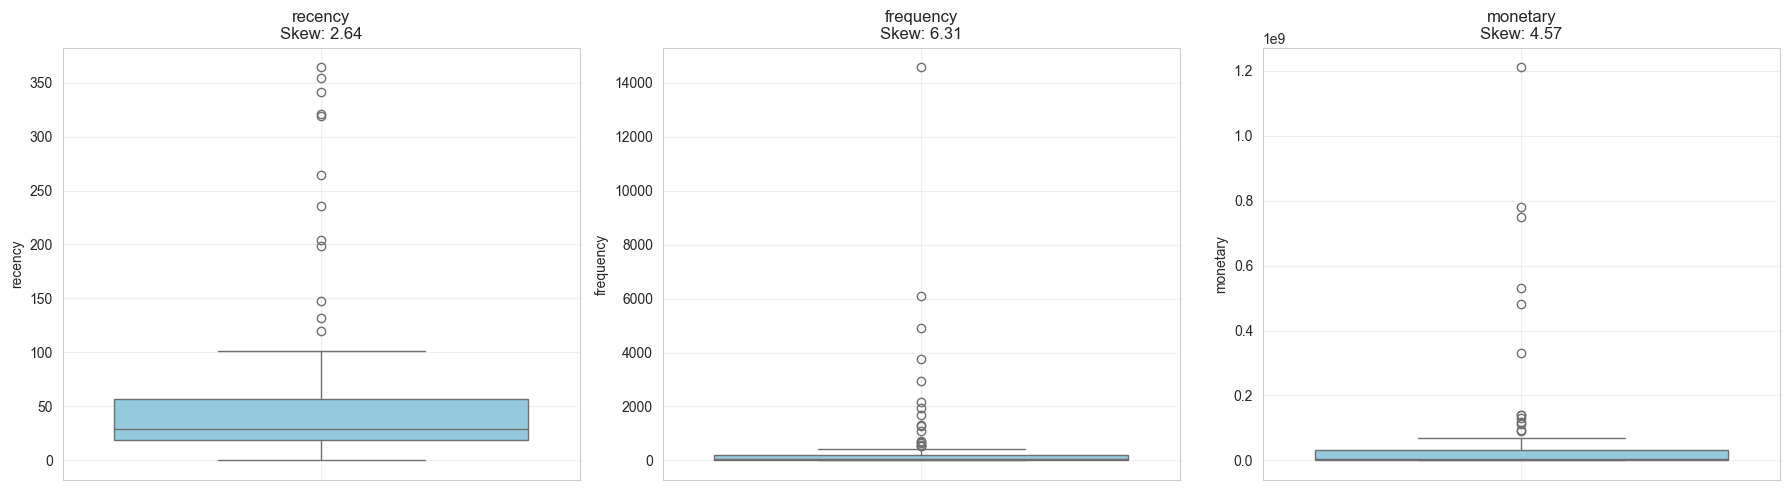

,Fitur,Skewness,Kurtosis,Outlier_IQR (%),Median (P50),P99 (Batas 99%),Max (P100),Gap Max/P99,Severity,Rekomendasi
0,recency,2.64,6.34,12.2%,29.00,354.30,364.00,1.03,HIGH,Saran Transformasi
1,frequency,6.31,46.93,17.3%,34.50,"6,332.82","14,572.00",2.30,EXTREME,Wajib Transformasi
2,monetary,4.57,22.88,13.3%,"4,127,500.25","792,754,400.00","1,210,320,000.00",1.53,EXTREME,Wajib Transformasi


In [33]:
#target fitur RFM-P
target_rfm_p = ['recency', 'frequency', 'monetary']
print("\n=== HASIL DIAGNOSA SKEWNESS & OUTLIER: df_rfm_p ===")
report_rfm_p = diagnosa_outlier(df_rfm_p, target_rfm_p)
display(report_rfm_p)

### Transformasi Yeo-Johnson

In [34]:
from babyspa_data.services.preprocess import Preprocess

preprocess = Preprocess()

In [35]:
df_yeo_lrfm = preprocess.transform_yeo_johnson(df_lrfm, columns=['frequency', 'monetary','length'])

In [36]:
df_yeo_lrfm.head()

,customer_id,length,recency,frequency,monetary,age
0,0000ef16-d8e8-4caa-b346-68bb8428e1bf,2.15,970,0.40,25.07,95.71
1,0001d86d-15a7-430d-b5cc-a8a51fa36ce5,-0.00,923,0.33,19.79,369.09
2,00049e67-800f-441d-85ac-d986466ea66b,-0.00,135,0.33,21.88,5.26
3,000928fd-08a3-4685-a46c-3d8c5547dda0,-0.00,685,0.33,20.62,437.27
4,000cc1fd-6560-40da-9e95-e00ba9854bd1,2.24,143,0.39,24.85,64.40


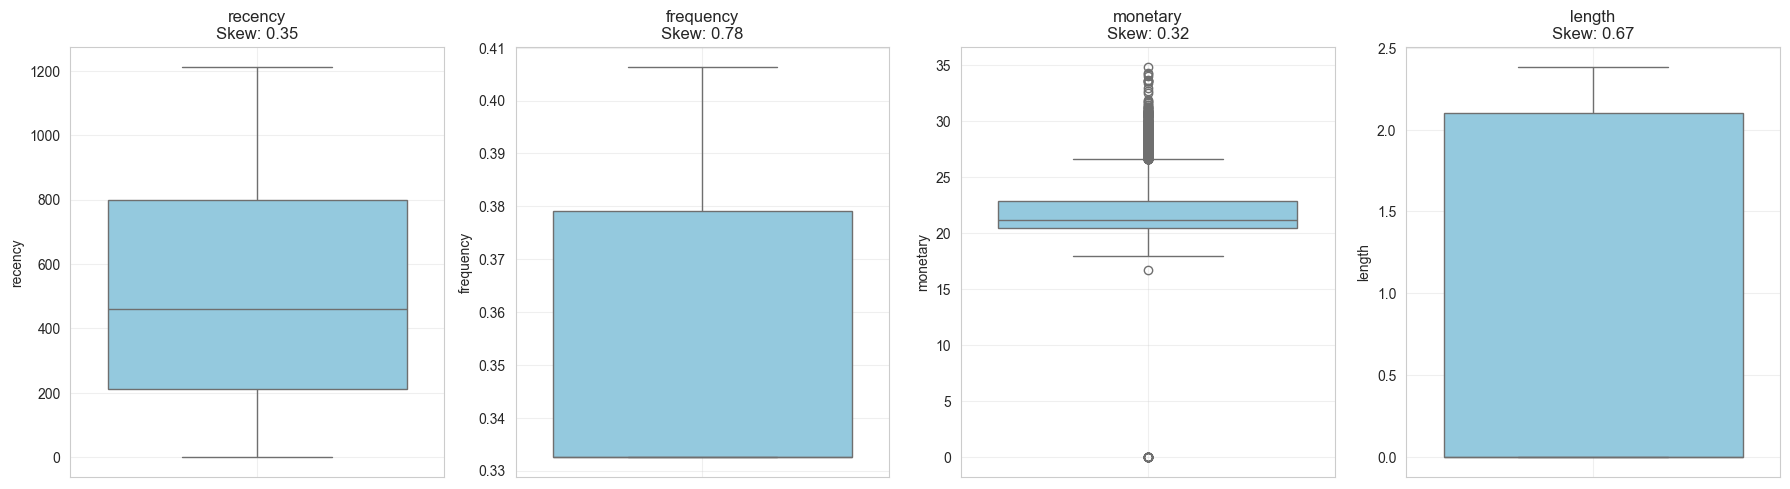

,Fitur,Skewness,Kurtosis,Outlier_IQR (%),Median (P50),P99 (Batas 99%),Max (P100),Gap Max/P99,Severity,Rekomendasi
0,recency,0.35,-1.07,0.0%,460.00,"1,191.00","1,212.00",1.02,LOW,Aman / Optional
1,frequency,0.78,-1.20,0.0%,0.33,0.41,0.41,1.00,LOW,Aman / Optional
2,monetary,0.32,9.98,4.1%,21.19,28.77,34.82,1.21,LOW,Aman / Optional
3,length,0.67,-1.51,0.0%,0.00,2.37,2.38,1.01,LOW,Aman / Optional


In [37]:
report_yeo_lrfm = diagnosa_outlier(df_yeo_lrfm, target_lrfm) 
display(report_yeo_lrfm)

In [38]:
df_scale_lrfm = preprocess.transform_z_scale(df_yeo_lrfm, columns=['recency', 'frequency', 'monetary', 'length'])

In [39]:
df_scale_lrfm.head()

,customer_id,length,recency,frequency,monetary,age
0,0000ef16-d8e8-4caa-b346-68bb8428e1bf,1.35,1.32,1.61,1.45,95.71
1,0001d86d-15a7-430d-b5cc-a8a51fa36ce5,-0.73,1.19,-0.72,-0.92,369.09
2,00049e67-800f-441d-85ac-d986466ea66b,-0.73,-1.10,-0.72,0.02,5.26
3,000928fd-08a3-4685-a46c-3d8c5547dda0,-0.73,0.50,-0.72,-0.55,437.27
4,000cc1fd-6560-40da-9e95-e00ba9854bd1,1.44,-1.08,1.41,1.35,64.40


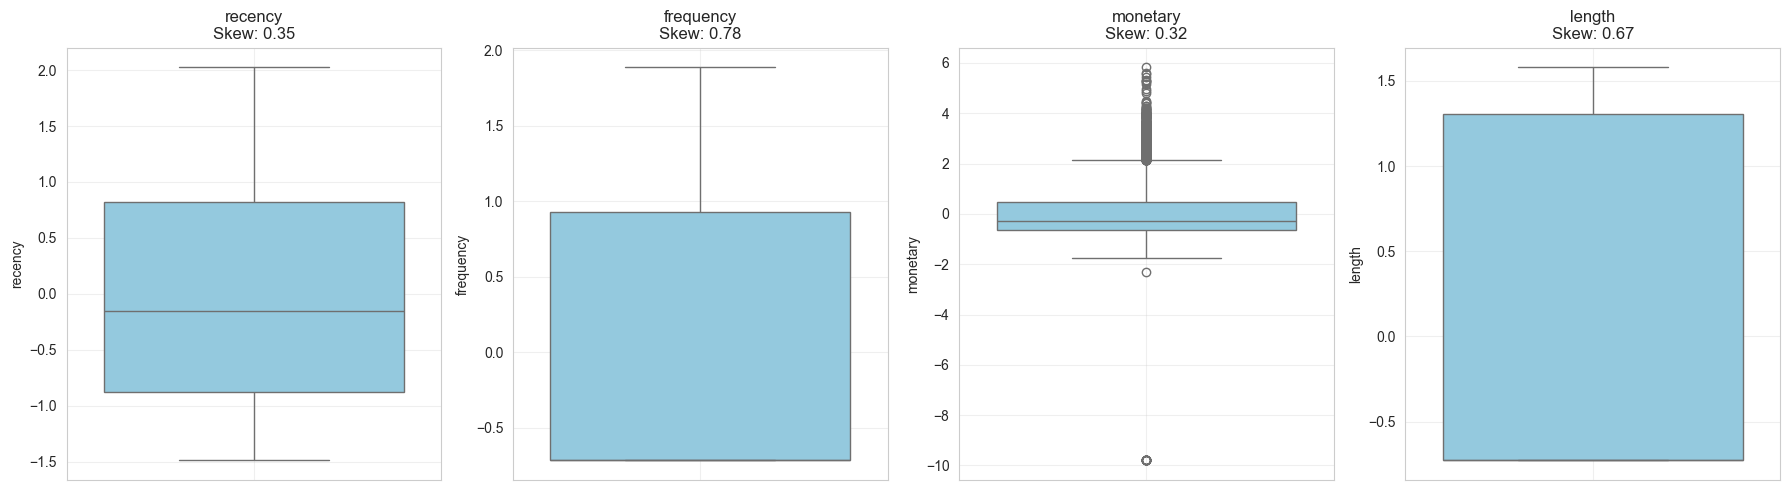

,Fitur,Skewness,Kurtosis,Outlier_IQR (%),Median (P50),P99 (Batas 99%),Max (P100),Gap Max/P99,Severity,Rekomendasi
0,recency,0.35,-1.07,0.0%,-0.16,1.96,2.02,1.03,LOW,Aman / Optional
1,frequency,0.78,-1.20,0.0%,-0.72,1.87,1.89,1.01,LOW,Aman / Optional
2,monetary,0.32,9.98,4.1%,-0.29,3.11,5.82,1.87,LOW,Aman / Optional
3,length,0.67,-1.51,0.0%,-0.73,1.57,1.58,1.01,LOW,Aman / Optional


In [40]:
report_scale_lrfm = diagnosa_outlier(df_scale_lrfm, target_lrfm)
display(report_scale_lrfm)

## Pengelolaan Data Untuk K-Means

### AHP CLV untuk LRFM

In [41]:
# 1. Import kebutuhan
import pandas as pd
from babyspa_data.models.ahp_configuration import AHPConfiguration
from babyspa_data.services.clv_builder import CLVBuilder


In [42]:

# 2. Ambil data AHP dari database (Sesuai kode mentah Anda)
ahp_dict_lrfm = AHPConfiguration.active_objects.filter(context='LRFM').values().first()
ahp_dict_rfm_p = AHPConfiguration.active_objects.filter(context='PRODUCT').values().first()

ahp_lrfm = pd.DataFrame([ahp_dict_lrfm]) if ahp_dict_lrfm else pd.DataFrame()
ahp_rfm_p = pd.DataFrame([ahp_dict_rfm_p]) if ahp_dict_rfm_p else pd.DataFrame()


In [43]:

# 3. Ekstrak bobot menjadi dictionary agar mudah dikelola oleh CLVBuilder
if not ahp_lrfm.empty:
    bobot_lrfm = {
        'w_length': ahp_lrfm['w_length'].iloc[0],
        'w_recency': ahp_lrfm['w_recency'].iloc[0],
        'w_frequency': ahp_lrfm['w_frequency'].iloc[0],
        'w_monetary': ahp_lrfm['w_monetary'].iloc[0]
    }
else:
    raise ValueError("Data AHP LRFM kosong di database!")


In [44]:

# 4. Asumsikan df_scale_lrfm sudah ada dari tahap Z-score/Yeo-Johnson
# df_scale_lrfm = ... 

# 5. Eksekusi menggunakan CLVBuilder
clv_builder = CLVBuilder(ahp_weights=bobot_lrfm)
df_lrfm_final = clv_builder.calculate_clv(df_scale_lrfm)


In [45]:

# Lihat hasil akhir
df_lrfm_final['real_recency'] = df_lrfm['recency']
df_lrfm_final['real_monetary'] = df_lrfm['monetary']
df_lrfm_final['real_frequency'] = df_lrfm['frequency']
df_lrfm_final['real_length'] = df_lrfm['length']
df_lrfm_final.head()

,customer_id,length,recency,frequency,monetary,age,CLV,real_recency,real_monetary,real_frequency,real_length
0,0000ef16-d8e8-4caa-b346-68bb8428e1bf,1.35,1.32,1.61,1.45,95.71,0.84,970,"600,000.00",4,114
1,0001d86d-15a7-430d-b5cc-a8a51fa36ce5,-0.73,1.19,-0.72,-0.92,369.09,0.36,923,"100,000.00",1,0
2,00049e67-800f-441d-85ac-d986466ea66b,-0.73,-1.10,-0.72,0.02,5.26,0.14,135,"210,000.00",1,0
3,000928fd-08a3-4685-a46c-3d8c5547dda0,-0.73,0.50,-0.72,-0.55,437.27,0.29,685,"135,000.00",1,0
4,000cc1fd-6560-40da-9e95-e00ba9854bd1,1.44,-1.08,1.41,1.35,64.40,0.56,143,"560,000.00",3,219


In [46]:
df_lrfm_final

,customer_id,length,recency,frequency,monetary,age,CLV,real_recency,real_monetary,real_frequency,real_length
0,0000ef16-d8e8-4caa-b346-68bb8428e1bf,1.35,1.32,1.61,1.45,95.71,0.84,970,"600,000.00",4,114
1,0001d86d-15a7-430d-b5cc-a8a51fa36ce5,-0.73,1.19,-0.72,-0.92,369.09,0.36,923,"100,000.00",1,0
2,00049e67-800f-441d-85ac-d986466ea66b,-0.73,-1.10,-0.72,0.02,5.26,0.14,135,"210,000.00",1,0
3,000928fd-08a3-4685-a46c-3d8c5547dda0,-0.73,0.50,-0.72,-0.55,437.27,0.29,685,"135,000.00",1,0
4,000cc1fd-6560-40da-9e95-e00ba9854bd1,1.44,-1.08,1.41,1.35,64.40,0.56,143,"560,000.00",3,219
...,...,...,...,...,...,...,...,...,...,...,...
18190,ffe446db-dddb-4b8e-a8f7-e13790242d4a,-0.73,-0.23,-0.72,0.14,17.84,0.23,435,"230,000.00",1,0
18191,ffeee5c6-a2ef-46be-a3d4-3e19b4b571d8,-0.73,-0.85,-0.72,-0.55,16.13,0.16,219,"135,000.00",1,0
18192,fff0d746-863c-4613-80e6-cd70094c37c8,-0.73,-1.23,-0.72,-0.55,6.80,0.12,91,"135,000.00",1,0
18193,fff31e39-6016-4a39-82fb-7104e7266a4f,-0.73,1.60,-0.72,-0.64,45.87,0.40,1065,"125,000.00",1,0


### Penentuan K Optimal

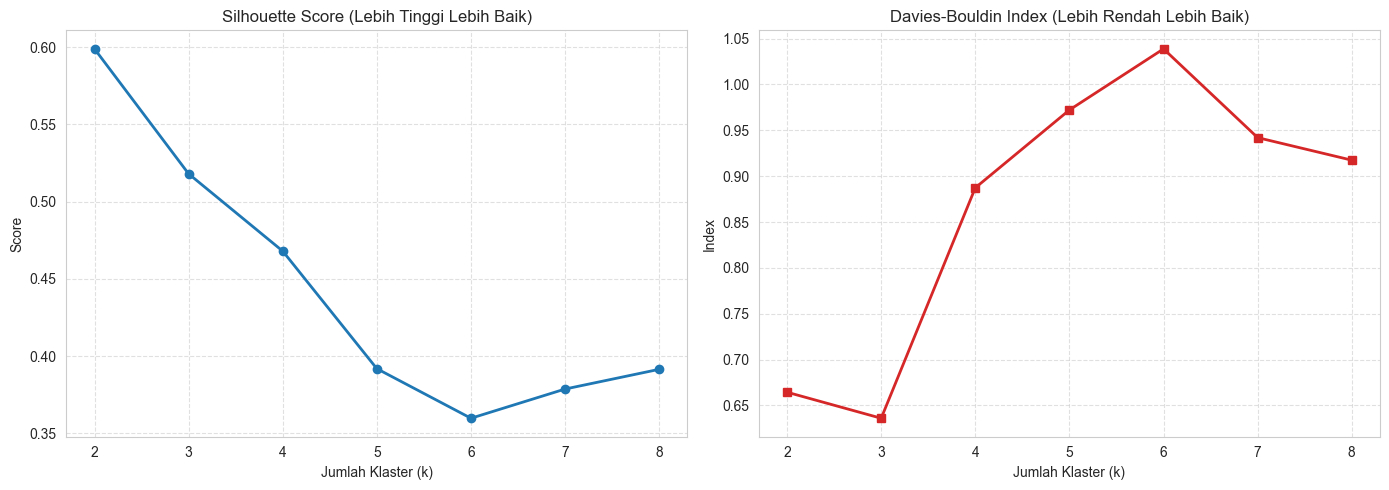

,k,silhouette,davies_bouldin
0,2,0.60,0.66
1,3,0.52,0.64
2,4,0.47,0.89
3,5,0.39,0.97
4,6,0.36,1.04
5,7,0.38,0.94
6,8,0.39,0.92


In [47]:
from babyspa_data.services.clustering import Clustering

# 1. Tentukan kolom spesifik untuk K-Means (Gunakan yang Z-score)
kolom_kmeans = ['length', 'recency', 'frequency', 'monetary']

# 2. Inisialisasi Service
clustering_service = Clustering(df=df_lrfm_final, clustering_columns=kolom_kmeans)

# 3. Tampilkan grafik Silhouette dan Davies-Bouldin
df_eval = clustering_service.evaluate_optimal_k(min_k=2, max_k=8)
display(df_eval)

## Clustering dan Visualisasinya

In [48]:
from sklearn.cluster import KMeans


In [49]:

# 1. Definisikan kolom fitur yang sudah distandarisasi (Z-score)
fitur_lrfm = ['length', 'recency', 'frequency', 'monetary']

# 2. Inisialisasi model K-Means dengan inisialisasi K-Means++
# n_init='auto' disarankan untuk versi Scikit-Learn terbaru agar lebih efisien
kmeans_k2 = KMeans(n_clusters=2, init='k-means++', random_state=42, n_init='auto')
kmeans_k3 = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init='auto')

# 3. Fit dan Prediksi langsung, simpan hasilnya ke kolom baru
df_lrfm_final['cluster_k_2'] = kmeans_k2.fit_predict(df_lrfm_final[fitur_lrfm])
df_lrfm_final['cluster_k_3'] = kmeans_k3.fit_predict(df_lrfm_final[fitur_lrfm])


In [50]:

# Tampilkan beberapa baris pertama untuk memastikan hasil
display(df_lrfm_final[['customer_id', 'cluster_k_2','cluster_k_3']].head())

,customer_id,cluster_k_2,cluster_k_3
0,0000ef16-d8e8-4caa-b346-68bb8428e1bf,1,1
1,0001d86d-15a7-430d-b5cc-a8a51fa36ce5,0,2
2,00049e67-800f-441d-85ac-d986466ea66b,0,0
3,000928fd-08a3-4685-a46c-3d8c5547dda0,0,2
4,000cc1fd-6560-40da-9e95-e00ba9854bd1,1,1


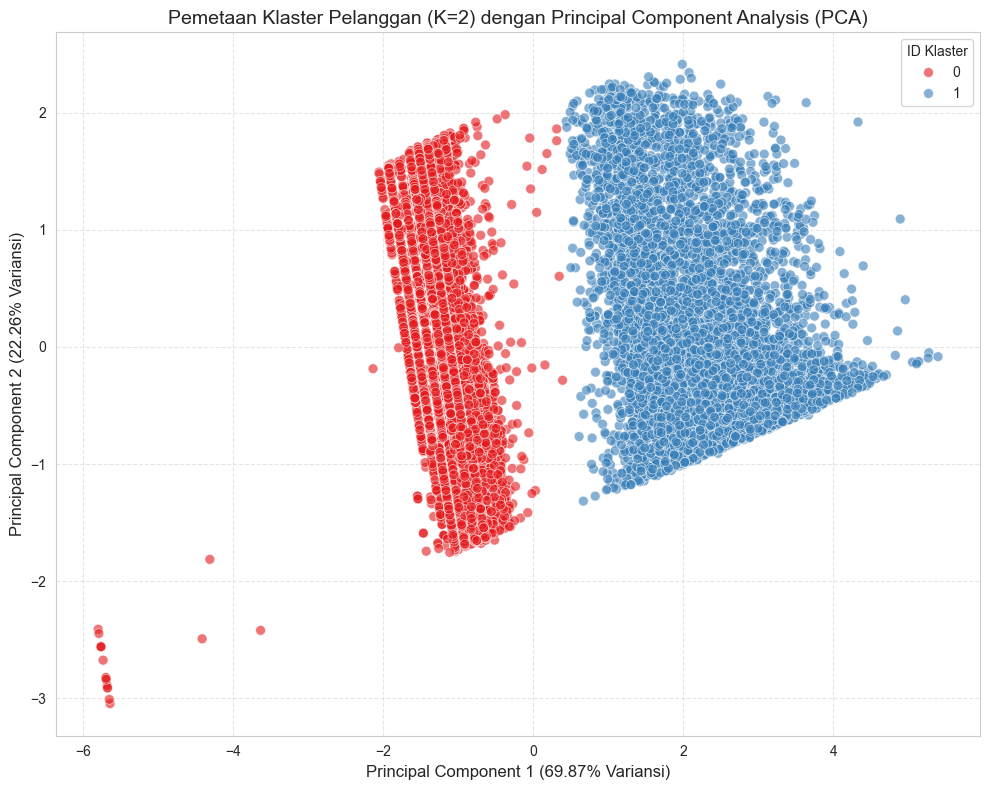

In [51]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Inisialisasi PCA untuk mereduksi 4 dimensi (LRFM) menjadi 2 dimensi
pca = PCA(n_components=2)

# 2. Fit dan transform hanya pada fitur LRFM yang sudah distandarisasi (Z-score)
fitur_lrfm = ['length', 'recency', 'frequency', 'monetary']
pca_result = pca.fit_transform(df_lrfm_final[fitur_lrfm])

# 3. Masukkan hasil PCA (titik koordinat 2D) ke dalam dataframe
df_lrfm_final['PC1'] = pca_result[:, 0]
df_lrfm_final['PC2'] = pca_result[:, 1]

# 4. Hitung seberapa besar informasi (variansi) yang berhasil dipertahankan oleh PCA
var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100

# 5. Visualisasi Scatter Plot 2D
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', 
    y='PC2',
    hue='cluster_k_2', 
    palette='Set1',
    data=df_lrfm_final,
    alpha=0.6,         
    s=50               
)

# Menambahkan judul dan label sumbu beserta persentase variansinya
plt.title('Pemetaan Klaster Pelanggan (K=2) dengan Principal Component Analysis (PCA)', fontsize=14)
plt.xlabel(f'Principal Component 1 ({var_pc1:.2f}% Variansi)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({var_pc2:.2f}% Variansi)', fontsize=12)

# Menambahkan grid dan memperbaiki tampilan legenda
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='ID Klaster', loc='best')
plt.tight_layout()
plt.show()

In [52]:
# Tampilkan beberapa baris pertama untuk memastikan hasil
display(df_lrfm_final[['customer_id', 'cluster_k_3']].head())

,customer_id,cluster_k_3
0,0000ef16-d8e8-4caa-b346-68bb8428e1bf,1
1,0001d86d-15a7-430d-b5cc-a8a51fa36ce5,2
2,00049e67-800f-441d-85ac-d986466ea66b,0
3,000928fd-08a3-4685-a46c-3d8c5547dda0,2
4,000cc1fd-6560-40da-9e95-e00ba9854bd1,1


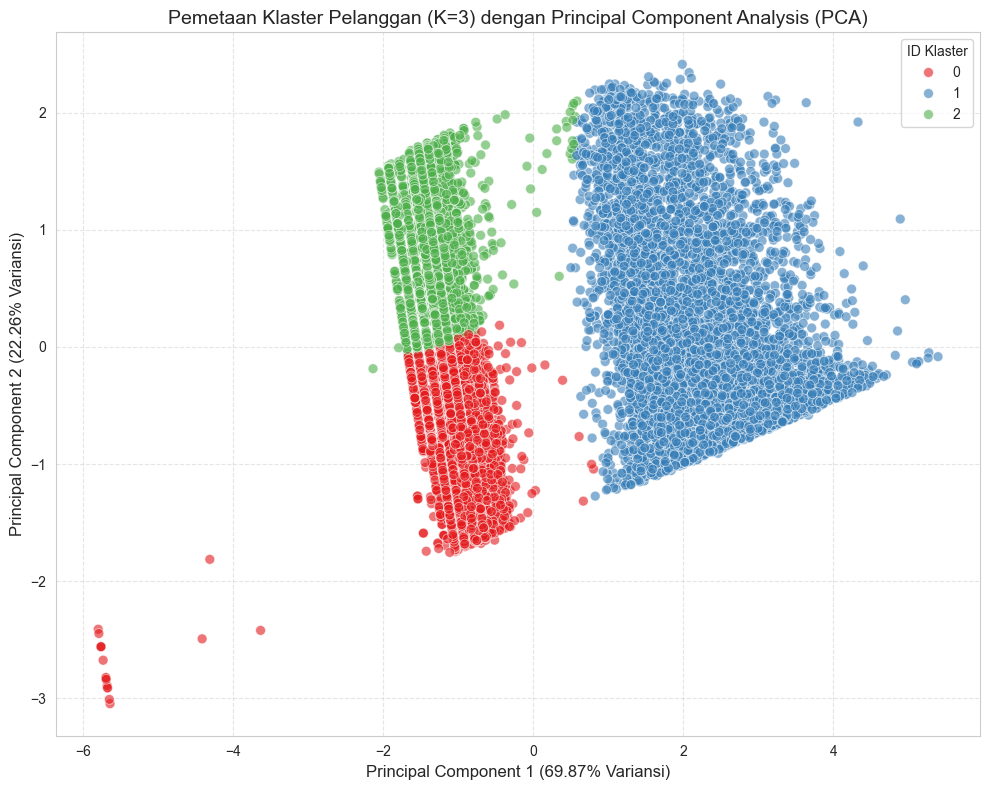

In [53]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Inisialisasi PCA untuk mereduksi 4 dimensi (LRFM) menjadi 2 dimensi
pca = PCA(n_components=2)

# 2. Fit dan transform hanya pada fitur LRFM yang sudah distandarisasi (Z-score)
fitur_lrfm = ['length', 'recency', 'frequency', 'monetary']
pca_result = pca.fit_transform(df_lrfm_final[fitur_lrfm])

# 3. Masukkan hasil PCA (titik koordinat 2D) ke dalam dataframe
df_lrfm_final['PC1'] = pca_result[:, 0]
df_lrfm_final['PC2'] = pca_result[:, 1]

# 4. Hitung seberapa besar informasi (variansi) yang berhasil dipertahankan oleh PCA
var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100

# 5. Visualisasi Scatter Plot 2D
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', 
    y='PC2',
    hue='cluster_k_3', 
    palette='Set1',
    data=df_lrfm_final,
    alpha=0.6,         
    s=50               
)

# Menambahkan judul dan label sumbu beserta persentase variansinya
plt.title('Pemetaan Klaster Pelanggan (K=3) dengan Principal Component Analysis (PCA)', fontsize=14)
plt.xlabel(f'Principal Component 1 ({var_pc1:.2f}% Variansi)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({var_pc2:.2f}% Variansi)', fontsize=12)

# Menambahkan grid dan memperbaiki tampilan legenda
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='ID Klaster', loc='best')
plt.tight_layout()
plt.show()

## PErhitungan CLV untuk K Optimal

In [54]:
#universal dataset untuk perbandingnan average

universal_avg = df_lrfm_final[['real_length', 'real_recency', 'real_frequency', 'real_monetary', 'CLV']].mean().to_frame().T

In [55]:
universal_avg

,real_length,real_recency,real_frequency,real_monetary,CLV
0,91.24,513.87,2.20,"283,584.45",0.39


### Perhitungan CLV K=3

In [56]:
# perhitungan centroid length, recency, frequency, monetary, CLV, real_length, real_recency, real_frequency, dan real_monetary untuk masing-masing cluster K=3
centroid_k3 = df_lrfm_final.groupby('cluster_k_3').agg(
    length=('length', 'mean'),
    recency=('recency', 'mean'),
    frequency=('frequency', 'mean'),
    monetary=('monetary', 'mean'),
    CLV=('CLV', 'mean'),
    min_CLV=('CLV', 'min'),        # Ambil nilai minimum dari kolom CLV
    max_CLV=('CLV', 'max'),        # Ambil nilai maksimum dari kolom CLV
    real_length=('real_length', 'mean'),
    min_real_length=('real_length', 'min'),
    max_real_length=('real_length', 'max'),
    real_recency=('real_recency', 'mean'),
    min_real_recency=('real_recency', 'min'),
    max_real_recency=('real_recency', 'max'),
    real_frequency=('real_frequency', 'mean'),
    min_real_frequency=('real_frequency', 'min'),
    max_real_frequency=('real_frequency', 'max'),
    real_monetary=('real_monetary', 'mean'),
    min_real_monetary=('real_monetary', 'min'),
    max_real_monetary=('real_monetary', 'max'),
    jumlah_pelanggan=('customer_id', 'count') # Langsung rename di sini
).reset_index()

centroid_k3.rename(columns={'customer_id': 'jumlah_pelanggan'}, inplace=True)

## mencari perbandingan antara rata-rata universal dengan rata-rata masing-masing cluster K=3
centroid_k3['is_length_above_uni'] = centroid_k3['real_length'] > universal_avg['real_length'].iloc[0]
centroid_k3['is_recency_above_uni'] = centroid_k3['real_recency'] > universal_avg['real_recency'].iloc[0]
centroid_k3['is_frequency_above_uni'] = centroid_k3['real_frequency'] > universal_avg['real_frequency'].iloc[0]
centroid_k3['is_monetary_above_uni'] = centroid_k3['real_monetary'] > universal_avg['real_monetary'].iloc[0]

In [57]:
centroid_k3[['cluster_k_3','CLV']]

,cluster_k_3,CLV
0,0,0.19
1,1,0.62
2,2,0.37


In [58]:
centroid_k3[
    [
    'cluster_k_3',
    'real_length', 
    'real_recency', 
    'real_frequency', 
    'real_monetary',
    'jumlah_pelanggan',
    'CLV',
    # 'is_length_above_uni',
    # 'is_recency_above_uni',
    # 'is_frequency_above_uni',
    # 'is_monetary_above_uni'
    ]
]

,cluster_k_3,real_length,real_recency,real_frequency,real_monetary,jumlah_pelanggan,CLV
0,0,0.01,320.14,1.00,"143,321.78",6795,0.19
1,1,261.68,393.30,4.45,"542,611.15",6343,0.62
2,2,0.04,925.42,1.00,"147,155.43",5057,0.37


In [59]:
centroid_k3[[
    'cluster_k_3',
    'is_length_above_uni',
    'is_recency_above_uni',
    'is_frequency_above_uni',
    'is_monetary_above_uni'
]]

,cluster_k_3,is_length_above_uni,is_recency_above_uni,is_frequency_above_uni,is_monetary_above_uni
0,0,False,False,False,False
1,1,True,False,True,True
2,2,False,True,False,False


### Perhitungan CLV K=2

In [60]:
# perhitungan centroid length, recency, frequency, monetary, CLV, real_length, real_recency, real_frequency, dan real_monetary untuk masing-masing cluster K=2
centroid_k2 = df_lrfm_final.groupby('cluster_k_2').agg(
    length=('length', 'mean'),
    recency=('recency', 'mean'),
    frequency=('frequency', 'mean'),
    monetary=('monetary', 'mean'),
    CLV=('CLV', 'mean'),
    min_CLV=('CLV', 'min'),        # Ambil nilai minimum dari kolom CLV
    max_CLV=('CLV', 'max'),        # Ambil nilai maksimum dari kolom CLV
    real_length=('real_length', 'mean'),
    min_real_length=('real_length', 'min'),
    max_real_length=('real_length', 'max'),
    real_recency=('real_recency', 'mean'),
    min_real_recency=('real_recency', 'min'),
    max_real_recency=('real_recency', 'max'),
    real_frequency=('real_frequency', 'mean'),
    min_real_frequency=('real_frequency', 'min'),
    max_real_frequency=('real_frequency', 'max'),
    real_monetary=('real_monetary', 'mean'),
    min_real_monetary=('real_monetary', 'min'),
    max_real_monetary=('real_monetary', 'max'),
    jumlah_pelanggan=('customer_id', 'count') # Langsung rename di sini
).reset_index()


centroid_k2.rename(columns={'customer_id': 'jumlah_pelanggan'}, inplace=True)

## mencari perbandingan antara rata-rata universal dengan rata-rata masing-masing cluster K=2
centroid_k2['is_length_above_uni'] = centroid_k2['real_length'] > universal_avg['real_length'].iloc[0]
centroid_k2['is_recency_above_uni'] = centroid_k2['real_recency'] > universal_avg['real_recency'].iloc[0]
centroid_k2['is_frequency_above_uni'] = centroid_k2['real_frequency'] > universal_avg['real_frequency'].iloc[0]
centroid_k2['is_monetary_above_uni'] = centroid_k2['real_monetary'] > universal_avg['real_monetary'].iloc[0]

In [61]:
centroid_k2[['cluster_k_2','CLV']]

,cluster_k_2,CLV
0,0,0.26
1,1,0.62


In [62]:
centroid_k2[
    [
    'cluster_k_2',
    'real_length', 
    'real_recency', 
    'real_frequency', 
    'real_monetary',
    'jumlah_pelanggan',
    'CLV',
    # 'is_length_above_uni',
    # 'is_recency_above_uni',
    # 'is_frequency_above_uni',
    # 'is_monetary_above_uni'
    ]
]

,cluster_k_2,real_length,real_recency,real_frequency,real_monetary,jumlah_pelanggan,CLV
0,0,0.01,577.98,1.00,"144,872.54",11835,0.26
1,1,261.01,394.58,4.44,"541,706.37",6360,0.62


In [63]:
centroid_k2[[
    'cluster_k_2',
    'is_length_above_uni',
    'is_recency_above_uni',
    'is_frequency_above_uni',
    'is_monetary_above_uni'
]]

,cluster_k_2,is_length_above_uni,is_recency_above_uni,is_frequency_above_uni,is_monetary_above_uni
0,0,False,True,False,False
1,1,True,False,True,True


### Penyimpanan Hasil LRFM

In [64]:
from babyspa_data.services.lrfm_builder import LRFMBuilder

# 1. Inisialisasi (K=3)
builder = LRFMBuilder(k_value=3)

# 2. Simpan Cluster & Labeling Otomatis
cluster_mapping = builder.save_clusters(centroid_k3)

# 3. Simpan Segmen Pelanggan
builder.save_customer_segments(df_lrfm_final, cluster_mapping)

🔄 INFO: Memproses mapping menggunakan kolom DataFrame: 'cluster_k_3'
🚀 Bulk Insert Sukses: 18195 segmen baru berhasil disimpan ke database.


In [65]:
from babyspa_data.services.lrfm_builder import LRFMBuilder

# 1. Inisialisasi (K=2)
builder = LRFMBuilder(k_value=2)

# 2. Simpan Cluster & Labeling Otomatis
cluster_mapping = builder.save_clusters(centroid_k2)

# 3. Simpan Segmen Pelanggan
builder.save_customer_segments(df_lrfm_final, cluster_mapping)

🔄 INFO: Memproses mapping menggunakan kolom DataFrame: 'cluster_k_2'
🚀 Bulk Insert Sukses: 18195 segmen baru berhasil disimpan ke database.


### LRFM_Reference untuk konklusi awal

In [66]:
import pandas as pd
from babyspa_data.models.cluster_lrfm import ClusterLRFM

def show_cluster_conclusion(k_val):
    """
    Menampilkan tabel ringkasan centroid dan label untuk nilai K tertentu
    menggunakan dataframe Pandas bawaan.
    """
    # Tarik data dari database beserta relasi ke LRFMReference
    clusters = ClusterLRFM.active_objects.filter(k_value=k_val).select_related('lrfm_reference').order_by('cluster_id')
    
    if not clusters.exists():
        print(f"Data untuk K={k_val} belum ada di database.")
        return None

    # Siapkan list untuk ditampung ke DataFrame
    data = []
    for c in clusters:
        data.append({
            'Klaster': f"Cluster {c.cluster_id}",
            'Length (Bulan)': c.mean_length,
            'Recency (Hari)': c.mean_recency,
            'Frequency (Kali)': c.mean_frequency,
            'Monetary (Rp)': c.mean_monetary,
            'Simbol': c.lrfm_reference.symbol if c.lrfm_reference else "-",
            'Nama Segmen': c.lrfm_reference.group_name if c.lrfm_reference else "Unclassified",
            'Kategori Utama': c.lrfm_reference.main_category if c.lrfm_reference else "-"
        })

    # Jadikan DataFrame dan langsung return
    df_conclusion = pd.DataFrame(data)
    
    return df_conclusion

#### Perhitungan nilai K=3

In [67]:

# 1. Tampilkan konklusi untuk K=3
print("--- HASIL K=3 ---")
display(show_cluster_conclusion(k_val=3))


--- HASIL K=3 ---


,Klaster,Length (Bulan),Recency (Hari),Frequency (Kali),Monetary (Rp),Simbol,Nama Segmen,Kategori Utama
0,Cluster 0,0.01,320.14,1.00,"143,321.78",↓↑↓↓,New Active Customer,Pelanggan Baru
1,Cluster 1,261.68,393.30,4.45,"542,611.15",↑↑↑↑,Core Loyal Customer,Pelanggan Inti
2,Cluster 2,0.04,925.42,1.00,"147,155.43",↓↓↓↓,Inactive Newbie,Pelanggan Baru


#### Perhitungan nilai K=2

In [68]:

# 2. Tampilkan konklusi untuk K=2 (jika sebelumnya sudah di-save builder)
print("\n--- HASIL K=2 ---")
display(show_cluster_conclusion(k_val=2))


--- HASIL K=2 ---


,Klaster,Length (Bulan),Recency (Hari),Frequency (Kali),Monetary (Rp),Simbol,Nama Segmen,Kategori Utama
0,Cluster 0,0.01,577.98,1.00,"144,872.54",↓↓↓↓,Inactive Newbie,Pelanggan Baru
1,Cluster 1,261.01,394.58,4.44,"541,706.37",↑↑↑↑,Core Loyal Customer,Pelanggan Inti


## Top 5 Produk

### Top Produk Global

In [69]:
from babyspa_data.services.top_n_saw import TopNProductSAW
from babyspa_data.models.product import Product, ProductScore

In [70]:

# Inisialisasi
engine = TopNProductSAW(config_name="Analisis Skripsi Baby Spa 2026 - Product", top_n=5)

# Pastikan identitas produk ada
if 'product_id' not in df_rfm_p.columns:
    # Jika index-nya adalah UUID, ini akan memindahkannya ke kolom 'product_id'
    df_rfm_p = df_rfm_p.reset_index().rename(columns={'id': 'product_id', 'index': 'product_id'})

# Jalankan
df_hasil = engine.run_calculation(df_rfm_p)


In [71]:

engine.sync_to_db(df_hasil)


0

In [72]:
display(df_hasil[df_hasil['is_top_n'] == True].head(10))

,product_id,item_name,erp_item_id,recency,frequency,monetary,r_norm,f_norm,m_norm,total_score,rank,is_top_n
0,ba0b66c2-cb0c-4ad9-8e23-65562a80d788,BABY AND KID MASSAGE,None,16,14572,"1,210,320,000.00",0.96,1.00,1.00,0.98,1,True
1,29849111-b78e-430d-bcb0-04dba3d07c06,SUNNY BABY AND KID MASSAGE,None,16,6078,"779,840,000.00",0.96,0.42,0.64,0.65,2,True
2,48b16610-c44d-47df-8c27-fb9c734e3502,SUNNY BRIGHT BABY 3-12 M,None,10,4916,"750,978,176.00",0.97,0.34,0.62,0.61,3,True
3,435197ab-457c-4f0b-b726-8ee7151f273b,SUNNY BRIGHT BABY,None,17,3770,"481,910,016.00",0.95,0.26,0.40,0.53,4,True
4,10c2b5d2-01e6-40f8-895b-22fbcf8685ba,SUNNY BRIGHT KIDS,None,17,2926,"532,206,816.00",0.95,0.20,0.44,0.51,5,True


In [73]:
# Cek hasil yang aktif saja
print(ProductScore.active_objects.count()  == df_hasil.shape[0]) 

True


### Top N Produk K=3

In [74]:
from django.db.models import Max, Count, Sum, F
from django.db.models.functions import Coalesce
import pandas as pd
from babyspa_data.models import CustomerSegment, TransactionItem

pd.options.display.float_format = '{:,.2f}'.format

df_product_clusters = {}

for c_id in ['0', '1', '2']:
    # 1. Ambil list customer_id per klaster
    target_customers = CustomerSegment.active_objects.filter(
        cluster_lrfm__cluster_id=c_id,
        cluster_lrfm__k_value=3
    ).values_list('customer_id', flat=True)

    # 2. Kueri Peleburan: Fokus murni pada ID dan Nama Master dari database
    product_query = TransactionItem.active_objects.filter(
        transaction__customer_id__in=target_customers
    ).values(
        # Jika punya induk master, pakai ID master. Jika tidak, pakai ID sendiri
        final_product_id=Coalesce('product__master_product_id', 'product_id'),
        # Jika punya induk master, pakai nama master yang bersih. Jika tidak, pakai nama sendiri
        final_item_name=Coalesce('product__master_product__item_name', 'product__item_name')
    ).annotate(
        last_sold=Max('transaction__scheduled_date'),
        frequency=Count('id'),
        monetary=Sum(F('quantity') * F('sale_price'))
    )

    df_temp = pd.DataFrame(list(product_query))

    if not df_temp.empty:
        # 3. RE-AGREGASI ULANG: Kelompokkan HANYA berdasarkan ID dan Nama hasil peleburan
        # Kolom erp_item_id dibuang total dari sini agar tidak merusak penyatuan data
        df_temp = df_temp.groupby(['final_product_id', 'final_item_name']).agg({
            'last_sold': 'max',
            'frequency': 'sum',
            'monetary': 'sum'
        }).reset_index()
        
        # 4. Hitung Recency & Sesuaikan Nama Kolom Akhir untuk SAW
        df_temp['recency'] = (pd.to_datetime(latest_transaction_date) - pd.to_datetime(df_temp['last_sold'])).dt.days
        df_temp['monetary'] = df_temp['monetary'].astype(float)
        
        df_temp = df_temp.rename(columns={
            'final_product_id': 'product_id',
            'final_item_name': 'item_name'
        })
        
        # Susun kolom akhir (Tanpa menyertakan erp_item_id)
        df_temp = df_temp[['product_id', 'item_name', 'recency', 'frequency', 'monetary']]
        df_product_clusters[f'df_rfm_p_{c_id}'] = df_temp
    else:
        df_product_clusters[f'df_rfm_p_{c_id}'] = pd.DataFrame()

df_rfm_p_0 = df_product_clusters['df_rfm_p_0']
df_rfm_p_1 = df_product_clusters['df_rfm_p_1']
df_rfm_p_2 = df_product_clusters['df_rfm_p_2']

print("Kueri RFM berhasil diperbarui secara total tanpa melibatkan kolom audit erp_item_id.")

Kueri RFM berhasil diperbarui secara total tanpa melibatkan kolom audit erp_item_id.


In [75]:
from babyspa_data.models import ClusterLRFM, Product

# 1. Inisialisasi Engine SAW
engine = TopNProductSAW(config_name="Analisis Skripsi Baby Spa 2026 - Product", top_n=10)

# ==============================================================================
# SINKRONISASI MAPPING UNTUK SYNC DB (Ambil Relasi Fisik Terkini DB)
# ==============================================================================
db_products = Product.active_objects.filter(master_product__isnull=False).values(
    'id', 
    'master_product_id'
)
# Membentuk struktur {id_anak_cabang: id_master_induk}
mapping_dict = {p['id']: p['master_product_id'] for p in db_products}

# 2. Map DataFrame ke Cluster ID (K=3) yang sudah bersih dari kueri Coalesce sebelumnya
product_dfs = {
    '0': df_rfm_p_0,
    '1': df_rfm_p_1,
    '2': df_rfm_p_2
}

# 3. Loop Perhitungan, Visualisasi, dan Sinkronisasi
for c_id, df_rfm in product_dfs.items():
    print(f"--- Memproses Top N SAW untuk Cluster {c_id} (K=3) ---")
    
    if df_rfm.empty:
        print(f"Dataframe df_rfm_p_{c_id} kosong, skip.")
        continue
    
    cluster_obj = ClusterLRFM.active_objects.filter(
        cluster_id=c_id, 
        k_value=3
    ).first()
    
    if not cluster_obj:
        print(f"Objek ClusterLRFM untuk ID {c_id} K=3 tidak ditemukan di DB.")
        continue

    # Jalankan Perhitungan SAW & Visualisasi bawaan engine langsung menggunakan data terlebur
    df_scored = engine.run_calculation(df_rfm)
    
    # Sinkronisasi hasil ke database menggunakan peta relasi fisik yang valid
    total_disimpan = engine.sync_to_db(
        df_scored, 
        cluster_obj=cluster_obj, 
        product_mapping=mapping_dict
    )
    print(f"Berhasil menyimpan {total_disimpan} record ke database (termasuk duplikasi varian daerah).")
    
    print(f"Top 5 Produk Cluster {c_id} -- {cluster_obj.lrfm_reference.group_name if cluster_obj.lrfm_reference else 'Unclassified'}: ")
    display(df_scored[df_scored['is_top_n'] == True].head(5)[['item_name', 'total_score', 'rank']])
    print("\n" + "="*50 + "\n")

--- Memproses Top N SAW untuk Cluster 0 (K=3) ---
Berhasil menyimpan 0 record ke database (termasuk duplikasi varian daerah).
Top 5 Produk Cluster 0 -- New Active Customer: 


,item_name,total_score,rank
0,BABY AND KID MASSAGE,0.98,1
1,SUNNY BRIGHT BABY 3-12 M,0.57,2
2,SUNNY BRIGHT BABY,0.55,3
3,BRIGHT KIDS,0.49,4
4,MASKER NEBU,0.42,5




--- Memproses Top N SAW untuk Cluster 1 (K=3) ---
Berhasil menyimpan 0 record ke database (termasuk duplikasi varian daerah).
Top 5 Produk Cluster 1 -- Core Loyal Customer: 


,item_name,total_score,rank
0,BABY AND KID MASSAGE,0.99,1
1,BRIGHT KIDS,0.52,2
2,SUNNY BRIGHT BABY 3-12 M,0.48,3
3,SUNNY BRIGHT BABY,0.46,4
4,COUGH AND COLD,0.40,5




--- Memproses Top N SAW untuk Cluster 2 (K=3) ---
Berhasil menyimpan 0 record ke database (termasuk duplikasi varian daerah).
Top 5 Produk Cluster 2 -- Inactive Newbie: 


,item_name,total_score,rank
0,BABY AND KID MASSAGE,1.00,1
1,BRIGHT KIDS,0.78,2
2,SUNNY BRIGHT BABY 3-12 M,0.63,3
3,GENERAL FISIOTERAPI,0.36,4
4,MOM CARE SPA,0.36,5


In [76]:
pd.DataFrame(db_products)

,id,master_product_id
0,29849111-b78e-430d-bcb0-04dba3d07c06,220089bb-f6ac-4d90-abe3-5332df200223
1,ba0b66c2-cb0c-4ad9-8e23-65562a80d788,220089bb-f6ac-4d90-abe3-5332df200223
2,435197ab-457c-4f0b-b726-8ee7151f273b,d6b857f3-d187-46d0-9a45-c4974563d590
3,3afe81fe-45b0-44ab-a9b3-3651a8987cfe,8091f65e-8cd5-4408-bcb0-d7a55dda8ffc
4,10c2b5d2-01e6-40f8-895b-22fbcf8685ba,8091f65e-8cd5-4408-bcb0-d7a55dda8ffc
...,...,...
63,b5ba3a02-c8df-49a7-b50d-0a52535a2698,55021048-cc38-49a9-88ab-a1aea69952bf
64,a6e742ff-425f-44e7-afe8-a9736a367708,a5fba365-1319-4aac-abd9-3d9c410ddd78
65,b549a31a-e674-4369-b781-da3a41854eda,55021048-cc38-49a9-88ab-a1aea69952bf
66,f61b3892-5af8-4170-a7aa-d83b9ccc5222,a5fba365-1319-4aac-abd9-3d9c410ddd78


### Top N Produk K=2

In [77]:
from django.db.models import Max, Count, Sum, F
from django.db.models.functions import Coalesce
import pandas as pd
from babyspa_data.models import CustomerSegment, TransactionItem

pd.options.display.float_format = '{:,.2f}'.format

df_product_clusters = {}

# PERUBAHAN 1: Iterasi disesuaikan untuk K=2 (Hanya klaster '0' dan '1')
for c_id in ['0', '1']:
    
    # 1. Ambil list customer_id per klaster berdasarkan K=2
    target_customers = CustomerSegment.active_objects.filter(
        cluster_lrfm__cluster_id=c_id,
        cluster_lrfm__k_value=2 # PERUBAHAN 2: Filter k_value diubah ke 2
    ).values_list('customer_id', flat=True)

    # 2. Kueri Peleburan: Fokus murni pada ID dan Nama Master dari database
    product_query = TransactionItem.active_objects.filter(
        transaction__customer_id__in=target_customers
    ).values(
        # Jika punya induk master, pakai ID master. Jika tidak, pakai ID sendiri
        final_product_id=Coalesce('product__master_product_id', 'product_id'),
        # Jika punya induk master, pakai nama master yang bersih. Jika tidak, pakai nama sendiri
        final_item_name=Coalesce('product__master_product__item_name', 'product__item_name')
    ).annotate(
        last_sold=Max('transaction__scheduled_date'),
        frequency=Count('id'),
        monetary=Sum(F('quantity') * F('sale_price'))
    )

    df_temp = pd.DataFrame(list(product_query))

    if not df_temp.empty:
        # 3. RE-AGREGASI ULANG: Kelompokkan HANYA berdasarkan ID dan Nama hasil peleburan
        df_temp = df_temp.groupby(['final_product_id', 'final_item_name']).agg({
            'last_sold': 'max',
            'frequency': 'sum',
            'monetary': 'sum'
        }).reset_index()
        
        # 4. Hitung Recency & Sesuaikan Nama Kolom Akhir untuk SAW
        df_temp['recency'] = (pd.to_datetime(latest_transaction_date) - pd.to_datetime(df_temp['last_sold'])).dt.days
        df_temp['monetary'] = df_temp['monetary'].astype(float)
        
        df_temp = df_temp.rename(columns={
            'final_product_id': 'product_id',
            'final_item_name': 'item_name'
        })
        
        # Susun kolom akhir
        df_temp = df_temp[['product_id', 'item_name', 'recency', 'frequency', 'monetary']]
        df_product_clusters[f'df_rfm_p_{c_id}'] = df_temp
    else:
        df_product_clusters[f'df_rfm_p_{c_id}'] = pd.DataFrame()

# Memisahkan DataFrame hasil akhir khusus untuk K=2
df_rfm_p_0 = df_product_clusters['df_rfm_p_0']
df_rfm_p_1 = df_product_clusters['df_rfm_p_1']

print("Kueri RFM Produk untuk K=2 berhasil diperbarui secara total tanpa melibatkan kolom audit erp_item_id.")

Kueri RFM Produk untuk K=2 berhasil diperbarui secara total tanpa melibatkan kolom audit erp_item_id.


In [78]:
from babyspa_data.models import ClusterLRFM, Product

# 1. Inisialisasi Engine SAW
engine = TopNProductSAW(config_name="Analisis Skripsi Baby Spa 2026 - Product", top_n=10)

# ==============================================================================
# SINKRONISASI MAPPING UNTUK SYNC DB (Ambil Relasi Fisik Terkini DB)
# ==============================================================================
db_products = Product.active_objects.filter(master_product__isnull=False).values(
    'id', 
    'master_product_id'
)
# Membentuk struktur {id_anak_cabang: id_master_induk}
mapping_dict = {p['id']: p['master_product_id'] for p in db_products}

# 2. Map DataFrame ke Cluster ID (K=2) yang mengambil dari df_rfm_p_0 dan df_rfm_p_1 sebelumnya
product_dfs = {
    '0': df_rfm_p_0,
    '1': df_rfm_p_1
}

# 3. Loop Perhitungan, Visualisasi, dan Sinkronisasi khusus K=2
for c_id, df_rfm in product_dfs.items():
    print(f"--- Memproses Top N SAW untuk Cluster {c_id} (K=2) ---")
    
    if df_rfm.empty:
        print(f"Dataframe df_rfm_p_{c_id} kosong, skip.")
        continue
    
    # Menyesuaikan filter k_value ke angka 2
    cluster_obj = ClusterLRFM.active_objects.filter(
        cluster_id=c_id, 
        k_value=2
    ).first()
    
    if not cluster_obj:
        print(f"Objek ClusterLRFM untuk ID {c_id} K=2 tidak ditemukan di DB.")
        continue

    # Jalankan Perhitungan SAW & Visualisasi bawaan engine langsung menggunakan data terlebur
    df_scored = engine.run_calculation(df_rfm)
    
    # Sinkronisasi hasil ke database menggunakan peta relasi fisik yang valid
    total_disimpan = engine.sync_to_db(
        df_scored, 
        cluster_obj=cluster_obj, 
        product_mapping=mapping_dict
    )
    print(f"Berhasil menyimpan {total_disimpan} record ke database (termasuk duplikasi varian daerah).")
    
    # Output nama grup referensi sesuai mapping klaster K=2 terkini
    group_name = cluster_obj.lrfm_reference.group_name if cluster_obj.lrfm_reference else 'Unclassified'
    print(f"Top 5 Produk Cluster {c_id} -- {group_name}: ")
    display(df_scored[df_scored['is_top_n'] == True].head(5)[['item_name', 'total_score', 'rank']])
    print("\n" + "="*50 + "\n")

--- Memproses Top N SAW untuk Cluster 0 (K=2) ---
Berhasil menyimpan 0 record ke database (termasuk duplikasi varian daerah).
Top 5 Produk Cluster 0 -- Inactive Newbie: 


,item_name,total_score,rank
0,BABY AND KID MASSAGE,0.99,1
1,SUNNY BRIGHT BABY 3-12 M,0.66,2
2,BRIGHT KIDS,0.60,3
3,SUNNY BRIGHT BABY,0.56,4
4,MID PREGNANCY,0.45,5




--- Memproses Top N SAW untuk Cluster 1 (K=2) ---
Berhasil menyimpan 0 record ke database (termasuk duplikasi varian daerah).
Top 5 Produk Cluster 1 -- Core Loyal Customer: 


,item_name,total_score,rank
0,BABY AND KID MASSAGE,0.99,1
1,BRIGHT KIDS,0.52,2
2,SUNNY BRIGHT BABY 3-12 M,0.48,3
3,SUNNY BRIGHT BABY,0.46,4
4,COUGH AND COLD,0.40,5


In [79]:
pd.DataFrame(db_products)

,id,master_product_id
0,29849111-b78e-430d-bcb0-04dba3d07c06,220089bb-f6ac-4d90-abe3-5332df200223
1,ba0b66c2-cb0c-4ad9-8e23-65562a80d788,220089bb-f6ac-4d90-abe3-5332df200223
2,435197ab-457c-4f0b-b726-8ee7151f273b,d6b857f3-d187-46d0-9a45-c4974563d590
3,3afe81fe-45b0-44ab-a9b3-3651a8987cfe,8091f65e-8cd5-4408-bcb0-d7a55dda8ffc
4,10c2b5d2-01e6-40f8-895b-22fbcf8685ba,8091f65e-8cd5-4408-bcb0-d7a55dda8ffc
...,...,...
63,b5ba3a02-c8df-49a7-b50d-0a52535a2698,55021048-cc38-49a9-88ab-a1aea69952bf
64,a6e742ff-425f-44e7-afe8-a9736a367708,a5fba365-1319-4aac-abd9-3d9c410ddd78
65,b549a31a-e674-4369-b781-da3a41854eda,55021048-cc38-49a9-88ab-a1aea69952bf
66,f61b3892-5af8-4170-a7aa-d83b9ccc5222,a5fba365-1319-4aac-abd9-3d9c410ddd78


## Diskon Adaptif

### Perhitungan Nilai K=3

In [80]:
from babyspa_data.models import ClusterLRFM

def update_adaptive_discounts(k_val=3):
    """
    Memperbarui konfigurasi diskon adaptif pada tabel ClusterLRFM
    berdasarkan strategi segmentasi LRFM.
    """
    try:
        # 1. Cluster 1: Core Loyal Customer (Apresiasi & Upselling)
        # Strategi: Diskon tertinggi karena bayi masih aktif dan loyalitas tinggi.
        ClusterLRFM.active_objects.filter(k_value=k_val, cluster_id='1').update(
            min_discount_percent=10.0,
            max_discount_percent=20.0
        )

        # 2. Cluster 2: New Active Customer (Habit Building)
        # Strategi: Diskon moderat untuk mengikat pelanggan baru agar rutin datang.
        ClusterLRFM.active_objects.filter(k_value=k_val, cluster_id='2').update(
            min_discount_percent=10.0,
            max_discount_percent=20.0
        )

        # 3. Cluster 0: Inactive Newbie (Efisiensi Margin)
        # Strategi: Diskon minimal karena risiko churn alami akibat usia bayi.
        ClusterLRFM.active_objects.filter(k_value=k_val, cluster_id='0').update(
            min_discount_percent=0.0,
            max_discount_percent=5.0
        )

        print(f"Berhasil memperbarui konfigurasi diskon untuk K={k_val}")
        
        # Menampilkan hasil untuk verifikasi
        updated_data = ClusterLRFM.active_objects.filter(k_value=k_val).values(
            'cluster_id', 'min_discount_percent', 'max_discount_percent'
        )
        for data in updated_data:
            print(f"Cluster {data['cluster_id']}: {data['min_discount_percent']}% - {data['max_discount_percent']}%")

    except Exception as e:
        print(f"Terjadi kesalahan: {e}")

# Jalankan fungsi
update_adaptive_discounts(k_val=3)

Berhasil memperbarui konfigurasi diskon untuk K=3
Cluster 0: 0.0% - 5.0%
Cluster 1: 10.0% - 20.0%
Cluster 2: 10.0% - 20.0%


In [92]:
from babyspa_data.services.discount_engine import DiscountEngine

# Pastikan df_lrfm_final sudah ada di memory notebook
engine = DiscountEngine(k_value=3)
df_simulasi_diskon = engine.calculating_disc_notebook(df_lrfm_final)

# Cek dulu apakah df kosong sebelum di sort
if not df_simulasi_diskon.empty:
    print(f"Berhasil memproses {len(df_simulasi_diskon)} data diskon.")
    display(df_simulasi_diskon.sort_values(by='adaptive_discount_percent', ascending=False).head(10))
else:
    print("DataFrame hasil simulasi kosong! Periksa apakah df_lrfm_final memiliki data.")

Berhasil memproses 18195 data diskon.


,customer_id,cluster,clv_score,min_cluster_disc,max_cluster_disc,adaptive_discount_percent
7607,6ac75c3b-4dd5-49d4-bf0f-4c05e497751a,2,0.76,10.00,20.00,20.00
8081,712b14a4-b62f-4738-9a36-82882051f241,1,0.90,10.00,20.00,20.00
11689,a432e8d7-c0d1-4045-8f4f-cb07c17960b6,2,0.76,10.00,20.00,19.93
46,00c9996c-ecef-41f3-a5e7-3331c26af0fb,1,0.89,10.00,20.00,19.91
17331,f3d81e3f-bf6b-43e1-bae4-4da8a95dae05,1,0.89,10.00,20.00,19.90
16105,e2b5bc55-c6ce-4a03-be54-7ec5ac58f978,1,0.89,10.00,20.00,19.84
13571,be91fd30-9d83-4cb2-95e3-ba436f28e788,1,0.89,10.00,20.00,19.83
1441,13f4fc62-bc91-4829-ad47-6bf20fc90f2d,2,0.75,10.00,20.00,19.82
12447,ae78bf7b-a03c-4bba-9b7c-dc15060f1636,1,0.89,10.00,20.00,19.82
10681,95d44a57-e94e-4293-ad83-8ce7591b3d8b,2,0.75,10.00,20.00,19.78


In [93]:
df_simulasi_diskon

,customer_id,cluster,clv_score,min_cluster_disc,max_cluster_disc,adaptive_discount_percent
0,0000ef16-d8e8-4caa-b346-68bb8428e1bf,1,0.84,10.00,20.00,18.84
1,0001d86d-15a7-430d-b5cc-a8a51fa36ce5,2,0.36,10.00,20.00,11.94
2,00049e67-800f-441d-85ac-d986466ea66b,0,0.14,0.00,5.00,1.37
3,000928fd-08a3-4685-a46c-3d8c5547dda0,2,0.29,10.00,20.00,10.61
4,000cc1fd-6560-40da-9e95-e00ba9854bd1,1,0.56,10.00,20.00,13.60
...,...,...,...,...,...,...
18190,ffe446db-dddb-4b8e-a8f7-e13790242d4a,0,0.23,0.00,5.00,2.32
18191,ffeee5c6-a2ef-46be-a3d4-3e19b4b571d8,0,0.16,0.00,5.00,1.57
18192,fff0d746-863c-4613-80e6-cd70094c37c8,0,0.12,0.00,5.00,1.17
18193,fff31e39-6016-4a39-82fb-7104e7266a4f,2,0.40,10.00,20.00,12.84


### Perhitungan Nilai K=2

In [95]:
from babyspa_data.models import ClusterLRFM

def update_adaptive_discounts_k2(k_val=2):
    """
    Memperbarui konfigurasi diskon adaptif pada tabel ClusterLRFM
    berdasarkan strategi segmentasi LRFM khusus untuk K=2.
    """
    try:
        # 1. Cluster 1: Core Loyal Customer (Apresiasi & Retensi Maksimal)
        # Strategi: Memberikan ruang diskon terbaik (moderat-tinggi) untuk mengapresiasi
        # loyalitas sekaligus menjaga agar mereka tetap terikat (engage) dengan layanan baby spa.
        ClusterLRFM.active_objects.filter(k_value=k_val, cluster_id='1').update(
            min_discount_percent=10.0,
            max_discount_percent=20.0
        )

        # 2. Cluster 0: Inactive Newbie / Consuming Resource Customer (Efisiensi Margin)
        # Strategi: Diskon minimal (atau diarahkan ke program aktivasi bersyarat) karena 
        # kelompok ini didominasi oleh anak yang mulai membesar (aging out) atau pelanggan sekali datang.
        ClusterLRFM.active_objects.filter(k_value=k_val, cluster_id='0').update(
            min_discount_percent=0.0,
            max_discount_percent=5.0
        )

        print(f"Berhasil memperbarui konfigurasi diskon adaptif untuk K={k_val}")
        
        # Menampilkan hasil pembaruan untuk verifikasi di Jupyter Notebook
        updated_data = ClusterLRFM.active_objects.filter(k_value=k_val).values(
            'cluster_id', 'min_discount_percent', 'max_discount_percent'
        )
        for data in updated_data:
            # Mengambil referensi nama grup jika tersedia untuk mempermudah pembacaan
            cluster_obj = ClusterLRFM.active_objects.filter(k_value=k_val, cluster_id=data['cluster_id']).first()
            group_name = cluster_obj.lrfm_reference.group_name if cluster_obj and cluster_obj.lrfm_reference else "Unclassified"
            
            print(f"Cluster {data['cluster_id']} ({group_name}): {data['min_discount_percent']}% - {data['max_discount_percent']}%")

    except Exception as e:
        print(f"Terjadi kesalahan saat memperbarui database: {e}")

# Jalankan fungsi untuk K=2
update_adaptive_discounts_k2(k_val=2)

Berhasil memperbarui konfigurasi diskon adaptif untuk K=2
Cluster 0 (Inactive Newbie): 0.0% - 5.0%
Cluster 1 (Core Loyal Customer): 10.0% - 20.0%


## FP-Growth

### Perhitungan Nilai K=3

#### Sebelum Filtrasi

 Memulai analisis FP-Growth untuk 3 klaster aktif...

 ANALISIS: New Active Customer (ID: 0)
 Ditemukan 4 rules.


,antecedents,consequents,support,confidence,lift
0,frozenset({COUGH AND COLD}),frozenset({MASKER NEBU}),0.50,0.98,1.08
1,frozenset({MASKER NEBU}),frozenset({COUGH AND COLD}),0.50,0.54,1.08
2,frozenset({NEBULIZER + INFRARED}),frozenset({MASKER NEBU}),0.37,0.98,1.07
3,frozenset({MASKER NEBU}),frozenset({NEBULIZER + INFRARED}),0.37,0.41,1.07


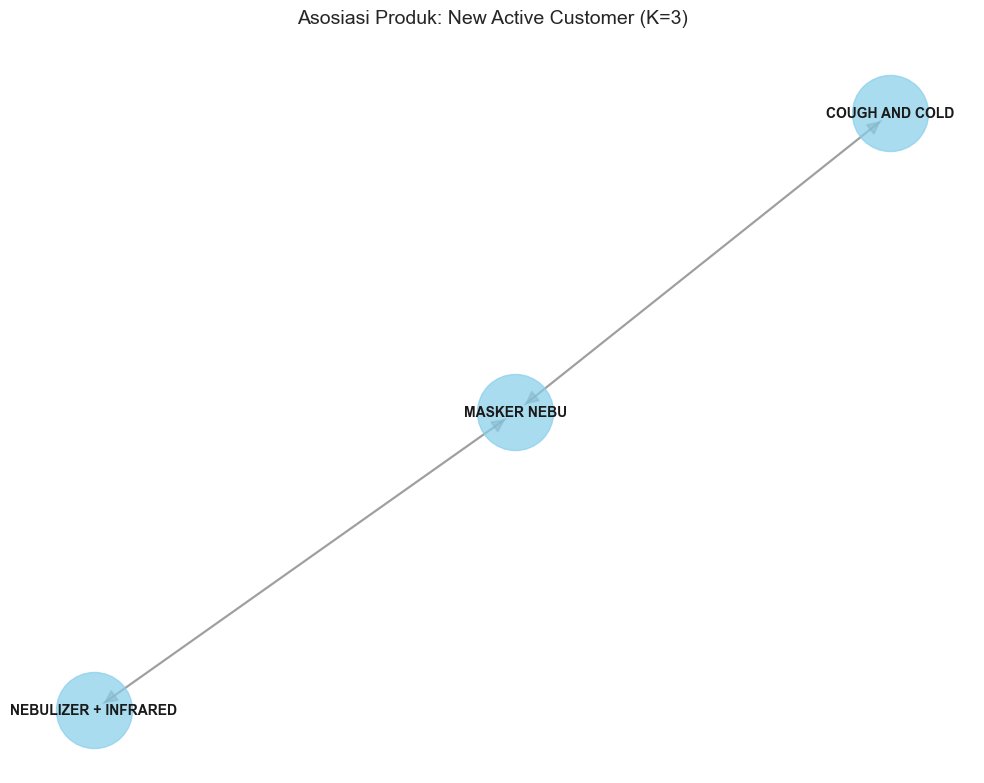

 Hasil rekomendasi untuk New Active Customer siap disimpan.


 ANALISIS: Core Loyal Customer (ID: 1)


KeyboardInterrupt: 

In [94]:
from babyspa_data.models import Product
from babyspa_data.models.cluster_lrfm import ClusterLRFM
from babyspa_data.services.fp_growth_engine import FPGrowthEngine

# ==============================================================================
# 1. GENERATE ENGINE MAPPING LANGSUNG DARI STRUKTUR FISIK DB TERKINI
# ==============================================================================
# Tarik data semua produk aktif yang memiliki keterikatan dengan induk master
db_products = Product.active_objects.filter(master_product__isnull=False).values(
    'id', 
    'master_product_id', 
    'master_product__item_name'
)

# Bangun ulang kamus penterjemah berbasis kondisi riil database
db_id_mapping = {}
db_name_mapping = {}

for p in db_products:
    # Contoh: {id_anak: id_master}
    db_id_mapping[p['id']] = p['master_product_id']
    # Contoh: {id_master: "NAMA MASTER CLEAN"}
    db_name_mapping[p['master_product_id']] = p['master_product__item_name']

# ==============================================================================
# 2. RUN FP-GROWTH ENGINE
# ==============================================================================
fp_engine = FPGrowthEngine(min_support=0.05, min_threshold=1.0)
active_clusters = ClusterLRFM.active_objects.filter(k_value=3).order_by('cluster_id')

print(f" Memulai analisis FP-Growth untuk {active_clusters.count()} klaster aktif...\n")

for cluster in active_clusters:
    group_name = cluster.lrfm_reference.group_name if cluster.lrfm_reference else f"Cluster {cluster.cluster_id}"
    
    print("="*60)
    print(f" ANALISIS: {group_name} (ID: {cluster.cluster_id})")
    print("="*60)
    
    # Masukkan mapping yang valid dan sinkron dengan database fisik
    rules = fp_engine.run_fp_growth(
        cluster_obj=cluster, 
        id_mapping=db_id_mapping, 
        name_mapping=db_name_mapping
    )
    
    if rules is not None and not rules.empty:
        print(f" Ditemukan {len(rules)} rules.")
        display(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(30))
        
        fp_engine.visualize_rules(
            rules, 
            title=f"Asosiasi Produk: {group_name} (K=3)"
        )
        
        # fp_engine.save_to_db(rules, cluster_obj=cluster) 
        print(f" Hasil rekomendasi untuk {group_name} siap disimpan.")
    else:
        print(f"Tidak ditemukan pola asosiasi yang memenuhi syarat support/threshold di klaster ini.")
    
    print("\n")

print(" Semua proses iterasi selesai.")

#### Setelah Filtrasi

 Memproses 3 klaster dengan filter Top-5 SAW-AHP...

 ANALISIS TERFILTER: New Active Customer (ID: 0)
 Ditemukan 2 rules yang mengarah ke produk Top-N.


,antecedents,consequents,support,confidence,lift
0,frozenset({COUGH AND COLD}),frozenset({MASKER NEBU}),0.50,0.98,1.08
2,frozenset({NEBULIZER + INFRARED}),frozenset({MASKER NEBU}),0.37,0.98,1.07


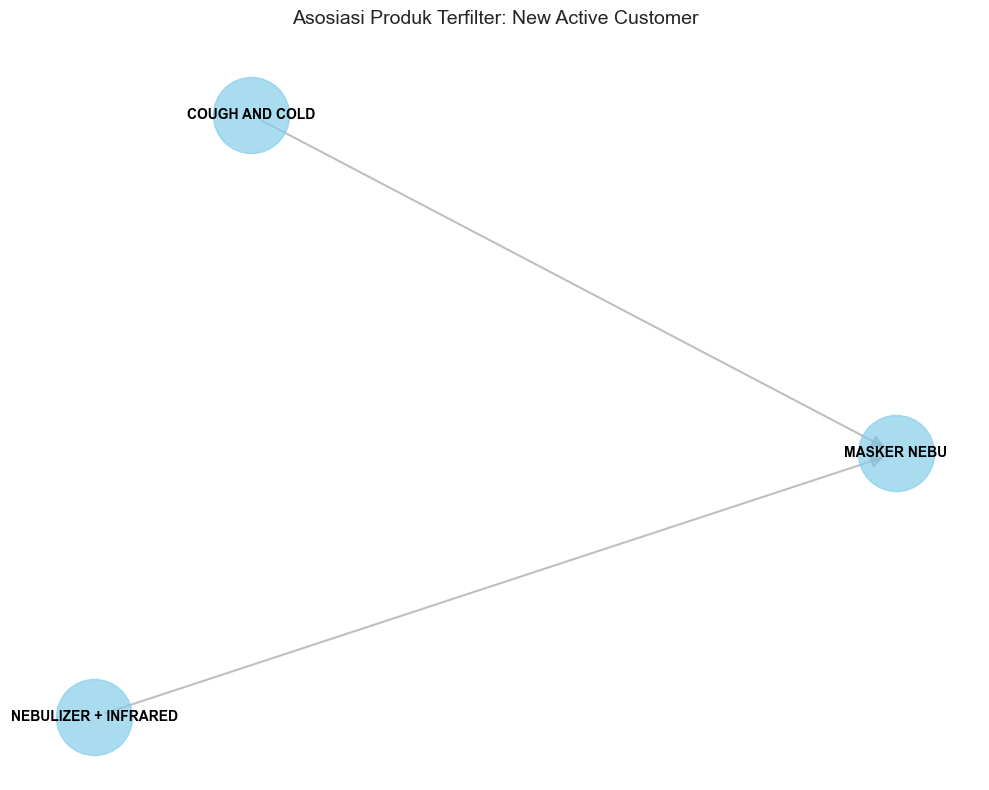



 ANALISIS TERFILTER: Core Loyal Customer (ID: 1)
 Ditemukan 1 rules yang mengarah ke produk Top-N.


,antecedents,consequents,support,confidence,lift
3,frozenset({MASKER NEBU}),frozenset({COUGH AND COLD}),0.37,0.56,1.11


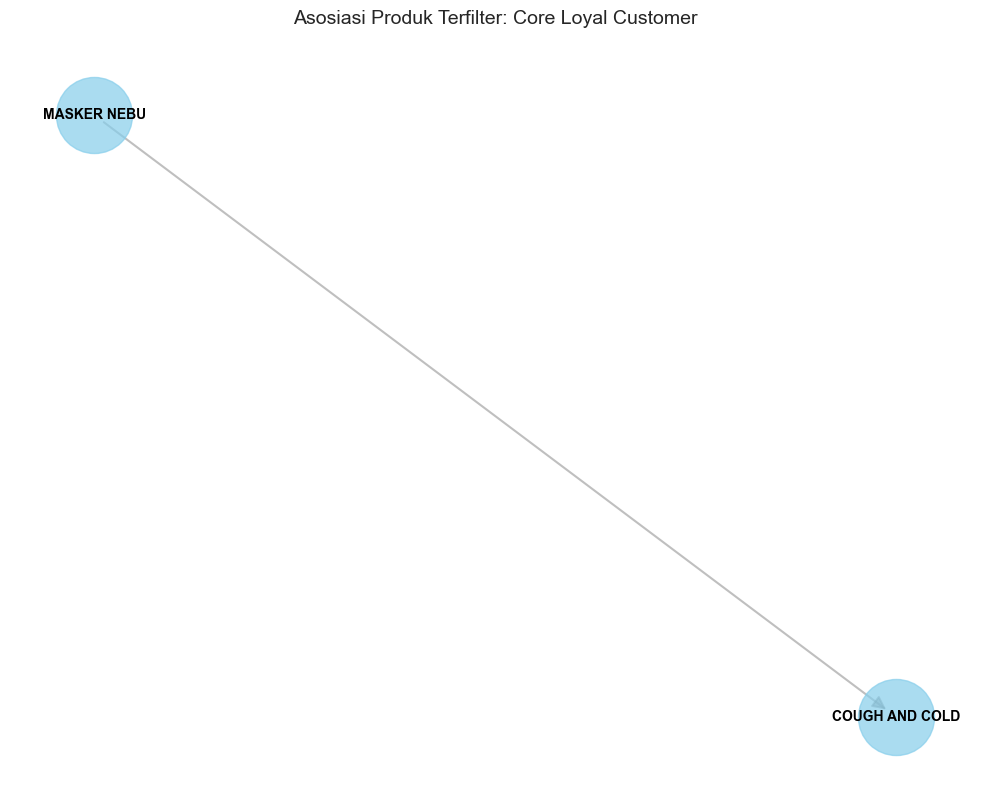



 ANALISIS TERFILTER: Inactive Newbie (ID: 2)
 Ditemukan 3 rules yang mengarah ke produk Top-N.


,antecedents,consequents,support,confidence,lift
1,frozenset({GROOMING BABY}),frozenset({BABY AND KID MASSAGE}),0.07,0.91,2.19
2,frozenset({COUGH AND COLD}),"frozenset({BABY AND KID MASSAGE, MASKER NEBU})",0.09,0.24,1.80
7,frozenset({COUGH AND COLD}),frozenset({BABY AND KID MASSAGE}),0.21,0.58,1.40


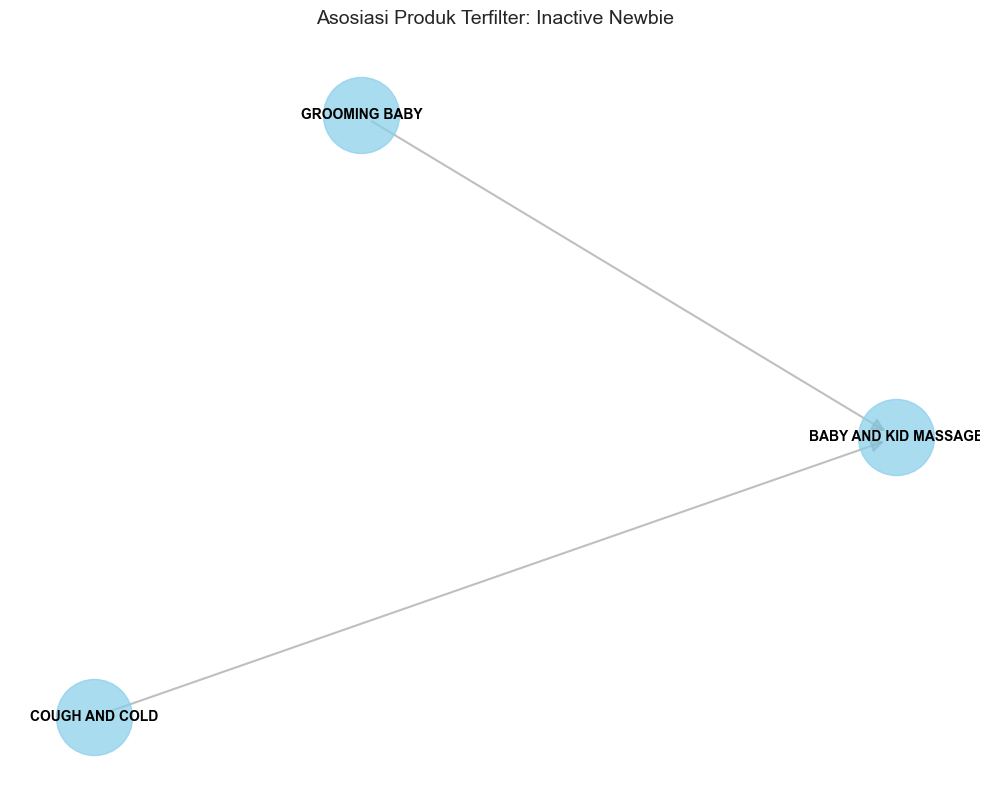

In [ ]:
# ==============================================================================
# 1. GENERATE ENGINE MAPPING DARI STRUKTUR FISIK DB TERKINI
# ==============================================================================
db_products = Product.active_objects.filter(master_product__isnull=False).values(
    'id', 
    'master_product_id', 
    'master_product__item_name'
)

db_id_mapping = {}
db_name_mapping = {}

for p in db_products:
    db_id_mapping[p['id']] = p['master_product_id']
    db_name_mapping[p['master_product_id']] = p['master_product__item_name']

# ==============================================================================
# 2. RUN FILTERED ANALYSIS (CONSTRAINT-BASED FP-GROWTH)
# ==============================================================================
fp_engine = FPGrowthEngine(min_support=0.05, min_threshold=1.0)
k_target = 3

# Inject mapping yang murni berasal dari data fisik database
results_filtered = fp_engine.run_filtered_analysis_by_k(
    k_value=k_target, 
    id_mapping=db_id_mapping, 
    name_mapping=db_name_mapping
)

if results_filtered:
    print(f" Memproses {len(results_filtered)} klaster dengan filter Top-5 SAW-AHP...\n")
    
    for cluster_id, df_rules in results_filtered.items():
        cluster_obj = ClusterLRFM.active_objects.get(cluster_id=cluster_id, k_value=k_target)
        group_name = cluster_obj.lrfm_reference.group_name if cluster_obj.lrfm_reference else f"Cluster {cluster_id}"
        
        print("="*60)
        print(f" ANALISIS TERFILTER: {group_name} (ID: {cluster_id})")
        print("="*60)
        print(f" Ditemukan {len(df_rules)} rules yang mengarah ke produk Top-N.")
        
        display(df_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(30))
        
        fp_engine.visualize_rules(df_rules, title=f"Asosiasi Produk Terfilter: {group_name}")
        print("\n")
else:
    print("Tidak ditemukan hasil yang memenuhi kriteria filter.")

In [ ]:
# Pastikan results_filtered sudah tersedia dari sel sebelumnya
if 'results_filtered' in locals() and results_filtered:
    print(" Memulai proses sinkronisasi ke database...\n")
    
    for cluster_id, df_rules in results_filtered.items():
        # Ambil objek klaster sebagai referensi foreign key
        cluster_obj = ClusterLRFM.active_objects.get(cluster_id=cluster_id, k_value=k_target)
        group_name = cluster_obj.lrfm_reference.group_name
        
        # Memicu pembersihan data lama (Hard Delete M2M) dan penyimpanan baru
        fp_engine.save_to_db(df_rules, cluster_obj=cluster_obj)
        
        print(f" [OK] Rekomendasi untuk '{group_name}' berhasil diperbarui.")
    
    print("\n Semua data klaster telah disinkronkan ke tabel ProductRecommendation.")
else:
    print(" Error: Tidak ada data hasil analisis untuk disimpan. Jalankan Blok 1 terlebih dahulu.")

 Memulai proses sinkronisasi ke database...

Berhasil mensinkronisasi 2 rules untuk klaster 0.
 [OK] Rekomendasi untuk 'New Active Customer' berhasil diperbarui.
Berhasil mensinkronisasi 1 rules untuk klaster 1.
 [OK] Rekomendasi untuk 'Core Loyal Customer' berhasil diperbarui.
Berhasil mensinkronisasi 3 rules untuk klaster 2.
 [OK] Rekomendasi untuk 'Inactive Newbie' berhasil diperbarui.

 Semua data klaster telah disinkronkan ke tabel ProductRecommendation.


In [101]:
from babyspa_data.models.product import ProductRecommendation

# 1. Tarik semua data rekomendasi yang baru saja disinkronkan
# Gunakan select_related untuk efisiensi query pada cluster_lrfm
recommendations = ProductRecommendation.active_objects.select_related(
    'cluster_lrfm', 
    'cluster_lrfm__lrfm_reference'
).all().filter(
    cluster_lrfm__k_value=3
).order_by('cluster_lrfm__cluster_id', 'rank_n')

# 2. Transformasi data menjadi list of dictionaries
rec_data = []
for rec in recommendations:
    # Gabungkan semua produk di antecedent dan consequent menjadi string
    antecedents_str = ", ".join(rec.antecedent.values_list('item_name', flat=True))
    consequents_str = ", ".join(rec.consequent.values_list('item_name', flat=True))
    
    rec_data.append({
        'Cluster ID': rec.cluster_lrfm.cluster_id if rec.cluster_lrfm else None,
        'Segment Name': rec.cluster_lrfm.lrfm_reference.group_name if rec.cluster_lrfm and rec.cluster_lrfm.lrfm_reference else "N/A",
        'Antecedents (Trigger)': antecedents_str,
        'Consequents (Recommended)': consequents_str,
        'Support': rec.support,
        'Confidence': rec.confidence,
        'Lift': rec.lift,
        'Rank': rec.rank_n
    })

# 3. Buat DataFrame
df_final_recommendation = pd.DataFrame(rec_data)

# Tampilkan DataFrame
print("DAFTAR REKOMENDASI BUNDLING TERFILTER (DATABASE)")
print("="*50)
display(df_final_recommendation)

DAFTAR REKOMENDASI BUNDLING TERFILTER (DATABASE)


,Cluster ID,Segment Name,Antecedents (Trigger),Consequents (Recommended),Support,Confidence,Lift,Rank
0,0,New Active Customer,COUGH AND COLD,MASKER NEBU,0.50,0.98,1.08,1
1,0,New Active Customer,NEBULIZER + INFRARED,MASKER NEBU,0.37,0.98,1.07,3
2,1,Core Loyal Customer,MASKER NEBU,COUGH AND COLD,0.37,0.56,1.11,4
3,2,Inactive Newbie,"GROOMING BABY, GROOMING BABY","BABY AND KID MASSAGE, BABY AND KID MASSAGE",0.07,0.91,2.19,2
4,2,Inactive Newbie,COUGH AND COLD,"BABY AND KID MASSAGE, MASKER NEBU, BABY AND KID MASSAGE",0.09,0.24,1.80,3
5,2,Inactive Newbie,COUGH AND COLD,"BABY AND KID MASSAGE, BABY AND KID MASSAGE",0.21,0.58,1.40,8


### Perhitungan Nilai K=2

#### Sebelum Filtrasi

 Memulai analisis FP-Growth untuk 2 klaster aktif...

 ANALISIS: Inactive Newbie (ID: 0)
 Ditemukan 6 rules.


,antecedents,consequents,support,confidence,lift
0,frozenset({MASKER NEBU}),frozenset({NEBULIZER + INFRARED}),0.34,0.47,1.28
1,frozenset({NEBULIZER + INFRARED}),frozenset({MASKER NEBU}),0.34,0.94,1.28
2,frozenset({COUGH AND COLD}),frozenset({MASKER NEBU}),0.35,0.82,1.12
3,frozenset({MASKER NEBU}),frozenset({COUGH AND COLD}),0.35,0.48,1.12
4,frozenset({COUGH AND COLD}),frozenset({BABY AND KID MASSAGE}),0.11,0.26,1.01
5,frozenset({BABY AND KID MASSAGE}),frozenset({COUGH AND COLD}),0.11,0.43,1.01


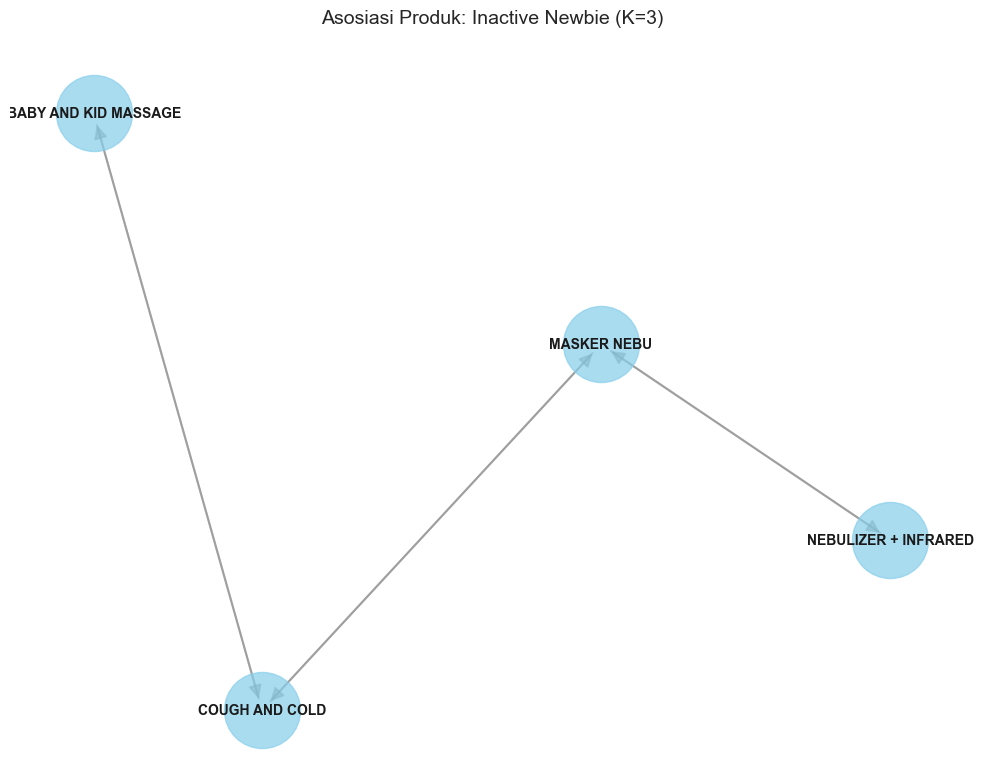

 Hasil rekomendasi untuk Inactive Newbie siap disimpan.


 ANALISIS: Core Loyal Customer (ID: 1)
 Ditemukan 6 rules.


,antecedents,consequents,support,confidence,lift
0,frozenset({NEBULIZER + INFRARED}),frozenset({MASKER NEBU}),0.23,0.90,1.35
1,frozenset({MASKER NEBU}),frozenset({NEBULIZER + INFRARED}),0.23,0.35,1.35
2,frozenset({COUGH AND COLD}),frozenset({MASKER NEBU}),0.37,0.74,1.11
3,frozenset({MASKER NEBU}),frozenset({COUGH AND COLD}),0.37,0.56,1.11
4,frozenset({COUGH AND COLD}),"frozenset({BABY AND KID MASSAGE, MASKER NEBU})",0.05,0.10,1.01
5,"frozenset({BABY AND KID MASSAGE, MASKER NEBU})",frozenset({COUGH AND COLD}),0.05,0.51,1.01


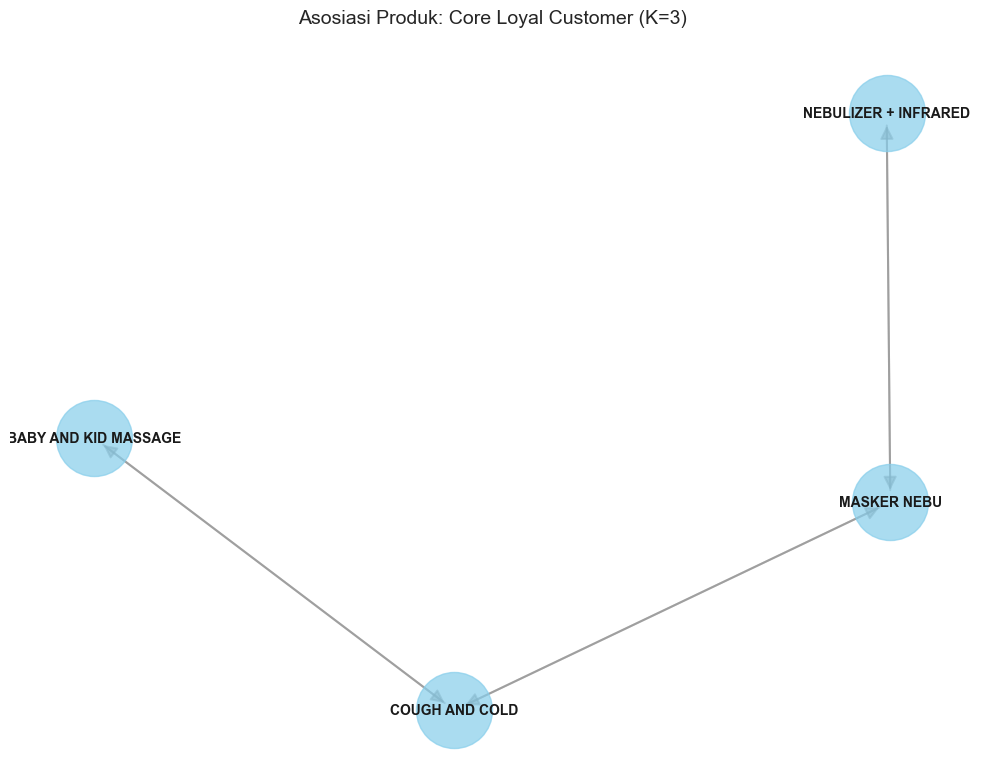

 Hasil rekomendasi untuk Core Loyal Customer siap disimpan.


 Semua proses iterasi selesai.


In [ ]:
from babyspa_data.models import Product
from babyspa_data.models.cluster_lrfm import ClusterLRFM
from babyspa_data.services.fp_growth_engine import FPGrowthEngine

# ==============================================================================
# 1. GENERATE ENGINE MAPPING LANGSUNG DARI STRUKTUR FISIK DB TERKINI
# ==============================================================================
# Tarik data semua produk aktif yang memiliki keterikatan dengan induk master
db_products = Product.active_objects.filter(master_product__isnull=False).values(
    'id', 
    'master_product_id', 
    'master_product__item_name'
)

# Bangun ulang kamus penterjemah berbasis kondisi riil database
db_id_mapping = {}
db_name_mapping = {}

for p in db_products:
    # Contoh: {id_anak: id_master}
    db_id_mapping[p['id']] = p['master_product_id']
    # Contoh: {id_master: "NAMA MASTER CLEAN"}
    db_name_mapping[p['master_product_id']] = p['master_product__item_name']

# ==============================================================================
# 2. RUN FP-GROWTH ENGINE
# ==============================================================================
fp_engine = FPGrowthEngine(min_support=0.05, min_threshold=1.0)
active_clusters = ClusterLRFM.active_objects.filter(k_value=2).order_by('cluster_id')

print(f" Memulai analisis FP-Growth untuk {active_clusters.count()} klaster aktif...\n")

for cluster in active_clusters:
    group_name = cluster.lrfm_reference.group_name if cluster.lrfm_reference else f"Cluster {cluster.cluster_id}"
    
    print("="*60)
    print(f" ANALISIS: {group_name} (ID: {cluster.cluster_id})")
    print("="*60)
    
    # Masukkan mapping yang valid dan sinkron dengan database fisik
    rules = fp_engine.run_fp_growth(
        cluster_obj=cluster, 
        id_mapping=db_id_mapping, 
        name_mapping=db_name_mapping
    )
    
    if rules is not None and not rules.empty:
        print(f" Ditemukan {len(rules)} rules.")
        display(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(30))
        
        fp_engine.visualize_rules(
            rules, 
            title=f"Asosiasi Produk: {group_name} (K=3)"
        )
        
        # fp_engine.save_to_db(rules, cluster_obj=cluster) 
        print(f" Hasil rekomendasi untuk {group_name} siap disimpan.")
    else:
        print(f"Tidak ditemukan pola asosiasi yang memenuhi syarat support/threshold di klaster ini.")
    
    print("\n")

print(" Semua proses iterasi selesai.")

#### Setelah Filtrasi

 Memproses 2 klaster dengan filter Top-5 SAW-AHP...

 ANALISIS TERFILTER: Inactive Newbie (ID: 0)
 Ditemukan 1 rules yang mengarah ke produk Top-N.


,antecedents,consequents,support,confidence,lift
4,frozenset({COUGH AND COLD}),frozenset({BABY AND KID MASSAGE}),0.11,0.26,1.01


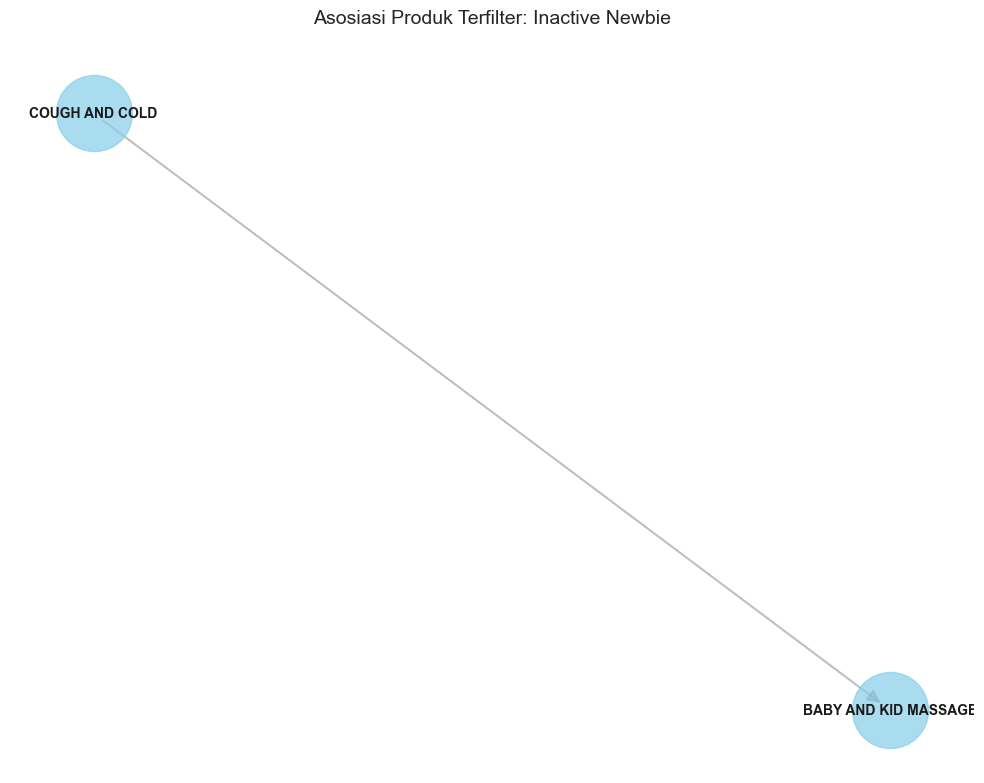



 ANALISIS TERFILTER: Core Loyal Customer (ID: 1)
 Ditemukan 3 rules yang mengarah ke produk Top-N.


,antecedents,consequents,support,confidence,lift
3,frozenset({MASKER NEBU}),frozenset({COUGH AND COLD}),0.37,0.56,1.11
4,frozenset({COUGH AND COLD}),"frozenset({BABY AND KID MASSAGE, MASKER NEBU})",0.05,0.10,1.01
5,"frozenset({BABY AND KID MASSAGE, MASKER NEBU})",frozenset({COUGH AND COLD}),0.05,0.51,1.01


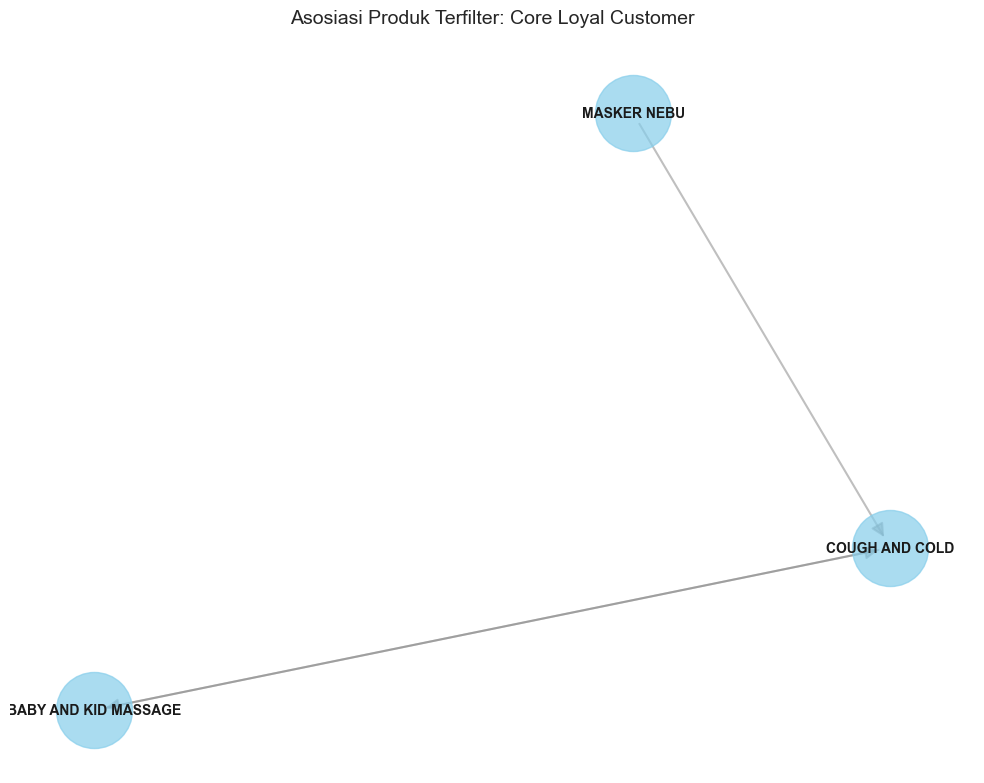

In [ ]:
# ==============================================================================
# 1. GENERATE ENGINE MAPPING DARI STRUKTUR FISIK DB TERKINI
# ==============================================================================
db_products = Product.active_objects.filter(master_product__isnull=False).values(
    'id', 
    'master_product_id', 
    'master_product__item_name'
)

db_id_mapping = {}
db_name_mapping = {}

for p in db_products:
    db_id_mapping[p['id']] = p['master_product_id']
    db_name_mapping[p['master_product_id']] = p['master_product__item_name']

# ==============================================================================
# 2. RUN FILTERED ANALYSIS (CONSTRAINT-BASED FP-GROWTH)
# ==============================================================================
fp_engine = FPGrowthEngine(min_support=0.05, min_threshold=1.0)
k_target = 2

# Inject mapping yang murni berasal dari data fisik database
results_filtered = fp_engine.run_filtered_analysis_by_k(
    k_value=k_target, 
    id_mapping=db_id_mapping, 
    name_mapping=db_name_mapping
)

if results_filtered:
    print(f" Memproses {len(results_filtered)} klaster dengan filter Top-5 SAW-AHP...\n")
    
    for cluster_id, df_rules in results_filtered.items():
        cluster_obj = ClusterLRFM.active_objects.get(cluster_id=cluster_id, k_value=k_target)
        group_name = cluster_obj.lrfm_reference.group_name if cluster_obj.lrfm_reference else f"Cluster {cluster_id}"
        
        print("="*60)
        print(f" ANALISIS TERFILTER: {group_name} (ID: {cluster_id})")
        print("="*60)
        print(f" Ditemukan {len(df_rules)} rules yang mengarah ke produk Top-N.")
        
        display(df_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(30))
        
        fp_engine.visualize_rules(df_rules, title=f"Asosiasi Produk Terfilter: {group_name}")
        print("\n")
else:
    print("Tidak ditemukan hasil yang memenuhi kriteria filter.")

In [98]:
# Pastikan results_filtered sudah tersedia dari sel sebelumnya
if 'results_filtered' in locals() and results_filtered:
    print(" Memulai proses sinkronisasi ke database...\n")
    
    for cluster_id, df_rules in results_filtered.items():
        # Ambil objek klaster sebagai referensi foreign key
        cluster_obj = ClusterLRFM.active_objects.get(cluster_id=cluster_id, k_value=k_target)
        group_name = cluster_obj.lrfm_reference.group_name
        
        # Memicu pembersihan data lama (Hard Delete M2M) dan penyimpanan baru
        fp_engine.save_to_db(df_rules, cluster_obj=cluster_obj)
        
        print(f" [OK] Rekomendasi untuk '{group_name}' berhasil diperbarui.")
    
    print("\n Semua data klaster telah disinkronkan ke tabel ProductRecommendation.")
else:
    print(" Error: Tidak ada data hasil analisis untuk disimpan. Jalankan Blok 1 terlebih dahulu.")

 Memulai proses sinkronisasi ke database...

Berhasil mensinkronisasi 1 rules untuk klaster 0.
 [OK] Rekomendasi untuk 'Inactive Newbie' berhasil diperbarui.
Berhasil mensinkronisasi 3 rules untuk klaster 1.
 [OK] Rekomendasi untuk 'Core Loyal Customer' berhasil diperbarui.

 Semua data klaster telah disinkronkan ke tabel ProductRecommendation.


In [100]:
from babyspa_data.models.product import ProductRecommendation

# 1. Tarik semua data rekomendasi yang baru saja disinkronkan
# Gunakan select_related untuk efisiensi query pada cluster_lrfm
recommendations = ProductRecommendation.active_objects.select_related(
    'cluster_lrfm', 
    'cluster_lrfm__lrfm_reference'
).all().filter(
    cluster_lrfm__k_value=2
).order_by('cluster_lrfm__cluster_id', 'rank_n')

# 2. Transformasi data menjadi list of dictionaries
rec_data = []
for rec in recommendations:
    # Gabungkan semua produk di antecedent dan consequent menjadi string
    antecedents_str = ", ".join(rec.antecedent.values_list('item_name', flat=True))
    consequents_str = ", ".join(rec.consequent.values_list('item_name', flat=True))
    
    rec_data.append({
        'Cluster ID': rec.cluster_lrfm.cluster_id if rec.cluster_lrfm else None,
        'Segment Name': rec.cluster_lrfm.lrfm_reference.group_name if rec.cluster_lrfm and rec.cluster_lrfm.lrfm_reference else "N/A",
        'Antecedents (Trigger)': antecedents_str,
        'Consequents (Recommended)': consequents_str,
        'Support': rec.support,
        'Confidence': rec.confidence,
        'Lift': rec.lift,
        'Rank': rec.rank_n
    })

# 3. Buat DataFrame
df_final_recommendation = pd.DataFrame(rec_data)

# Tampilkan DataFrame
print("DAFTAR REKOMENDASI BUNDLING TERFILTER (DATABASE)")
print("="*50)
display(df_final_recommendation)

DAFTAR REKOMENDASI BUNDLING TERFILTER (DATABASE)


,Cluster ID,Segment Name,Antecedents (Trigger),Consequents (Recommended),Support,Confidence,Lift,Rank
0,0,Inactive Newbie,COUGH AND COLD,"BABY AND KID MASSAGE, BABY AND KID MASSAGE",0.11,0.26,1.01,5
1,1,Core Loyal Customer,MASKER NEBU,COUGH AND COLD,0.37,0.56,1.11,4
2,1,Core Loyal Customer,COUGH AND COLD,"BABY AND KID MASSAGE, MASKER NEBU, BABY AND KID MASSAGE",0.05,0.10,1.01,5
3,1,Core Loyal Customer,"BABY AND KID MASSAGE, MASKER NEBU, BABY AND KID MASSAGE",COUGH AND COLD,0.05,0.51,1.01,6


## Analisis dan Evaluasi

### Karakteristik Cluster K=3

In [ ]:
import pandas as pd
from babyspa_data.models.cluster_lrfm import ClusterLRFM
from babyspa_data.models.customer_segment import CustomerSegment
from babyspa_data.models.product import Product, ProductScore, ProductRecommendation
import textwrap

# 1. Tentukan target nilai K
k_target = 3

# 2. Ambil semua data segmentasi customer untuk K=3
# Menggunakan select_related untuk mengoptimalkan pengambilan data klaster dan referensinya
customer_segments = CustomerSegment.active_objects.select_related(
    'cluster_lrfm',
    'cluster_lrfm__lrfm_reference',
    'customer'  # Asumsi ada relasi ke data customer yang menyimpan nilai L, R, F, M asli
).filter(cluster_lrfm__k_value=k_target)

# 3. Ekstraksi data dari ORM Django ke list of dictionaries
raw_data = []
for segment in customer_segments:
    raw_data.append({
        'Cluster ID': segment.cluster_lrfm.cluster_id,
        'Segment Name': segment.cluster_lrfm.lrfm_reference.group_name if segment.cluster_lrfm.lrfm_reference else "Unknown",
        'Segment Description': segment.cluster_lrfm.lrfm_reference.description if segment.cluster_lrfm.lrfm_reference else "No description",
        'Length': segment.l_real,       # Sesuaikan jika field LRFM Anda berada langsung di segment
        'Recency': segment.r_real,
        'Frequency': segment.f_real,
        'Monetary': segment.m_real,
        # 'Age (Months)': segment.age_month,
        'Age (Months)': segment.age,
        'CLV': segment.clv_score
    })

# 4. Konversi ke DataFrame Pandas
df_customers = pd.DataFrame(raw_data)

if not df_customers.empty:
    print(f"KARAKTERISTIK STATISTIK KLASTER (K={k_target})")
    print("=" * 80)
    print(f"Total Pelanggan yang dianalisis: {len(df_customers)}\n")
   
    # 5. Iterasi untuk setiap klaster secara rapi
    unique_clusters = df_customers['Cluster ID'].unique()
    unique_clusters.sort()
    
    for c_id in unique_clusters:
        # Filter data spesifik untuk klaster ini
        df_cluster_spesifik = df_customers[df_customers['Cluster ID'] == c_id]
        segment_name = df_cluster_spesifik['Segment Name'].iloc[0]
        raw_description = df_cluster_spesifik['Segment Description'].iloc[0]
        
        print(f"Jumlah Pelanggan di Cluster {c_id} ({segment_name}): {len(df_cluster_spesifik)}")

        print(f"\n[TABEL] Karakteristik Klaster {c_id}: {segment_name}")
        print(f"Deskripsi Kelompok:\n{textwrap.fill(raw_description, width=80)}")

        print("-" * 60)        
        # 6. Hitung agregasi statistik (Mean, Min, Max, Median) untuk metrik LRFM
        df_stats = df_cluster_spesifik[['Length', 'Recency', 'Frequency', 'Monetary', 'Age (Months)', 'CLV']].agg([
            'mean', 
            'min', 
            'max', 
            'median'
        ]).round(2)
        
        # Transpose tabel agar metrik (L, R, F, M) menjadi baris dan statistik menjadi kolom (seperti jurnal ilmiah)
        df_stats_formatted = df_stats.T
        df_stats_formatted.columns = ['Mean', 'Min', 'Max', 'Median']
        
        # Visualisasi Tabel di Notebook
        display(df_stats_formatted)
        
        # produk yang top n di cluser n di k_value 3
         # produk yang top n di cluser n di k_value 3 (Hanya Master dan Produk Mandiri)
        # produk yang top n di cluser n di k_value 3 (Query dimulai dari ProductScore)
        print(f"Top Produk yang Direkomendasikan untuk Cluster {c_id} ({segment_name}):")

        # Kita mulai dari ProductScore agar select_related bekerja optimal mengurangi query (N+1)
        top_scores = ProductScore.active_objects.filter(
            cluster_id__cluster_id=c_id,
            cluster_id__k_value=k_target,
            is_top_n=True,
            # Melakukan filter ke tabel Product untuk memastikan produk tersebut adalah Master / Mandiri
            product__master_product__isnull=True 
        ).select_related(
            'product', 
            'cluster_id', 
            'cluster_id__lrfm_reference'
        ).order_by('rank').all()[:5]  # Ambil Top 5 saja

        # Tampilkan Top N Produk di kluster ini
        print(f"Produk yang direkomendasikan untuk cluster {c_id} ({segment_name}):")
        for score_obj in top_scores:
            # score_obj.product mengakses objek Product yang sudah di-cache oleh select_related
            print(f"- {score_obj.product.item_name} (Rank: {score_obj.rank})")
            
        #m menampilkan bundling dari ProductRecommendation untuk cluster ini
        print(f"\nBundling Produk yang Direkomendasikan untuk Cluster {c_id} ({segment_name}):")
        bundling_recs = ProductRecommendation.active_objects.filter(
            cluster_lrfm__cluster_id=c_id,
            cluster_lrfm__k_value=k_target
        ).select_related(
            'cluster_lrfm',
            'cluster_lrfm__lrfm_reference'
        ).prefetch_related(
            'antecedent',
            'consequent'
        ).order_by('rank_n')    
        
        
        # Tampilkan bundling rekomendasi untuk klaster ini
        for rec in bundling_recs:
            antecedents_str = ", ".join(rec.antecedent.values_list('item_name', flat=True))
            consequents_str = ", ".join(rec.consequent.values_list('item_name', flat=True))
            print(f"{{{antecedents_str}, {consequents_str}}}")        
        print("\n")
else:
    print(f"Tidak ada data customer segment yang ditemukan untuk K={k_target}.")

KARAKTERISTIK STATISTIK KLASTER (K=3)
Total Pelanggan yang dianalisis: 18195

Jumlah Pelanggan di Cluster 0 (New Active Customer): 6795

[TABEL] Karakteristik Klaster 0: New Active Customer
Deskripsi Kelompok:
Pelanggan yang cenderung baru bergabung atau baru kembali mencoba layanan.
Meskipun mereka baru saja berinteraksi (paling fresh), namun frekuensi kunjungan
dan total uang yang mereka belanjakan masih di bawah rata-rata.
------------------------------------------------------------


,Mean,Min,Max,Median
Length,0.01,0.00,43.00,0.00
Recency,320.14,0.00,630.00,333.00
Frequency,1.00,1.00,2.00,1.00
Monetary,"143,321.78",0.00,"750,000.00","135,000.00"
Age (Months),93.81,1.00,"1,003.00",24.00
CLV,0.19,0.01,0.48,0.19


Top Produk yang Direkomendasikan untuk Cluster 0 (New Active Customer):
Produk yang direkomendasikan untuk cluster 0 (New Active Customer):
- BABY AND KID MASSAGE (Rank: 1)
- SUNNY BRIGHT BABY 3-12 M (Rank: 2)
- SUNNY BRIGHT BABY (Rank: 3)
- BRIGHT KIDS (Rank: 4)
- MASKER NEBU (Rank: 5)

Bundling Produk yang Direkomendasikan untuk Cluster 0 (New Active Customer):
{COUGH AND COLD, MASKER NEBU}
{NEBULIZER + INFRARED, MASKER NEBU}


Jumlah Pelanggan di Cluster 1 (Core Loyal Customer): 6343

[TABEL] Karakteristik Klaster 1: Core Loyal Customer
Deskripsi Kelompok:
Kelompok pelanggan paling berharga dan setia. Mereka memiliki durasi hubungan
paling lama, paling sering datang, dan mengeluarkan uang paling banyak untuk
layanan/produk Anda dibandingkan kelompok lainnya.
------------------------------------------------------------


,Mean,Min,Max,Median
Length,261.68,1.00,"1,185.00",176.00
Recency,393.30,6.00,"1,183.00",320.00
Frequency,4.45,2.00,102.00,3.00
Monetary,"542,611.15","100,000.00","9,085,000.00","375,000.00"
Age (Months),72.71,1.00,"1,042.00",34.00
CLV,0.62,0.38,0.90,0.61


Top Produk yang Direkomendasikan untuk Cluster 1 (Core Loyal Customer):
Produk yang direkomendasikan untuk cluster 1 (Core Loyal Customer):
- BABY AND KID MASSAGE (Rank: 1)
- BRIGHT KIDS (Rank: 2)
- SUNNY BRIGHT BABY 3-12 M (Rank: 3)
- SUNNY BRIGHT BABY (Rank: 4)
- COUGH AND COLD (Rank: 5)

Bundling Produk yang Direkomendasikan untuk Cluster 1 (Core Loyal Customer):
{MASKER NEBU, COUGH AND COLD}


Jumlah Pelanggan di Cluster 2 (Inactive Newbie): 5057

[TABEL] Karakteristik Klaster 2: Inactive Newbie
Deskripsi Kelompok:
Pelanggan lama yang sudah sangat lama tidak berkunjung (hampir 3 tahun).
Meskipun dulu pernah bertransaksi, saat ini mereka memiliki risiko tinggi telah
berhenti berlangganan karena frekuensi dan nilai belanjanya sangat minim.
------------------------------------------------------------


,Mean,Min,Max,Median
Length,0.04,0.00,34.00,0.00
Recency,925.42,619.00,"1,212.00",929.00
Frequency,1.00,1.00,2.00,1.00
Monetary,"147,155.43","30,000.00","970,000.00","150,000.00"
Age (Months),122.59,3.00,947.00,45.00
CLV,0.37,0.26,0.76,0.37


Top Produk yang Direkomendasikan untuk Cluster 2 (Inactive Newbie):
Produk yang direkomendasikan untuk cluster 2 (Inactive Newbie):
- BABY AND KID MASSAGE (Rank: 1)
- BRIGHT KIDS (Rank: 2)
- SUNNY BRIGHT BABY 3-12 M (Rank: 3)
- GENERAL FISIOTERAPI (Rank: 4)
- MOM CARE SPA (Rank: 5)

Bundling Produk yang Direkomendasikan untuk Cluster 2 (Inactive Newbie):
{GROOMING BABY, GROOMING BABY, BABY AND KID MASSAGE, BABY AND KID MASSAGE}
{COUGH AND COLD, BABY AND KID MASSAGE, MASKER NEBU, BABY AND KID MASSAGE}
{COUGH AND COLD, BABY AND KID MASSAGE, BABY AND KID MASSAGE}




In [ ]:
import pandas as pd
from babyspa_data.models.cluster_lrfm import ClusterLRFM
from babyspa_data.models.customer_segment import CustomerSegment
from babyspa_data.models.product import Product, ProductScore, ProductRecommendation

# 1. Tentukan target nilai K
k_target = 3

# 2. Ambil semua data segmentasi customer untuk K=3
customer_segments = CustomerSegment.active_objects.select_related(
    'cluster_lrfm',
    'cluster_lrfm__lrfm_reference',
    'customer'  
).filter(cluster_lrfm__k_value=k_target)

# 3. Ekstraksi data dari ORM Django ke list of dictionaries
raw_data = []
for segment in customer_segments:
    raw_data.append({
        'Cluster ID': segment.cluster_lrfm.cluster_id,
        'Segment Name': segment.cluster_lrfm.lrfm_reference.group_name if segment.cluster_lrfm.lrfm_reference else "Unknown",
        'Length': segment.l_real,       
        'Recency': segment.r_real,
        'Frequency': segment.f_real,
        'Monetary': segment.m_real,
        'Age (Months)': segment.age,
        'CLV': segment.clv_score
    })

# 4. Konversi ke DataFrame Pandas
df_customers = pd.DataFrame(raw_data)

if not df_customers.empty:
    print(f"KARAKTERISTIK STATISTIK KLASTER (K={k_target})")
    print("=" * 80)
    print(f"Total Pelanggan yang dianalisis: {len(df_customers)}\n")
    
    # 5. Iterasi untuk setiap klaster secara rapi
    unique_clusters = df_customers['Cluster ID'].unique()
    unique_clusters.sort()
    
    for c_id in unique_clusters:
        # Filter data spesifik untuk klaster ini
        df_cluster_spesifik = df_customers[df_customers['Cluster ID'] == c_id]
        segment_name = df_cluster_spesifik['Segment Name'].iloc[0]
        print(f"Jumlah Pelanggan di Cluster {c_id} ({segment_name}): {len(df_cluster_spesifik)}")

        print(f"\n[TABEL] Karakteristik Klaster {c_id}: {segment_name}")
        print("-" * 60)
        
        # 6. Hitung agregasi statistik (Mean, Min, Max, Median) untuk metrik LRFM
        df_stats = df_cluster_spesifik[['Length', 'Recency', 'Frequency', 'Monetary', 'Age (Months)', 'CLV']].agg([
            'mean', 'min', 'max', 'median'
        ]).round(2)
        
        df_stats_formatted = df_stats.T
        df_stats_formatted.columns = ['Mean', 'Min', 'Max', 'Median']
        
        # Visualisasi Tabel di Notebook
        display(df_stats_formatted)
        
        print(f"Top Produk yang Direkomendasikan untuk Cluster {c_id} ({segment_name}):")

        # Query dimulai dari ProductScore
        top_scores = ProductScore.active_objects.filter(
            cluster_id__cluster_id=c_id,
            cluster_id__k_value=k_target,
            is_top_n=True,
            product__master_product__isnull=True 
        ).select_related(
            'product', 
            'cluster_id', 
            'cluster_id__lrfm_reference'
        ).order_by('rank')

        # Tampilkan Top N Produk di kluster ini
        print(f"Produk yang direkomendasikan untuk cluster {c_id} ({segment_name}):")
        for score_obj in top_scores:
            print(f"- {score_obj.product.item_name} (Rank: {score_obj.rank})")
            
        # Menampilkan bundling dari ProductRecommendation untuk cluster ini
        print(f"\nBundling Produk yang Direkomendasikan untuk Cluster {c_id} ({segment_name}):")
        bundling_recs = ProductRecommendation.active_objects.filter(
            cluster_lrfm__cluster_id=c_id,
            cluster_lrfm__k_value=k_target
        ).select_related(
            'cluster_lrfm',
            'cluster_lrfm__lrfm_reference'
        ).prefetch_related(
            'antecedent',
            'consequent'
        ).order_by('rank_n')    
        
        # Tampilkan bundling rekomendasi untuk klaster ini
        for rec in bundling_recs:
            # OPTIMASI UTAMA: Menggunakan list comprehension agar memanfaatkan cache dari prefetch_related
            antecedents_str = ", ".join([p.item_name for p in rec.antecedent.all()])
            consequents_str = ", ".join([p.item_name for p in rec.consequent.all()])
            print(f"{{{antecedents_str}, {consequents_str}}}")        
        print("\n")
else:
    print(f"Tidak ada data customer segment yang ditemukan untuk K={k_target}.")

KARAKTERISTIK STATISTIK KLASTER (K=3)
Total Pelanggan yang dianalisis: 18195

Jumlah Pelanggan di Cluster 0 (New Active Customer): 6795

[TABEL] Karakteristik Klaster 0: New Active Customer
------------------------------------------------------------


,Mean,Min,Max,Median
Length,0.01,0.00,43.00,0.00
Recency,320.14,0.00,630.00,333.00
Frequency,1.00,1.00,2.00,1.00
Monetary,"143,321.78",0.00,"750,000.00","135,000.00"
Age (Months),93.81,1.00,"1,003.00",24.00
CLV,0.19,0.01,0.48,0.19


Top Produk yang Direkomendasikan untuk Cluster 0 (New Active Customer):
Produk yang direkomendasikan untuk cluster 0 (New Active Customer):
- BABY AND KID MASSAGE (Rank: 1)
- SUNNY BRIGHT BABY 3-12 M (Rank: 2)
- SUNNY BRIGHT BABY (Rank: 3)
- BRIGHT KIDS (Rank: 4)
- MASKER NEBU (Rank: 5)
- MID PREGNANCY (Rank: 6)
- GENERAL FISIOTERAPI (Rank: 7)
- SIBLING KID SPA (Rank: 8)
- COUGH AND COLD (Rank: 9)
- FISIOTERAPI (Rank: 10)

Bundling Produk yang Direkomendasikan untuk Cluster 0 (New Active Customer):
{COUGH AND COLD, MASKER NEBU}
{NEBULIZER + INFRARED, MASKER NEBU}


Jumlah Pelanggan di Cluster 1 (Core Loyal Customer): 6343

[TABEL] Karakteristik Klaster 1: Core Loyal Customer
------------------------------------------------------------


,Mean,Min,Max,Median
Length,261.68,1.00,"1,185.00",176.00
Recency,393.30,6.00,"1,183.00",320.00
Frequency,4.45,2.00,102.00,3.00
Monetary,"542,611.15","100,000.00","9,085,000.00","375,000.00"
Age (Months),72.71,1.00,"1,042.00",34.00
CLV,0.62,0.38,0.90,0.61


Top Produk yang Direkomendasikan untuk Cluster 1 (Core Loyal Customer):
Produk yang direkomendasikan untuk cluster 1 (Core Loyal Customer):
- BABY AND KID MASSAGE (Rank: 1)
- BRIGHT KIDS (Rank: 2)
- SUNNY BRIGHT BABY 3-12 M (Rank: 3)
- SUNNY BRIGHT BABY (Rank: 4)
- COUGH AND COLD (Rank: 5)
- SIBLING KID SPA (Rank: 6)
- NEBULIZER + INFRARED (Rank: 7)
- GENERAL FISIOTERAPI (Rank: 8)
- MASKER NEBU (Rank: 9)
- FISIOTERAPI (Rank: 10)

Bundling Produk yang Direkomendasikan untuk Cluster 1 (Core Loyal Customer):
{MASKER NEBU, COUGH AND COLD}


Jumlah Pelanggan di Cluster 2 (Inactive Newbie): 5057

[TABEL] Karakteristik Klaster 2: Inactive Newbie
------------------------------------------------------------


,Mean,Min,Max,Median
Length,0.04,0.00,34.00,0.00
Recency,925.42,619.00,"1,212.00",929.00
Frequency,1.00,1.00,2.00,1.00
Monetary,"147,155.43","30,000.00","970,000.00","150,000.00"
Age (Months),122.59,3.00,947.00,45.00
CLV,0.37,0.26,0.76,0.37


Top Produk yang Direkomendasikan untuk Cluster 2 (Inactive Newbie):
Produk yang direkomendasikan untuk cluster 2 (Inactive Newbie):
- BABY AND KID MASSAGE (Rank: 1)
- BRIGHT KIDS (Rank: 2)
- SUNNY BRIGHT BABY 3-12 M (Rank: 3)
- GENERAL FISIOTERAPI (Rank: 4)
- MOM CARE SPA (Rank: 5)
- NEBULIZER + INFRARED (Rank: 6)
- SIBLING BUNDLING (KID SPA) (Rank: 7)
- MASKER NEBU (Rank: 8)
- BODY MASSAGE (Rank: 9)
- EARLY PREGNANCY (Rank: 10)

Bundling Produk yang Direkomendasikan untuk Cluster 2 (Inactive Newbie):
{GROOMING BABY, GROOMING BABY, BABY AND KID MASSAGE, BABY AND KID MASSAGE}
{COUGH AND COLD, BABY AND KID MASSAGE, MASKER NEBU, BABY AND KID MASSAGE}
{COUGH AND COLD, BABY AND KID MASSAGE, BABY AND KID MASSAGE}




In [ ]:

import pandas as pd
from django.db.models import Count
from babyspa_data.models.transactions import Transaction, TransactionItem

# ==============================================================================
# 1. VALUE COUNTS STATUS PADA TABEL TRANSACTION (HEADER)
# ==============================================================================
# Mengambil data menggunakan agregasi Django ORM
query_header = Transaction.active_objects.values('status').annotate(jumlah=Count('id')).order_by('-jumlah')

# Konversi langsung ke Pandas DataFrame agar tampilan rapi
df_status_header = pd.DataFrame(list(query_header))

print("=== DISTRIBUSI STATUS TRANSACTION (HEADER) ===")
display(df_status_header)


print("\n" + "="*50 + "\n")


# ==============================================================================
# 2. VALUE COUNTS STATUS PADA TABEL TRANSACTION ITEM (DETAIL)
# ==============================================================================

query_item = TransactionItem.active_objects.values('status').annotate(jumlah=Count('id')).order_by('-jumlah')

# Konversi langsung ke Pandas DataFrame agar tampilan rapi
df_status_item = pd.DataFrame(list(query_item))

print("=== DISTRIBUSI STATUS TRANSACTION ITEM (DETAIL) ===")
display(df_status_item)

=== DISTRIBUSI STATUS TRANSACTION (HEADER) ===


,status,jumlah
0,PAID,35289
1,UNKNOWN,8869
2,VOIDED,1546
3,UNPAID,72




=== DISTRIBUSI STATUS TRANSACTION ITEM (DETAIL) ===


,status,jumlah
0,COMPLETED,43070
1,CANCELED,5281
2,NEW,1147
3,STARTED,851
4,ARRIVED,407
5,NO SHOW,63
6,CONFIRMED,7


 Data Sukses Dimuat. Memulai kalkulasi visual untuk 18195 sampel pelanggan...



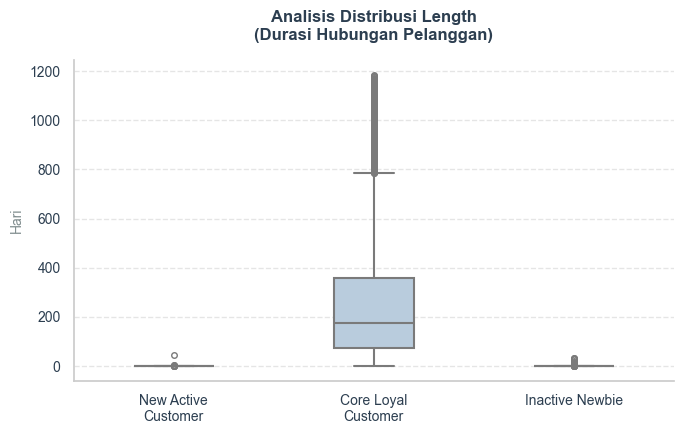

 Ringkasan Statistik Deskriptif untuk Variabel: Length


,Length (MIN),Length (MAX),Length (MEAN),Length (MEDIAN)
Klaster,,,,
Core Loyal Customer,1.00,1185.00,261.68,176.00
Inactive Newbie,0.00,34.00,0.04,0.00
New Active Customer,0.00,43.00,0.01,0.00


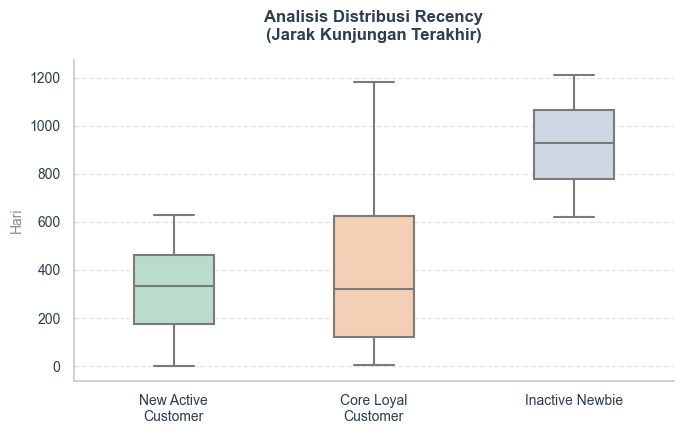

 Ringkasan Statistik Deskriptif untuk Variabel: Recency


,Recency (MIN),Recency (MAX),Recency (MEAN),Recency (MEDIAN)
Klaster,,,,
Core Loyal Customer,6.00,1183.00,393.30,320.00
Inactive Newbie,619.00,1212.00,925.42,929.00
New Active Customer,0.00,630.00,320.14,333.00


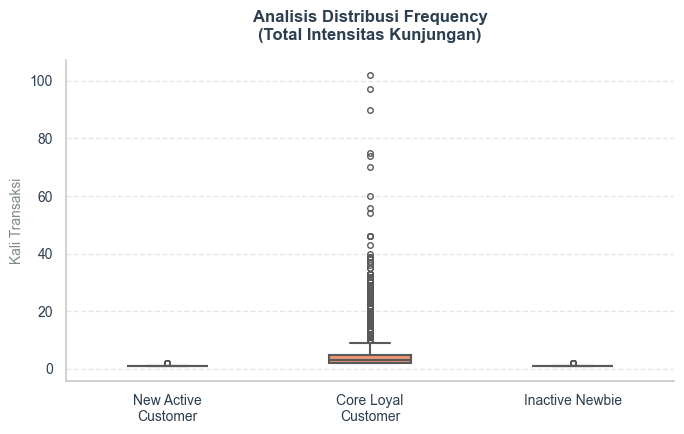

 Ringkasan Statistik Deskriptif untuk Variabel: Frequency


,Frequency (MIN),Frequency (MAX),Frequency (MEAN),Frequency (MEDIAN)
Klaster,,,,
Core Loyal Customer,2.00,102.00,4.45,3.00
Inactive Newbie,1.00,2.00,1.00,1.00
New Active Customer,1.00,2.00,1.00,1.00


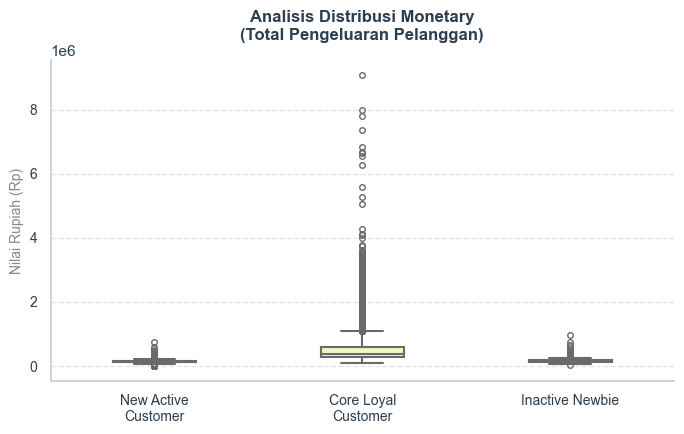

 Ringkasan Statistik Deskriptif untuk Variabel: Monetary


,Monetary (MIN),Monetary (MAX),Monetary (MEAN),Monetary (MEDIAN)
Klaster,,,,
Core Loyal Customer,100000.00,9085000.00,542611.15,375000.00
Inactive Newbie,30000.00,970000.00,147155.43,150000.00
New Active Customer,0.00,750000.00,143321.78,135000.00


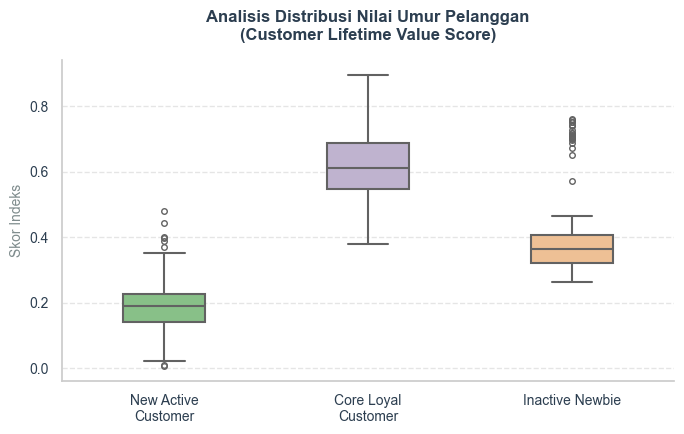

 Ringkasan Statistik Deskriptif untuk Variabel: CLV Score


,CLV Score (MIN),CLV Score (MAX),CLV Score (MEAN),CLV Score (MEDIAN)
Klaster,,,,
Core Loyal Customer,0.38,0.90,0.62,0.61
Inactive Newbie,0.26,0.76,0.37,0.37
New Active Customer,0.01,0.48,0.19,0.19


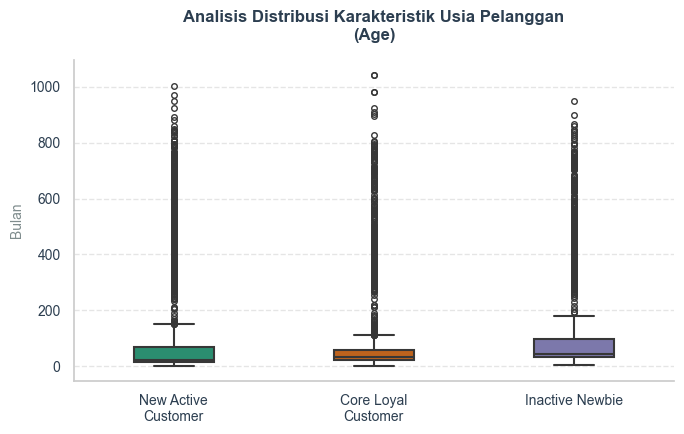

 Ringkasan Statistik Deskriptif untuk Variabel: Age (Bulan)


,Age (Bulan) (MIN),Age (Bulan) (MAX),Age (Bulan) (MEAN),Age (Bulan) (MEDIAN)
Klaster,,,,
Core Loyal Customer,1,1042,72.71,34.00
Inactive Newbie,3,947,122.59,45.00
New Active Customer,1,1003,93.81,24.00


In [ ]:
import textwrap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from babyspa_data.models.customer_segment import CustomerSegment

# ==============================================================================
# 1. EKSTRAKSI DATA MENGGUNAKAN DJANGO QUERYSET
# ==============================================================================
# Menarik data menggunakan select_related untuk efisiensi join tabel di background
segments_queryset = CustomerSegment.objects.filter(
    cluster_lrfm__k_value=3
).select_related('cluster_lrfm__lrfm_reference')

data_list = []
for segment in segments_queryset:
    data_list.append({
        'Klaster': segment.cluster_lrfm.lrfm_reference.group_name if segment.cluster_lrfm else "Unclustered",
        'Length': segment.l_real,
        'Recency': segment.r_real,
        'Frequency': segment.f_real,
        'Monetary': segment.m_real,
        'CLV Score': segment.clv_score,
        'Age (Bulan)': segment.age
    })

df = pd.DataFrame(data_list)

# Set tema dasar visualisasi (Clean style untuk jurnal/tesis)
sns.set_theme(style="whitegrid", rc={"grid.linestyle": "--", "grid.alpha": 0.5})

# Bungkus nama klaster yang panjang agar muat secara horizontal rata di sumbu X
df['Klaster_Label'] = df['Klaster'].apply(lambda x: "\n".join(textwrap.wrap(x, width=15)))


# ==============================================================================
# 2. FUNGSI GENERATOR ANALISIS ITERATIF PER VARIABEL
# ==============================================================================
def generate_variable_analysis(feature_name, title_text, y_label, color_palette="Set2"):
    if df.empty:
        print(f"⚠ Data kosong, tidak bisa memproses variabel {feature_name}.")
        return
        
    # A. Render Boxplot Tunggal (Decluttered)
    fig, ax = plt.subplots(figsize=(7, 4.5))
    
    sns.boxplot(
        ax=ax,
        x='Klaster_Label', 
        y=feature_name, 
        data=df, 
        palette=color_palette,
        hue='Klaster_Label',
        legend=False,
        width=0.4,
        linewidth=1.5,
        fliersize=4
    )
    
    ax.set_title(title_text, fontsize=12, fontweight='bold', pad=15, color='#2C3E50')
    ax.set_xlabel('', labelpad=0)
    ax.set_ylabel(y_label, fontsize=10, color='#7F8C8D')
    ax.tick_params(axis='both', labelsize=10, colors='#2C3E50')
    
    # Hapus garis bingkai atas dan kanan (Decluttering maksimal)
    sns.despine(ax=ax, top=True, right=True)
    
    plt.tight_layout()
    plt.show()
    
    # B. Render Tabel Ringkasan Deskriptif Presisi
    print(f" Ringkasan Statistik Deskriptif untuk Variabel: {feature_name}")
    stats = df.groupby('Klaster')[feature_name].agg(['min', 'max', 'mean', 'median'])
    stats.columns = [f"{feature_name} ({c.upper()})" for c in stats.columns]
    
    # Tampilkan dataframe dengan style format 2 desimal belakang koma dan gradasi warna
    display(stats.style.format(precision=2).background_gradient(cmap='YlGnBu', axis=0))
    print("\n" + "="*85 + "\n")


# ==============================================================================
# 3. EKSEKUSI PROSES SECARA BERURUTAN (ITERATIF)
# ==============================================================================
if df.empty:
    print("⚠ Peringatan: Tidak ada data yang ditemukan untuk k_value = 3 di dalam database kamu.")
else:
    print(f" Data Sukses Dimuat. Memulai kalkulasi visual untuk {len(df)} sampel pelanggan...\n")
    
    # 1. Variabel Length (L)
    generate_variable_analysis(
        feature_name='Length', 
        title_text='Analisis Distribusi Length\n(Durasi Hubungan Pelanggan)', 
        y_label='Hari',
        color_palette='Pastel1'
    )

    # 2. Variabel Recency (R)
    generate_variable_analysis(
        feature_name='Recency', 
        title_text='Analisis Distribusi Recency\n(Jarak Kunjungan Terakhir)', 
        y_label='Hari',
        color_palette='Pastel2'
    )

    # 3. Variabel Frequency (F)
    generate_variable_analysis(
        feature_name='Frequency', 
        title_text='Analisis Distribusi Frequency\n(Total Intensitas Kunjungan)', 
        y_label='Kali Transaksi',
        color_palette='Set2'
    )

    # 4. Variabel Monetary (M)
    generate_variable_analysis(
        feature_name='Monetary', 
        title_text='Analisis Distribusi Monetary\n(Total Pengeluaran Pelanggan)', 
        y_label='Nilai Rupiah (Rp)',
        color_palette='Set3'
    )

    # 5. Variabel Customer Lifetime Value (CLV Score)
    generate_variable_analysis(
        feature_name='CLV Score', 
        title_text='Analisis Distribusi Nilai Umur Pelanggan\n(Customer Lifetime Value Score)', 
        y_label='Skor Indeks',
        color_palette='Accent'
    )

    # 6. Variabel Usia Anak/Bayi (Age)
    generate_variable_analysis(
        feature_name='Age (Bulan)', 
        title_text='Analisis Distribusi Karakteristik Usia Pelanggan\n(Age)', 
        y_label='Bulan',
        color_palette='Dark2'
    )

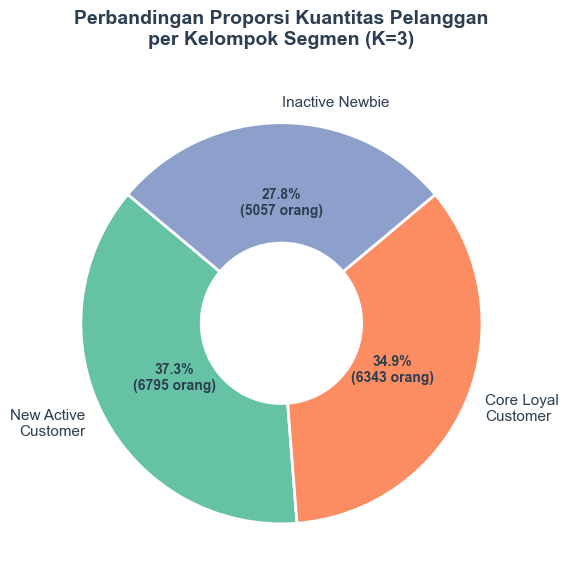

📊 Tabel Distribusi Volume Pelanggan:


,Jumlah Pelanggan,Persentase (%)
Klaster,,
New Active Customer,6795,37.350000
Core Loyal Customer,6343,34.860000
Inactive Newbie,5057,27.790000


In [ ]:
import textwrap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from babyspa_data.models.customer_segment import CustomerSegment

# ==============================================================================
# 1. EKSTRAKSI DATA & AGREGASI JUMLAH PELANGGAN PER KLASTER
# ==============================================================================
segments_queryset = CustomerSegment.objects.filter(
    cluster_lrfm__k_value=3
).select_related('cluster_lrfm__lrfm_reference')

data_list = []
for segment in segments_queryset:
    data_list.append({
        'Klaster': segment.cluster_lrfm.lrfm_reference.group_name if segment.cluster_lrfm else "Unclustered"
    })

df = pd.DataFrame(data_list)

if df.empty:
    print("⚠ Peringatan: Tidak ada data yang ditemukan untuk k_value = 3 di dalam database kamu.")
else:
    # Hitung volume (jumlah) pelanggan per kelompok
    cluster_counts = df['Klaster'].value_counts()
    
    # Bungkus teks nama klaster yang panjang agar rapi di label chart
    labels = [textwrap.fill(label, 15) for label in cluster_counts.index]
    sizes = cluster_counts.values

    # ==============================================================================
    # 2. VISUALISASI PIE CHART (DECLUTTERED STYLE)
    # ==============================================================================
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Fungsi kustom untuk memunculkan persentase sekaligus jumlah riil data di dalam lingkaran
    def make_autopct(values):
        def my_autopct(pct):
            total = sum(values)
            val = int(round(pct * total / 100.0))
            return f'{pct:.1f}%\n({val} orang)'
        return my_autopct

    # Membuat diagram pai menggunakan palet warna Set2 yang elegan
    colors = sns.color_palette("Set2", len(labels))
    
    wedges, texts, autotexts = ax.pie(
        sizes, 
        labels=labels, 
        autopct=make_autopct(sizes),
        startangle=140, 
        colors=colors,
        textprops=dict(color="#2C3E50", fontsize=11),
        wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2) # Efek Donut Chart yang modern & bersih
    )

    # Mempertegas teks persentase di dalam diagram
    for autotext in autotexts:
        autotext.set_fontsize(10)
        autotext.set_weight('bold')
        autotext.set_color('#2C3E50')

    ax.set_title('Perbandingan Proporsi Kuantitas Pelanggan\nper Kelompok Segmen (K=3)', 
                 fontsize=14, fontweight='bold', pad=20, color='#2C3E50')
    
    plt.tight_layout()
    plt.show()

    # ==============================================================================
    # 3. TABEL DISTRIBUSI FREKUENSI DATA
    # ==============================================================================
    print("📊 Tabel Distribusi Volume Pelanggan:")
    summary_table = pd.DataFrame({
        'Jumlah Pelanggan': sizes,
        'Persentase (%)': (sizes / sum(sizes) * 100).round(2)
    }, index=cluster_counts.index)
    
    display(summary_table.style.background_gradient(cmap='YlGnBu', axis=0))

### Karakteristik Cluster K=2

In [102]:
import pandas as pd
from babyspa_data.models.cluster_lrfm import ClusterLRFM
from babyspa_data.models.customer_segment import CustomerSegment
from babyspa_data.models.product import Product, ProductScore, ProductRecommendation
import textwrap

# 1. Tentukan target nilai K
k_target = 2

# 2. Ambil semua data segmentasi customer untuk K=3
# Menggunakan select_related untuk mengoptimalkan pengambilan data klaster dan referensinya
customer_segments = CustomerSegment.active_objects.select_related(
    'cluster_lrfm',
    'cluster_lrfm__lrfm_reference',
    'customer'  # Asumsi ada relasi ke data customer yang menyimpan nilai L, R, F, M asli
).filter(cluster_lrfm__k_value=k_target)

# 3. Ekstraksi data dari ORM Django ke list of dictionaries
raw_data = []
for segment in customer_segments:
    raw_data.append({
        'Cluster ID': segment.cluster_lrfm.cluster_id,
        'Segment Name': segment.cluster_lrfm.lrfm_reference.group_name if segment.cluster_lrfm.lrfm_reference else "Unknown",
        'Segment Description': segment.cluster_lrfm.lrfm_reference.description if segment.cluster_lrfm.lrfm_reference else "No description",
        'Length': segment.l_real,       # Sesuaikan jika field LRFM Anda berada langsung di segment
        'Recency': segment.r_real,
        'Frequency': segment.f_real,
        'Monetary': segment.m_real,
        # 'Age (Months)': segment.age_month,
        'Age (Months)': segment.age,
        'CLV': segment.clv_score
    })

# 4. Konversi ke DataFrame Pandas
df_customers = pd.DataFrame(raw_data)

if not df_customers.empty:
    print(f"KARAKTERISTIK STATISTIK KLASTER (K={k_target})")
    print("=" * 80)
    print(f"Total Pelanggan yang dianalisis: {len(df_customers)}\n")
   
    # 5. Iterasi untuk setiap klaster secara rapi
    unique_clusters = df_customers['Cluster ID'].unique()
    unique_clusters.sort()
    
    for c_id in unique_clusters:
        # Filter data spesifik untuk klaster ini
        df_cluster_spesifik = df_customers[df_customers['Cluster ID'] == c_id]
        segment_name = df_cluster_spesifik['Segment Name'].iloc[0]
        raw_description = df_cluster_spesifik['Segment Description'].iloc[0]
        
        print(f"Jumlah Pelanggan di Cluster {c_id} ({segment_name}): {len(df_cluster_spesifik)}")

        print(f"\n[TABEL] Karakteristik Klaster {c_id}: {segment_name}")
        print(f"Deskripsi Kelompok:\n{textwrap.fill(raw_description, width=80)}")

        print("-" * 60)        
        # 6. Hitung agregasi statistik (Mean, Min, Max, Median) untuk metrik LRFM
        df_stats = df_cluster_spesifik[['Length', 'Recency', 'Frequency', 'Monetary', 'Age (Months)', 'CLV']].agg([
            'mean', 
            'min', 
            'max', 
            'median'
        ]).round(2)
        
        # Transpose tabel agar metrik (L, R, F, M) menjadi baris dan statistik menjadi kolom (seperti jurnal ilmiah)
        df_stats_formatted = df_stats.T
        df_stats_formatted.columns = ['Mean', 'Min', 'Max', 'Median']
        
        # Visualisasi Tabel di Notebook
        display(df_stats_formatted)
        
        # produk yang top n di cluser n di k_value 3
         # produk yang top n di cluser n di k_value 3 (Hanya Master dan Produk Mandiri)
        # produk yang top n di cluser n di k_value 3 (Query dimulai dari ProductScore)
        print(f"Top Produk yang Direkomendasikan untuk Cluster {c_id} ({segment_name}):")

        # Kita mulai dari ProductScore agar select_related bekerja optimal mengurangi query (N+1)
        top_scores = ProductScore.active_objects.filter(
            cluster_id__cluster_id=c_id,
            cluster_id__k_value=k_target,
            is_top_n=True,
            # Melakukan filter ke tabel Product untuk memastikan produk tersebut adalah Master / Mandiri
            product__master_product__isnull=True 
        ).select_related(
            'product', 
            'cluster_id', 
            'cluster_id__lrfm_reference'
        ).order_by('rank').all()[:5]  # Ambil Top 5 saja

        # Tampilkan Top N Produk di kluster ini
        print(f"Produk yang direkomendasikan untuk cluster {c_id} ({segment_name}):")
        for score_obj in top_scores:
            # score_obj.product mengakses objek Product yang sudah di-cache oleh select_related
            print(f"- {score_obj.product.item_name} (Rank: {score_obj.rank})")
            
        #m menampilkan bundling dari ProductRecommendation untuk cluster ini
        print(f"\nBundling Produk yang Direkomendasikan untuk Cluster {c_id} ({segment_name}):")
        bundling_recs = ProductRecommendation.active_objects.filter(
            cluster_lrfm__cluster_id=c_id,
            cluster_lrfm__k_value=k_target
        ).select_related(
            'cluster_lrfm',
            'cluster_lrfm__lrfm_reference'
        ).prefetch_related(
            'antecedent',
            'consequent'
        ).order_by('rank_n')    
        
        
        # Tampilkan bundling rekomendasi untuk klaster ini
        for rec in bundling_recs:
            antecedents_str = ", ".join(rec.antecedent.values_list('item_name', flat=True))
            consequents_str = ", ".join(rec.consequent.values_list('item_name', flat=True))
            print(f"{{{antecedents_str}, {consequents_str}}}")        
        print("\n")
else:
    print(f"Tidak ada data customer segment yang ditemukan untuk K={k_target}.")

KARAKTERISTIK STATISTIK KLASTER (K=2)
Total Pelanggan yang dianalisis: 18195

Jumlah Pelanggan di Cluster 0 (Inactive Newbie): 11835

[TABEL] Karakteristik Klaster 0: Inactive Newbie
Deskripsi Kelompok:
Pelanggan lama yang sudah sangat lama tidak berkunjung (hampir 3 tahun).
Meskipun dulu pernah bertransaksi, saat ini mereka memiliki risiko tinggi telah
berhenti berlangganan karena frekuensi dan nilai belanjanya sangat minim.
------------------------------------------------------------


,Mean,Min,Max,Median
Length,0.01,0.00,43.00,0.00
Recency,577.98,0.00,"1,212.00",530.00
Frequency,1.00,1.00,2.00,1.00
Monetary,"144,872.54",0.00,"970,000.00","135,000.00"
Age (Months),106.03,1.00,"1,003.00",37.00
CLV,0.26,0.01,0.71,0.25


Top Produk yang Direkomendasikan untuk Cluster 0 (Inactive Newbie):
Produk yang direkomendasikan untuk cluster 0 (Inactive Newbie):
- BABY AND KID MASSAGE (Rank: 1)
- SUNNY BRIGHT BABY 3-12 M (Rank: 2)
- BRIGHT KIDS (Rank: 3)
- SUNNY BRIGHT BABY (Rank: 4)
- MID PREGNANCY (Rank: 5)

Bundling Produk yang Direkomendasikan untuk Cluster 0 (Inactive Newbie):
{COUGH AND COLD, BABY AND KID MASSAGE, BABY AND KID MASSAGE}


Jumlah Pelanggan di Cluster 1 (Core Loyal Customer): 6360

[TABEL] Karakteristik Klaster 1: Core Loyal Customer
Deskripsi Kelompok:
Kelompok pelanggan paling berharga dan setia. Mereka memiliki durasi hubungan
paling lama, paling sering datang, dan mengeluarkan uang paling banyak untuk
layanan/produk Anda dibandingkan kelompok lainnya.
------------------------------------------------------------


,Mean,Min,Max,Median
Length,261.01,1.00,"1,185.00",175.00
Recency,394.58,6.00,"1,183.00",321.00
Frequency,4.44,2.00,102.00,3.00
Monetary,"541,706.37","100,000.00","9,085,000.00","375,000.00"
Age (Months),72.90,1.00,"1,042.00",35.00
CLV,0.62,0.37,0.90,0.61


Top Produk yang Direkomendasikan untuk Cluster 1 (Core Loyal Customer):
Produk yang direkomendasikan untuk cluster 1 (Core Loyal Customer):
- BABY AND KID MASSAGE (Rank: 1)
- BRIGHT KIDS (Rank: 2)
- SUNNY BRIGHT BABY 3-12 M (Rank: 3)
- SUNNY BRIGHT BABY (Rank: 4)
- COUGH AND COLD (Rank: 5)

Bundling Produk yang Direkomendasikan untuk Cluster 1 (Core Loyal Customer):
{MASKER NEBU, COUGH AND COLD}
{COUGH AND COLD, BABY AND KID MASSAGE, MASKER NEBU, BABY AND KID MASSAGE}
{BABY AND KID MASSAGE, MASKER NEBU, BABY AND KID MASSAGE, COUGH AND COLD}




In [103]:
import pandas as pd
from babyspa_data.models.cluster_lrfm import ClusterLRFM
from babyspa_data.models.customer_segment import CustomerSegment
from babyspa_data.models.product import Product, ProductScore, ProductRecommendation

# 1. Tentukan target nilai K
k_target = 2

# 2. Ambil semua data segmentasi customer untuk K=3
customer_segments = CustomerSegment.active_objects.select_related(
    'cluster_lrfm',
    'cluster_lrfm__lrfm_reference',
    'customer'  
).filter(cluster_lrfm__k_value=k_target)

# 3. Ekstraksi data dari ORM Django ke list of dictionaries
raw_data = []
for segment in customer_segments:
    raw_data.append({
        'Cluster ID': segment.cluster_lrfm.cluster_id,
        'Segment Name': segment.cluster_lrfm.lrfm_reference.group_name if segment.cluster_lrfm.lrfm_reference else "Unknown",
        'Length': segment.l_real,       
        'Recency': segment.r_real,
        'Frequency': segment.f_real,
        'Monetary': segment.m_real,
        'Age (Months)': segment.age,
        'CLV': segment.clv_score
    })

# 4. Konversi ke DataFrame Pandas
df_customers = pd.DataFrame(raw_data)

if not df_customers.empty:
    print(f"KARAKTERISTIK STATISTIK KLASTER (K={k_target})")
    print("=" * 80)
    print(f"Total Pelanggan yang dianalisis: {len(df_customers)}\n")
    
    # 5. Iterasi untuk setiap klaster secara rapi
    unique_clusters = df_customers['Cluster ID'].unique()
    unique_clusters.sort()
    
    for c_id in unique_clusters:
        # Filter data spesifik untuk klaster ini
        df_cluster_spesifik = df_customers[df_customers['Cluster ID'] == c_id]
        segment_name = df_cluster_spesifik['Segment Name'].iloc[0]
        print(f"Jumlah Pelanggan di Cluster {c_id} ({segment_name}): {len(df_cluster_spesifik)}")

        print(f"\n[TABEL] Karakteristik Klaster {c_id}: {segment_name}")
        print("-" * 60)
        
        # 6. Hitung agregasi statistik (Mean, Min, Max, Median) untuk metrik LRFM
        df_stats = df_cluster_spesifik[['Length', 'Recency', 'Frequency', 'Monetary', 'Age (Months)', 'CLV']].agg([
            'mean', 'min', 'max', 'median'
        ]).round(2)
        
        df_stats_formatted = df_stats.T
        df_stats_formatted.columns = ['Mean', 'Min', 'Max', 'Median']
        
        # Visualisasi Tabel di Notebook
        display(df_stats_formatted)
        
        print(f"Top Produk yang Direkomendasikan untuk Cluster {c_id} ({segment_name}):")

        # Query dimulai dari ProductScore
        top_scores = ProductScore.active_objects.filter(
            cluster_id__cluster_id=c_id,
            cluster_id__k_value=k_target,
            is_top_n=True,
            product__master_product__isnull=True 
        ).select_related(
            'product', 
            'cluster_id', 
            'cluster_id__lrfm_reference'
        ).order_by('rank')

        # Tampilkan Top N Produk di kluster ini
        print(f"Produk yang direkomendasikan untuk cluster {c_id} ({segment_name}):")
        for score_obj in top_scores:
            print(f"- {score_obj.product.item_name} (Rank: {score_obj.rank})")
            
        # Menampilkan bundling dari ProductRecommendation untuk cluster ini
        print(f"\nBundling Produk yang Direkomendasikan untuk Cluster {c_id} ({segment_name}):")
        bundling_recs = ProductRecommendation.active_objects.filter(
            cluster_lrfm__cluster_id=c_id,
            cluster_lrfm__k_value=k_target
        ).select_related(
            'cluster_lrfm',
            'cluster_lrfm__lrfm_reference'
        ).prefetch_related(
            'antecedent',
            'consequent'
        ).order_by('rank_n')    
        
        # Tampilkan bundling rekomendasi untuk klaster ini
        for rec in bundling_recs:
            # OPTIMASI UTAMA: Menggunakan list comprehension agar memanfaatkan cache dari prefetch_related
            antecedents_str = ", ".join([p.item_name for p in rec.antecedent.all()])
            consequents_str = ", ".join([p.item_name for p in rec.consequent.all()])
            print(f"{{{antecedents_str}, {consequents_str}}}")        
        print("\n")
else:
    print(f"Tidak ada data customer segment yang ditemukan untuk K={k_target}.")

KARAKTERISTIK STATISTIK KLASTER (K=2)
Total Pelanggan yang dianalisis: 18195

Jumlah Pelanggan di Cluster 0 (Inactive Newbie): 11835

[TABEL] Karakteristik Klaster 0: Inactive Newbie
------------------------------------------------------------


,Mean,Min,Max,Median
Length,0.01,0.00,43.00,0.00
Recency,577.98,0.00,"1,212.00",530.00
Frequency,1.00,1.00,2.00,1.00
Monetary,"144,872.54",0.00,"970,000.00","135,000.00"
Age (Months),106.03,1.00,"1,003.00",37.00
CLV,0.26,0.01,0.71,0.25


Top Produk yang Direkomendasikan untuk Cluster 0 (Inactive Newbie):
Produk yang direkomendasikan untuk cluster 0 (Inactive Newbie):
- BABY AND KID MASSAGE (Rank: 1)
- SUNNY BRIGHT BABY 3-12 M (Rank: 2)
- BRIGHT KIDS (Rank: 3)
- SUNNY BRIGHT BABY (Rank: 4)
- MID PREGNANCY (Rank: 5)
- MASKER NEBU (Rank: 6)
- GENERAL FISIOTERAPI (Rank: 7)
- FISIOTERAPI (Rank: 8)
- COUGH AND COLD (Rank: 9)
- NEBULIZER + INFRARED (Rank: 10)

Bundling Produk yang Direkomendasikan untuk Cluster 0 (Inactive Newbie):
{COUGH AND COLD, BABY AND KID MASSAGE, BABY AND KID MASSAGE}


Jumlah Pelanggan di Cluster 1 (Core Loyal Customer): 6360

[TABEL] Karakteristik Klaster 1: Core Loyal Customer
------------------------------------------------------------


,Mean,Min,Max,Median
Length,261.01,1.00,"1,185.00",175.00
Recency,394.58,6.00,"1,183.00",321.00
Frequency,4.44,2.00,102.00,3.00
Monetary,"541,706.37","100,000.00","9,085,000.00","375,000.00"
Age (Months),72.90,1.00,"1,042.00",35.00
CLV,0.62,0.37,0.90,0.61


Top Produk yang Direkomendasikan untuk Cluster 1 (Core Loyal Customer):
Produk yang direkomendasikan untuk cluster 1 (Core Loyal Customer):
- BABY AND KID MASSAGE (Rank: 1)
- BRIGHT KIDS (Rank: 2)
- SUNNY BRIGHT BABY 3-12 M (Rank: 3)
- SUNNY BRIGHT BABY (Rank: 4)
- COUGH AND COLD (Rank: 5)
- SIBLING KID SPA (Rank: 6)
- NEBULIZER + INFRARED (Rank: 7)
- GENERAL FISIOTERAPI (Rank: 8)
- MASKER NEBU (Rank: 9)
- FISIOTERAPI (Rank: 10)

Bundling Produk yang Direkomendasikan untuk Cluster 1 (Core Loyal Customer):
{MASKER NEBU, COUGH AND COLD}
{COUGH AND COLD, BABY AND KID MASSAGE, MASKER NEBU, BABY AND KID MASSAGE}
{BABY AND KID MASSAGE, MASKER NEBU, BABY AND KID MASSAGE, COUGH AND COLD}




In [104]:

import pandas as pd
from django.db.models import Count
from babyspa_data.models.transactions import Transaction, TransactionItem

# ==============================================================================
# 1. VALUE COUNTS STATUS PADA TABEL TRANSACTION (HEADER)
# ==============================================================================
# Mengambil data menggunakan agregasi Django ORM
query_header = Transaction.active_objects.values('status').annotate(jumlah=Count('id')).order_by('-jumlah')

# Konversi langsung ke Pandas DataFrame agar tampilan rapi
df_status_header = pd.DataFrame(list(query_header))

print("=== DISTRIBUSI STATUS TRANSACTION (HEADER) ===")
display(df_status_header)


print("\n" + "="*50 + "\n")


# ==============================================================================
# 2. VALUE COUNTS STATUS PADA TABEL TRANSACTION ITEM (DETAIL)
# ==============================================================================

query_item = TransactionItem.active_objects.values('status').annotate(jumlah=Count('id')).order_by('-jumlah')

# Konversi langsung ke Pandas DataFrame agar tampilan rapi
df_status_item = pd.DataFrame(list(query_item))

print("=== DISTRIBUSI STATUS TRANSACTION ITEM (DETAIL) ===")
display(df_status_item)

=== DISTRIBUSI STATUS TRANSACTION (HEADER) ===


,status,jumlah
0,PAID,35289
1,UNKNOWN,8869
2,VOIDED,1546
3,UNPAID,72




=== DISTRIBUSI STATUS TRANSACTION ITEM (DETAIL) ===


,status,jumlah
0,COMPLETED,43070
1,CANCELED,5281
2,NEW,1147
3,STARTED,851
4,ARRIVED,407
5,NO SHOW,63
6,CONFIRMED,7


 Data Sukses Dimuat. Memulai kalkulasi visual untuk 18195 sampel pelanggan...



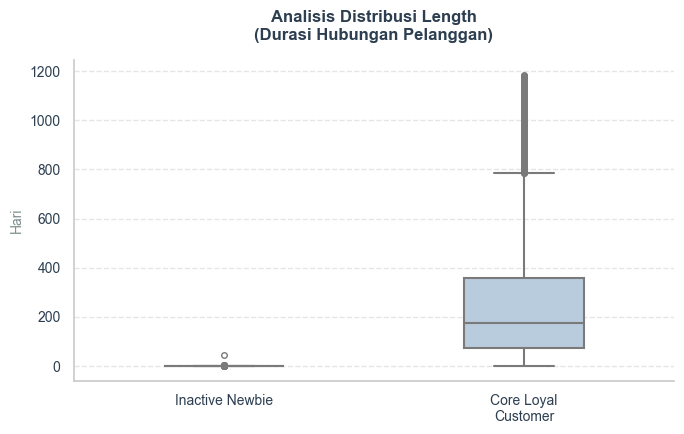

 Ringkasan Statistik Deskriptif untuk Variabel: Length


,Length (MIN),Length (MAX),Length (MEAN),Length (MEDIAN)
Klaster,,,,
Core Loyal Customer,1.00,1185.00,261.01,175.00
Inactive Newbie,0.00,43.00,0.01,0.00


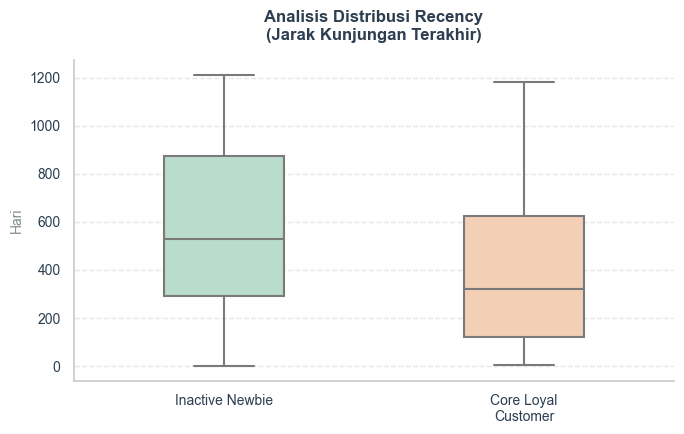

 Ringkasan Statistik Deskriptif untuk Variabel: Recency


,Recency (MIN),Recency (MAX),Recency (MEAN),Recency (MEDIAN)
Klaster,,,,
Core Loyal Customer,6.00,1183.00,394.58,321.00
Inactive Newbie,0.00,1212.00,577.98,530.00


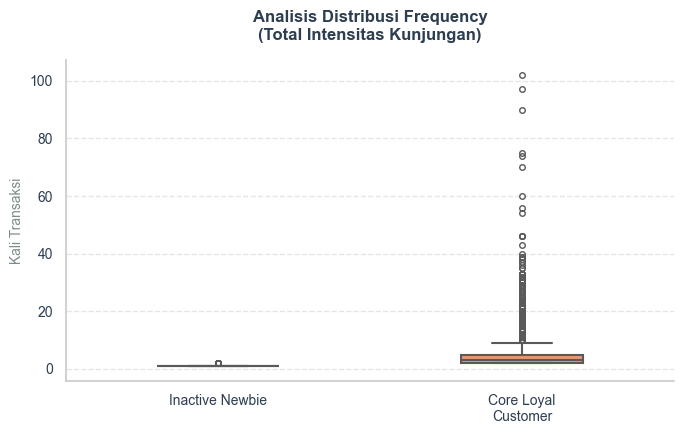

 Ringkasan Statistik Deskriptif untuk Variabel: Frequency


,Frequency (MIN),Frequency (MAX),Frequency (MEAN),Frequency (MEDIAN)
Klaster,,,,
Core Loyal Customer,2.00,102.00,4.44,3.00
Inactive Newbie,1.00,2.00,1.00,1.00


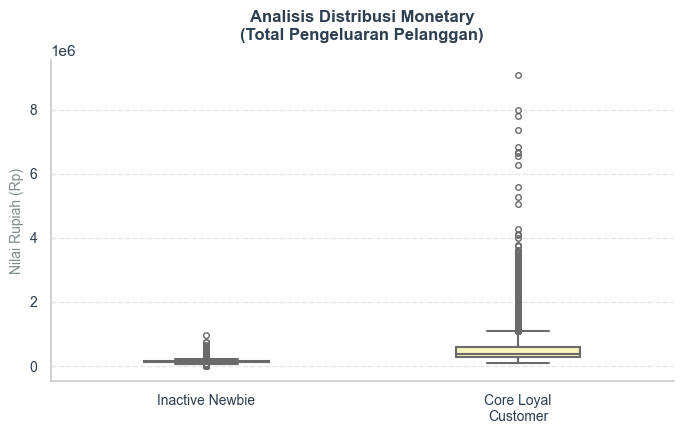

 Ringkasan Statistik Deskriptif untuk Variabel: Monetary


,Monetary (MIN),Monetary (MAX),Monetary (MEAN),Monetary (MEDIAN)
Klaster,,,,
Core Loyal Customer,100000.00,9085000.00,541706.37,375000.00
Inactive Newbie,0.00,970000.00,144872.54,135000.00


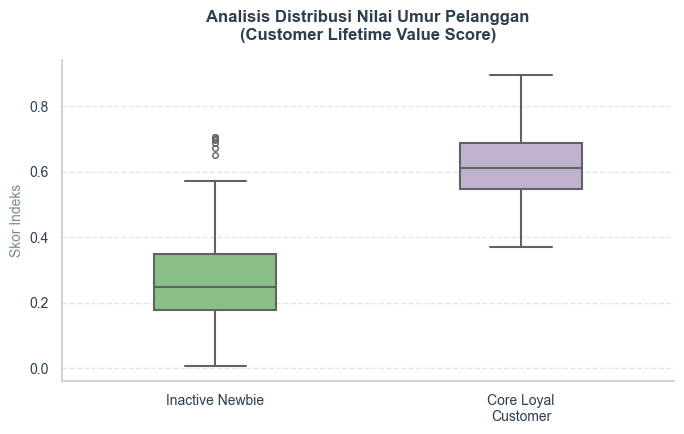

 Ringkasan Statistik Deskriptif untuk Variabel: CLV Score


,CLV Score (MIN),CLV Score (MAX),CLV Score (MEAN),CLV Score (MEDIAN)
Klaster,,,,
Core Loyal Customer,0.37,0.90,0.62,0.61
Inactive Newbie,0.01,0.71,0.26,0.25


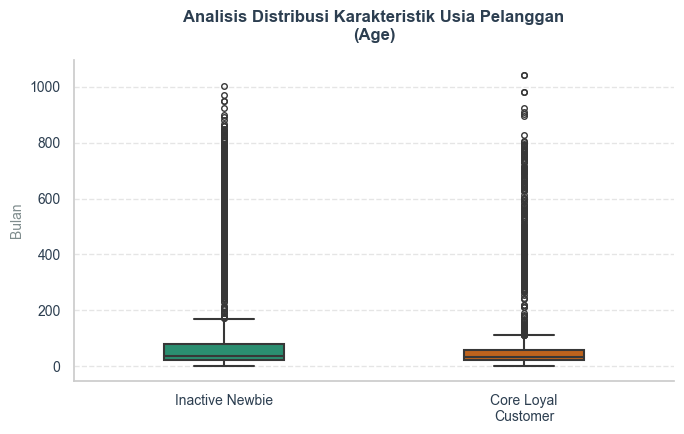

 Ringkasan Statistik Deskriptif untuk Variabel: Age (Bulan)


,Age (Bulan) (MIN),Age (Bulan) (MAX),Age (Bulan) (MEAN),Age (Bulan) (MEDIAN)
Klaster,,,,
Core Loyal Customer,1,1042,72.90,35.00
Inactive Newbie,1,1003,106.03,37.00


In [105]:
import textwrap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from babyspa_data.models.customer_segment import CustomerSegment

# ==============================================================================
# 1. EKSTRAKSI DATA MENGGUNAKAN DJANGO QUERYSET
# ==============================================================================
# Menarik data menggunakan select_related untuk efisiensi join tabel di background
segments_queryset = CustomerSegment.objects.filter(
    cluster_lrfm__k_value=2
).select_related('cluster_lrfm__lrfm_reference')

data_list = []
for segment in segments_queryset:
    data_list.append({
        'Klaster': segment.cluster_lrfm.lrfm_reference.group_name if segment.cluster_lrfm else "Unclustered",
        'Length': segment.l_real,
        'Recency': segment.r_real,
        'Frequency': segment.f_real,
        'Monetary': segment.m_real,
        'CLV Score': segment.clv_score,
        'Age (Bulan)': segment.age
    })

df = pd.DataFrame(data_list)

# Set tema dasar visualisasi (Clean style untuk jurnal/tesis)
sns.set_theme(style="whitegrid", rc={"grid.linestyle": "--", "grid.alpha": 0.5})

# Bungkus nama klaster yang panjang agar muat secara horizontal rata di sumbu X
df['Klaster_Label'] = df['Klaster'].apply(lambda x: "\n".join(textwrap.wrap(x, width=15)))


# ==============================================================================
# 2. FUNGSI GENERATOR ANALISIS ITERATIF PER VARIABEL
# ==============================================================================
def generate_variable_analysis(feature_name, title_text, y_label, color_palette="Set2"):
    if df.empty:
        print(f"⚠ Data kosong, tidak bisa memproses variabel {feature_name}.")
        return
        
    # A. Render Boxplot Tunggal (Decluttered)
    fig, ax = plt.subplots(figsize=(7, 4.5))
    
    sns.boxplot(
        ax=ax,
        x='Klaster_Label', 
        y=feature_name, 
        data=df, 
        palette=color_palette,
        hue='Klaster_Label',
        legend=False,
        width=0.4,
        linewidth=1.5,
        fliersize=4
    )
    
    ax.set_title(title_text, fontsize=12, fontweight='bold', pad=15, color='#2C3E50')
    ax.set_xlabel('', labelpad=0)
    ax.set_ylabel(y_label, fontsize=10, color='#7F8C8D')
    ax.tick_params(axis='both', labelsize=10, colors='#2C3E50')
    
    # Hapus garis bingkai atas dan kanan (Decluttering maksimal)
    sns.despine(ax=ax, top=True, right=True)
    
    plt.tight_layout()
    plt.show()
    
    # B. Render Tabel Ringkasan Deskriptif Presisi
    print(f" Ringkasan Statistik Deskriptif untuk Variabel: {feature_name}")
    stats = df.groupby('Klaster')[feature_name].agg(['min', 'max', 'mean', 'median'])
    stats.columns = [f"{feature_name} ({c.upper()})" for c in stats.columns]
    
    # Tampilkan dataframe dengan style format 2 desimal belakang koma dan gradasi warna
    display(stats.style.format(precision=2).background_gradient(cmap='YlGnBu', axis=0))
    print("\n" + "="*85 + "\n")


# ==============================================================================
# 3. EKSEKUSI PROSES SECARA BERURUTAN (ITERATIF)
# ==============================================================================
if df.empty:
    print("⚠ Peringatan: Tidak ada data yang ditemukan untuk k_value = 3 di dalam database kamu.")
else:
    print(f" Data Sukses Dimuat. Memulai kalkulasi visual untuk {len(df)} sampel pelanggan...\n")
    
    # 1. Variabel Length (L)
    generate_variable_analysis(
        feature_name='Length', 
        title_text='Analisis Distribusi Length\n(Durasi Hubungan Pelanggan)', 
        y_label='Hari',
        color_palette='Pastel1'
    )

    # 2. Variabel Recency (R)
    generate_variable_analysis(
        feature_name='Recency', 
        title_text='Analisis Distribusi Recency\n(Jarak Kunjungan Terakhir)', 
        y_label='Hari',
        color_palette='Pastel2'
    )

    # 3. Variabel Frequency (F)
    generate_variable_analysis(
        feature_name='Frequency', 
        title_text='Analisis Distribusi Frequency\n(Total Intensitas Kunjungan)', 
        y_label='Kali Transaksi',
        color_palette='Set2'
    )

    # 4. Variabel Monetary (M)
    generate_variable_analysis(
        feature_name='Monetary', 
        title_text='Analisis Distribusi Monetary\n(Total Pengeluaran Pelanggan)', 
        y_label='Nilai Rupiah (Rp)',
        color_palette='Set3'
    )

    # 5. Variabel Customer Lifetime Value (CLV Score)
    generate_variable_analysis(
        feature_name='CLV Score', 
        title_text='Analisis Distribusi Nilai Umur Pelanggan\n(Customer Lifetime Value Score)', 
        y_label='Skor Indeks',
        color_palette='Accent'
    )

    # 6. Variabel Usia Anak/Bayi (Age)
    generate_variable_analysis(
        feature_name='Age (Bulan)', 
        title_text='Analisis Distribusi Karakteristik Usia Pelanggan\n(Age)', 
        y_label='Bulan',
        color_palette='Dark2'
    )

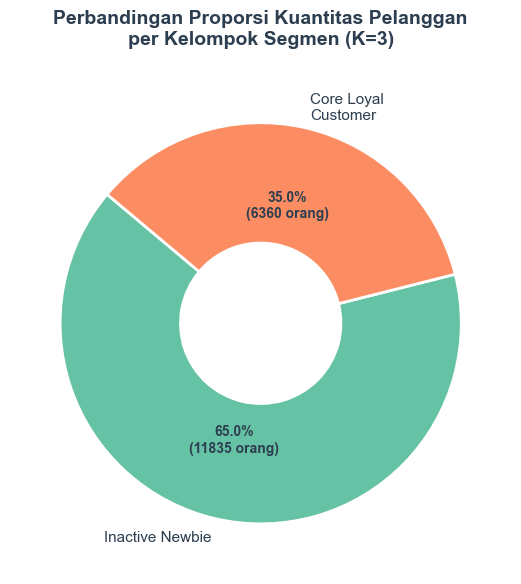

📊 Tabel Distribusi Volume Pelanggan:


,Jumlah Pelanggan,Persentase (%)
Klaster,,
Inactive Newbie,11835,65.050000
Core Loyal Customer,6360,34.950000


In [107]:
import textwrap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from babyspa_data.models.customer_segment import CustomerSegment

# ==============================================================================
# 1. EKSTRAKSI DATA & AGREGASI JUMLAH PELANGGAN PER KLASTER
# ==============================================================================
segments_queryset = CustomerSegment.objects.filter(
    cluster_lrfm__k_value=2
).select_related('cluster_lrfm__lrfm_reference')

data_list = []
for segment in segments_queryset:
    data_list.append({
        'Klaster': segment.cluster_lrfm.lrfm_reference.group_name if segment.cluster_lrfm else "Unclustered"
    })

df = pd.DataFrame(data_list)

if df.empty:
    print("⚠ Peringatan: Tidak ada data yang ditemukan untuk k_value = 3 di dalam database kamu.")
else:
    # Hitung volume (jumlah) pelanggan per kelompok
    cluster_counts = df['Klaster'].value_counts()
    
    # Bungkus teks nama klaster yang panjang agar rapi di label chart
    labels = [textwrap.fill(label, 15) for label in cluster_counts.index]
    sizes = cluster_counts.values

    # ==============================================================================
    # 2. VISUALISASI PIE CHART (DECLUTTERED STYLE)
    # ==============================================================================
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Fungsi kustom untuk memunculkan persentase sekaligus jumlah riil data di dalam lingkaran
    def make_autopct(values):
        def my_autopct(pct):
            total = sum(values)
            val = int(round(pct * total / 100.0))
            return f'{pct:.1f}%\n({val} orang)'
        return my_autopct

    # Membuat diagram pai menggunakan palet warna Set2 yang elegan
    colors = sns.color_palette("Set2", len(labels))
    
    wedges, texts, autotexts = ax.pie(
        sizes, 
        labels=labels, 
        autopct=make_autopct(sizes),
        startangle=140, 
        colors=colors,
        textprops=dict(color="#2C3E50", fontsize=11),
        wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2) # Efek Donut Chart yang modern & bersih
    )

    # Mempertegas teks persentase di dalam diagram
    for autotext in autotexts:
        autotext.set_fontsize(10)
        autotext.set_weight('bold')
        autotext.set_color('#2C3E50')

    ax.set_title('Perbandingan Proporsi Kuantitas Pelanggan\nper Kelompok Segmen (K=3)', 
                 fontsize=14, fontweight='bold', pad=20, color='#2C3E50')
    
    plt.tight_layout()
    plt.show()

    # ==============================================================================
    # 3. TABEL DISTRIBUSI FREKUENSI DATA
    # ==============================================================================
    print("📊 Tabel Distribusi Volume Pelanggan:")
    summary_table = pd.DataFrame({
        'Jumlah Pelanggan': sizes,
        'Persentase (%)': (sizes / sum(sizes) * 100).round(2)
    }, index=cluster_counts.index)
    
    display(summary_table.style.background_gradient(cmap='YlGnBu', axis=0))

### Komparasi k=2 dan k=3

🚀 Data Sukses Dimuat. Memulai komparasi visual campuran untuk 36390 sampel data...



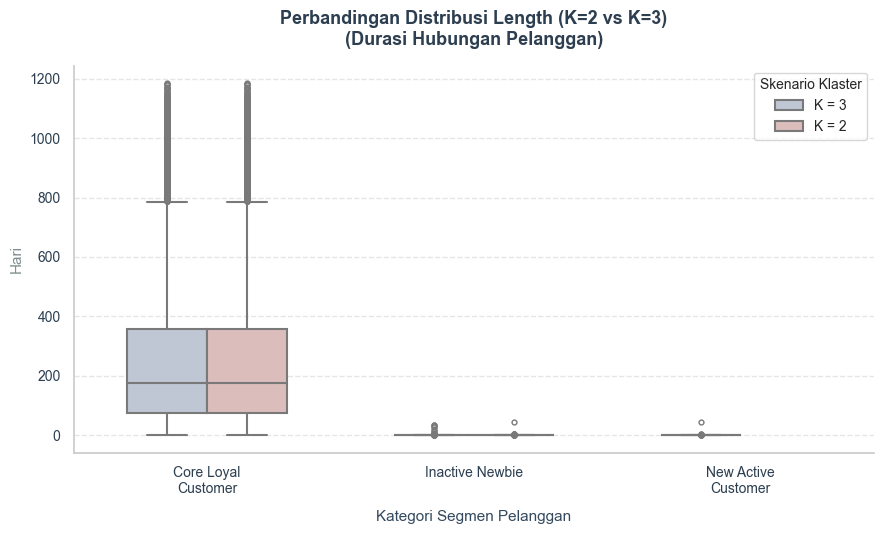

📊 Ringkasan Statistik Deskriptif Komparatif untuk Variabel: Length


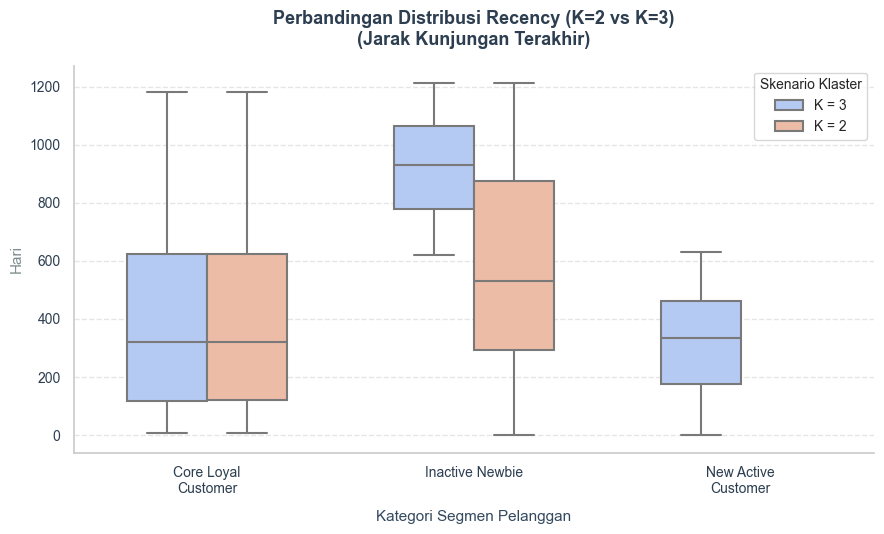

📊 Ringkasan Statistik Deskriptif Komparatif untuk Variabel: Recency


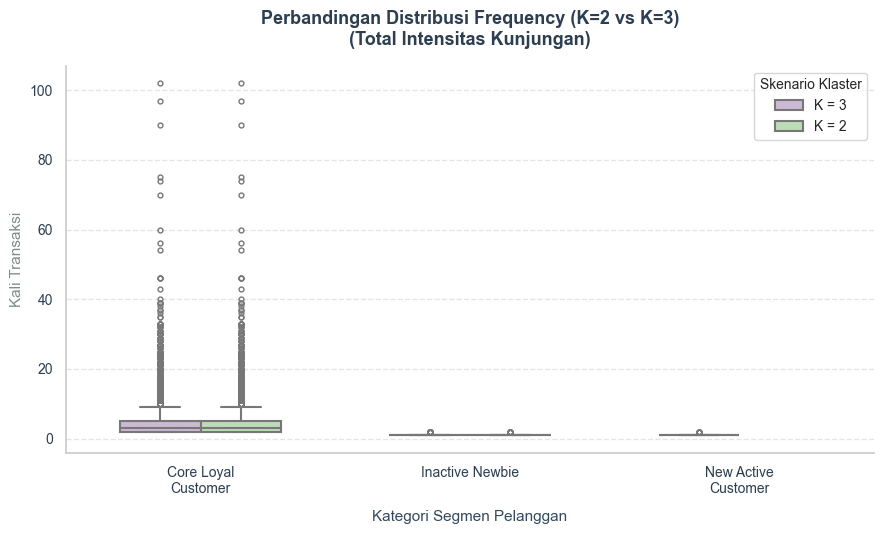

📊 Ringkasan Statistik Deskriptif Komparatif untuk Variabel: Frequency


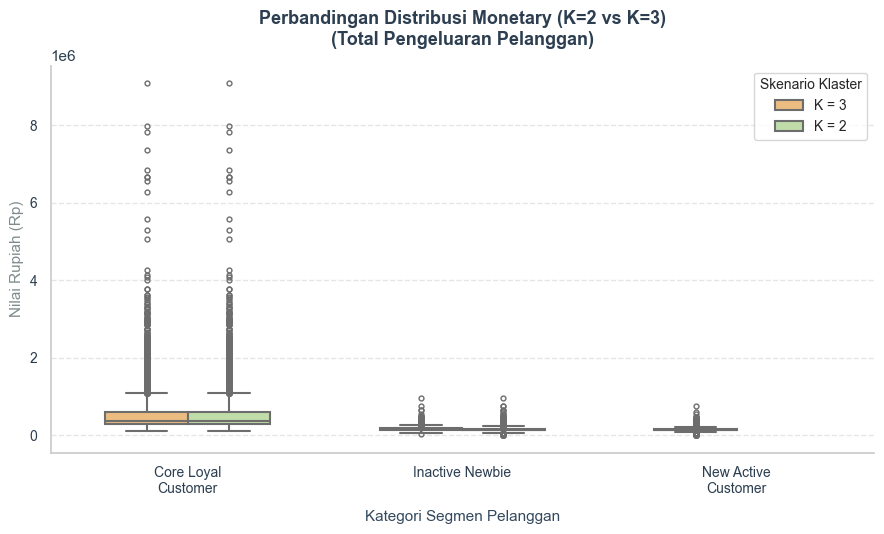

📊 Ringkasan Statistik Deskriptif Komparatif untuk Variabel: Monetary


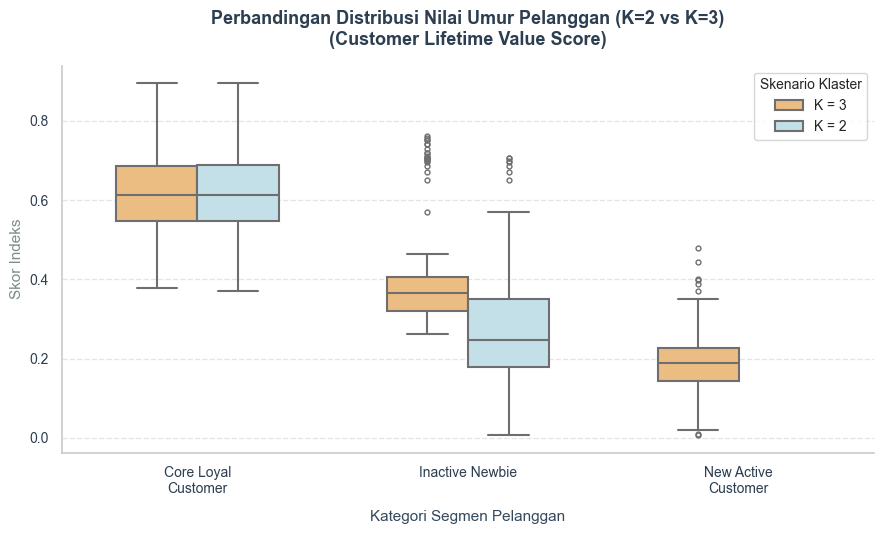

📊 Ringkasan Statistik Deskriptif Komparatif untuk Variabel: CLV Score


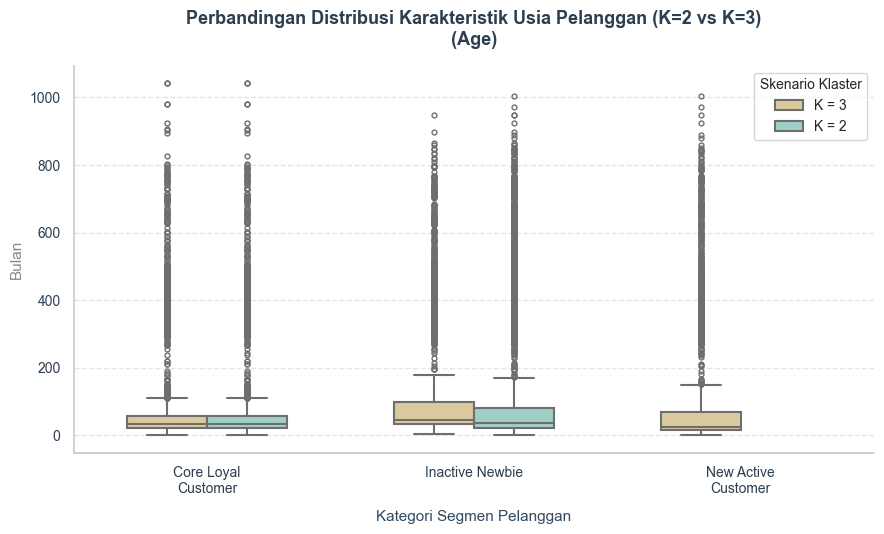

📊 Ringkasan Statistik Deskriptif Komparatif untuk Variabel: Age (Bulan)


In [108]:
import textwrap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from babyspa_data.models.customer_segment import CustomerSegment

# ==============================================================================
# 1. EKSTRAKSI DATA MULTI-SKENARIO (K=2 DAN K=3)
# ==============================================================================
# Menarik seluruh data segmentasi yang berada pada skenario K=2 dan K=3
segments_queryset = CustomerSegment.objects.filter(
    cluster_lrfm__k_value__in=[2, 3]
).select_related('cluster_lrfm__lrfm_reference')

data_list = []
for segment in segments_queryset:
    k_val = segment.cluster_lrfm.k_value if segment.cluster_lrfm else None
    group_name = segment.cluster_lrfm.lrfm_reference.group_name if segment.cluster_lrfm and segment.cluster_lrfm.lrfm_reference else "Unclustered"
    
    data_list.append({
        'K_Value': f"K = {k_val}" if k_val else "Unknown",
        'Klaster': group_name,
        'Length': segment.l_real,
        'Recency': segment.r_real,
        'Frequency': segment.f_real,
        'Monetary': segment.m_real,
        'CLV Score': segment.clv_score,
        'Age (Bulan)': segment.age
    })

df_all = pd.DataFrame(data_list)

# Set tema dasar visualisasi (Clean style untuk jurnal/tesis)
sns.set_theme(style="whitegrid", rc={"grid.linestyle": "--", "grid.alpha": 0.5})

if not df_all.empty:
    # Bungkus nama klaster yang panjang agar muat secara horizontal di sumbu X
    df_all['Klaster_Label'] = df_all['Klaster'].apply(lambda x: "\n".join(textwrap.wrap(x, width=15)))
    pd.options.display.float_format = '{:,.2f}'.format


# ==============================================================================
# 2. FUNGSI GENERATOR PERBANDINGAN CAMPURAN (SIDE-BY-SIDE)
# ==============================================================================
def generate_comparative_analysis(feature_name, title_text, y_label, color_palette="Set2"):
    if df_all.empty:
        print(f"⚠ Data kosong, tidak bisa memproses variabel {feature_name}.")
        return
        
    # A. Render Boxplot Perbandingan Berdampingan (K=2 vs K=3)
    fig, ax = plt.subplots(figsize=(9, 5.5))
    
    # Menggunakan hue='K_Value' untuk menciptakan visualisasi komparatif berpasangan
    sns.boxplot(
        ax=ax,
        x='Klaster_Label', 
        y=feature_name, 
        hue='K_Value',
        data=df_all, 
        palette=color_palette,
        width=0.6,
        linewidth=1.5,
        fliersize=3.5
    )
    
    ax.set_title(title_text, fontsize=13, fontweight='bold', pad=15, color='#2C3E50')
    ax.set_xlabel('Kategori Segmen Pelanggan', fontsize=11, labelpad=10, color='#34495E')
    ax.set_ylabel(y_label, fontsize=11, color='#7F8C8D')
    ax.tick_params(axis='both', labelsize=10, colors='#2C3E50')
    
    # Pengaturan Posisi Legend agar rapi dan tidak menutupi data
    ax.legend(title='Skenario Klaster', title_fontsize=10, fontsize=10, loc='upper right')
    
    # Hapus garis bingkai atas dan kanan (Decluttering maksimal)
    sns.despine(ax=ax, top=True, right=True)
    
    plt.tight_layout()
    plt.show()
    
    # B. Render Tabel Ringkasan Deskriptif Komparatif Multi-level Index
    print(f"📊 Ringkasan Statistik Deskriptif Komparatif untuk Variabel: {feature_name}")
    stats = df_all.groupby(['K_Value', 'Klaster'])[feature_name].agg(['min', 'max', 'mean', 'median'])
    stats.columns = [f"{c.upper()}" for c in stats.columns]
    
    # Tampilkan dataframe dengan format presisi dan gradasi warna per kelompok skenario
    display(stats.style.format(precision=2).background_gradient(cmap='YlGnBu', axis=0))
    print("\n" + "="*95 + "\n")


# ==============================================================================
# 3. EKSEKUSI PROSES KOMPARATIF SECARA BERURUTAN
# ==============================================================================
if df_all.empty:
    print("⚠ Peringatan: Tidak ada data yang ditemukan untuk K=2 maupun K=3 di dalam database.")
else:
    print(f"🚀 Data Sukses Dimuat. Memulai komparasi visual campuran untuk {len(df_all)} sampel data...\n")
    
    # 1. Variabel Length (L)
    generate_comparative_analysis(
        feature_name='Length', 
        title_text='Perbandingan Distribusi Length (K=2 vs K=3)\n(Durasi Hubungan Pelanggan)', 
        y_label='Hari',
        color_palette='vlag'
    )

    # 2. Variabel Recency (R)
    generate_comparative_analysis(
        feature_name='Recency', 
        title_text='Perbandingan Distribusi Recency (K=2 vs K=3)\n(Jarak Kunjungan Terakhir)', 
        y_label='Hari',
        color_palette='coolwarm'
    )

    # 3. Variabel Frequency (F)
    generate_comparative_analysis(
        feature_name='Frequency', 
        title_text='Perbandingan Distribusi Frequency (K=2 vs K=3)\n(Total Intensitas Kunjungan)', 
        y_label='Kali Transaksi',
        color_palette='PRGn'
    )

    # 4. Variabel Monetary (M)
    generate_comparative_analysis(
        feature_name='Monetary', 
        title_text='Perbandingan Distribusi Monetary (K=2 vs K=3)\n(Total Pengeluaran Pelanggan)', 
        y_label='Nilai Rupiah (Rp)',
        color_palette='Spectral'
    )

    # 5. Variabel Customer Lifetime Value (CLV Score)
    generate_comparative_analysis(
        feature_name='CLV Score', 
        title_text='Perbandingan Distribusi Nilai Umur Pelanggan (K=2 vs K=3)\n(Customer Lifetime Value Score)', 
        y_label='Skor Indeks',
        color_palette='RdYlBu'
    )

    # 6. Variabel Usia Anak/Bayi (Age)
    generate_comparative_analysis(
        feature_name='Age (Bulan)', 
        title_text='Perbandingan Distribusi Karakteristik Usia Pelanggan (K=2 vs K=3)\n(Age)', 
        y_label='Bulan',
        color_palette='BrBG'
    )

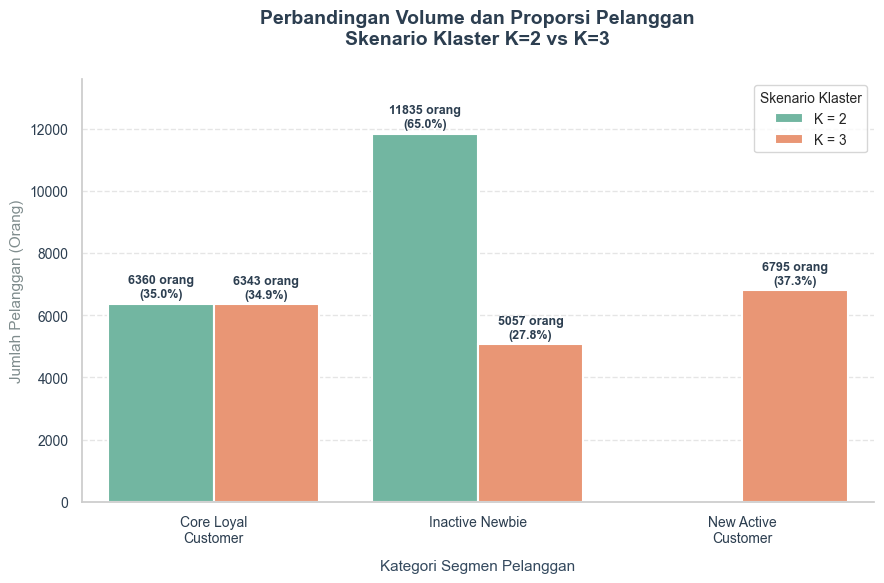

📊 Tabel Ringkasan Distribusi Volume Pelanggan Multi-Skenario:


In [109]:
import textwrap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from babyspa_data.models.customer_segment import CustomerSegment

# ==============================================================================
# 1. EKSTRAKSI DATA & AGREGASI MULTI-SKENARIO (K=2 DAN K=3)
# ==============================================================================
# Menarik data segmentasi untuk skenario K=2 dan K=3 sekaligus
segments_queryset = CustomerSegment.objects.filter(
    cluster_lrfm__k_value__in=[2, 3]
).select_related('cluster_lrfm__lrfm_reference')

data_list = []
for segment in segments_queryset:
    k_val = segment.cluster_lrfm.k_value if segment.cluster_lrfm else None
    group_name = segment.cluster_lrfm.lrfm_reference.group_name if segment.cluster_lrfm and segment.cluster_lrfm.lrfm_reference else "Unclustered"
    
    data_list.append({
        'Skenario': f"K = {k_val}" if k_val else "Unknown",
        'Klaster': group_name
    })

df_all = pd.DataFrame(data_list)

if df_all.empty:
    print("⚠ Peringatan: Tidak ada data K=2 maupun K=3 yang ditemukan di dalam database.")
else:
    # 2. HITUNG DISTRIBUSI FREKUENSI DAN PERSENTASE DATA
    # Membuat tabel silang (crosstab) antara Skenario K-Value dan Kategori Klaster
    summary_df = pd.crosstab(df_all['Klaster'], df_all['Skenario']).reset_index()
    
    # Melt dataframe agar sesuai dengan format visualisasi bertingkat Seaborn
    df_plot = pd.melt(summary_df, id_vars=['Klaster'], value_vars=['K = 2', 'K = 3'], 
                      var_name='Skenario_K', value_name='Jumlah_Pelanggan')
    
    # Hitung total pelanggan per skenario untuk kalkulasi persentase di atas bar
    total_k2 = df_plot[df_plot['Skenario_K'] == 'K = 2']['Jumlah_Pelanggan'].sum()
    total_k3 = df_plot[df_plot['Skenario_K'] == 'K = 3']['Jumlah_Pelanggan'].sum()
    
    # Bungkus teks nama klaster agar rapi secara horizontal di sumvu X
    df_plot['Klaster_Label'] = df_plot['Klaster'].apply(lambda x: "\n".join(textwrap.wrap(x, width=15)))

    # ==============================================================================
    # 3. VISUALISASI GROUPED BAR CHART (COMPACT & DECLUTTERED STYLE)
    # ==============================================================================
    sns.set_theme(style="whitegrid", rc={"grid.linestyle": "--", "grid.alpha": 0.5})
    fig, ax = plt.subplots(figsize=(9, 6))
    
    # Render grafik batang berdampingan
    bar_plot = sns.barplot(
        ax=ax,
        x='Klaster_Label',
        y='Jumlah_Pelanggan',
        hue='Skenario_K',
        data=df_plot,
        palette='Set2',
        edgecolor='white',
        linewidth=1.5
    )
    
    # Menambahkan teks jumlah riil dan persentase di atas setiap batang grafis
    for p in ax.patches:
        height = p.get_height()
        if height > 0: # Hanya memproses batang yang memiliki nilai data
            # Cari tahu batang ini milik K=2 atau K=3 berdasarkan urutan patch legend
            current_hue = 'K = 2' if p.get_x() % 1 < 0.4 else 'K = 3'
            total_base = total_k2 if current_hue == 'K = 2' else total_k3
            pct = (height / total_base) * 100
            
            ax.annotate(f'{int(height)} orang\n({pct:.1f}%)',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='center',
                        xytext=(0, 12),
                        textcoords='offset points',
                        fontsize=9, fontweight='bold', color='#2C3E50')
            
    ax.set_title('Perbandingan Volume dan Proporsi Pelanggan\nSkenario Klaster K=2 vs K=3', 
                 fontsize=14, fontweight='bold', pad=25, color='#2C3E50')
    ax.set_xlabel('Kategori Segmen Pelanggan', fontsize=11, labelpad=10, color='#34495E')
    ax.set_ylabel('Jumlah Pelanggan (Orang)', fontsize=11, color='#7F8C8D')
    ax.tick_params(axis='both', labelsize=10, colors='#2C3E50')
    
    # Atur margin vertikal atas agar teks persentase tidak terpotong bingkai
    ax.set_ylim(0, df_plot['Jumlah_Pelanggan'].max() * 1.15)
    ax.legend(title='Skenario Klaster', title_fontsize=10, fontsize=10, loc='upper right')
    
    sns.despine(ax=ax, top=True, right=True)
    plt.tight_layout()
    plt.show()

    # ==============================================================================
    # 4. TABEL DISTRIBUSI FREKUENSI KOMPARATIF (MULTI-LEVEL ANALYSIS)
    # ==============================================================================
    print("📊 Tabel Ringkasan Distribusi Volume Pelanggan Multi-Skenario:")
    
    # Bangun struktur tabel silang murni yang memuat angka mutlak dan proporsi
    pivot_table = df_all.groupby(['Skenario', 'Klaster']).size().to_frame('Jumlah Pelanggan')
    pivot_table['Persentase (%)'] = pivot_table.groupby(level=0, group_keys=False).apply(
        lambda x: (x / x.sum() * 100).round(2)
    )
    
    display(pivot_table.style.format(precision=2).background_gradient(cmap='YlGnBu', axis=0))

## FCM Uji

In [115]:
import pandas as pd
import numpy as np
import skfuzzy as fuzz
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Impor model Django
from babyspa_data.models.customer_segment import CustomerSegment

# ==============================================================================
# 1. EKSTRAKSI DATA LRFM NORMALISASI
# ==============================================================================
print("1. Mengambil data LRFM Normalisasi pelanggan dari database...")

# Memakai active_objects untuk memastikan hanya data aktif yang ditarik
segments_queryset = CustomerSegment.active_objects.all()

# Memakai dictionary untuk memastikan customer_id unik dan mencegah duplikasi
data_dict = {}
for segment in segments_queryset:
    if segment.customer_id not in data_dict:
        data_dict[segment.customer_id] = {
            'customer_id': segment.customer_id,
            # LANGSUNG MENGAMBIL DATA NORMALISASI DARI DATABASE
            'L_norm': segment.l_normalized,
            'R_norm': segment.r_normalized,
            'F_norm': segment.f_normalized,
            'M_norm': segment.m_normalized
        }

# Mengubah dictionary kembali menjadi list
data_list = list(data_dict.values())
df_norm_db = pd.DataFrame(data_list)

# Cek ketersediaan data
if df_norm_db.empty:
    print("⚠ Data kosong! Pastikan ada data pelanggan aktif di database.")
elif len(df_norm_db) < 7:
    print("⚠ Jumlah data terlalu sedikit untuk dievaluasi hingga 6 klaster!")
else:
    print(f"   ➜ Berhasil mengekstrak {len(df_norm_db)} data pelanggan unik.\n")
    
    # ==============================================================================
    # 2. PERSIAPAN MATRIKS UNTUK FCM
    # ==============================================================================
    # Hapus kolom customer_id karena algoritma hanya butuh angka LRFM-nya saja
    fitur_lrfm_norm = ['L_norm', 'R_norm', 'F_norm', 'M_norm']
    df_norm_murni = df_norm_db[fitur_lrfm_norm]
    
    # skfuzzy membutuhkan format matriks transpose: (n_features, n_samples)
    data_untuk_fcm = df_norm_murni.values.T 
    
    # ==============================================================================
    # 3. PENCARIAN NILAI C OPTIMAL (FCM LOOPING)
    # ==============================================================================
    print("3. Memulai proses evaluasi Fuzzy C-Means untuk C = 2 hingga 6...\n")
    
    m_fuzzifier = 2.0      # Standar akademis untuk fuzzifier
    error_threshold = 1e-5 # Ambang batas konvergensi (epsilon)
    max_iter = 1000        # Maksimal iterasi
    
    hasil_evaluasi = []

    # Menguji kandidat C dari 2 sampai 6
    for c in range(2, 7):
        # Menjalankan algoritma Fuzzy C-Means
        cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
            data_untuk_fcm, 
            c=c, 
            m=m_fuzzifier, 
            error=error_threshold, 
            maxiter=max_iter, 
            init=None
        )
        
        # A. Hitung Partition Entropy (PE)
        u_safe = np.fmax(u, np.finfo(np.float64).eps)
        pe_score = -np.mean(np.sum(u_safe * np.log(u_safe), axis=0))
        
        # B. Defuzzifikasi: Ubah probabilitas menjadi label kaku 
        cluster_labels = np.argmax(u, axis=0)
        
        # C. Hitung Metrik Evaluasi Diskrit (dengan pengaman)
        # Hitung skor menggunakan df_norm_murni yang berisi data normalisasi dari database
        if len(set(cluster_labels)) > 1:
            sil_score = silhouette_score(df_norm_murni, cluster_labels)
            dbi_score = davies_bouldin_score(df_norm_murni, cluster_labels)
        else:
            sil_score = 0.0
            dbi_score = 999.0 
            
        # Simpan hasil
        hasil_evaluasi.append({
            'Nilai C': c,
            'FPC (Mendekati 1 Terbaik)': round(fpc, 4),
            'PE (Mendekati 0 Terbaik)': round(pe_score, 4),
            'Silhouette (Mendekati 1 Terbaik)': round(sil_score, 4),
            'DBI (Semakin Kecil Terbaik)': round(dbi_score, 4)
        })

    # ==============================================================================
    # 4. TAMPILKAN DAN SIMPAN HASIL EVALUASI
    # ==============================================================================
    df_hasil = pd.DataFrame(hasil_evaluasi)
    df_hasil.set_index('Nilai C', inplace=True)
    
    # 4A. Cetak format teks rapi ke Terminal
    print("="*90)
    print(" TABEL EVALUASI JUMLAH KLASTER (C) OPTIMAL - FUZZY C-MEANS")
    print("="*90)
    print(df_hasil.to_string())
    print("="*90)
    
    # 4B. Ekspor ke CSV 
    filepath_csv = "hasil_evaluasi_fcm.csv"
    df_hasil.to_csv(filepath_csv)
    print(f"\n✅ Hasil evaluasi telah berhasil disimpan ke file: {filepath_csv}")
    
    # 4C. Tampilkan dengan warna jika dijalankan di Jupyter Notebook
    try:
        from IPython.display import display
        display(df_hasil.style.highlight_max(subset=['FPC (Mendekati 1 Terbaik)', 'Silhouette (Mendekati 1 Terbaik)'], color='lightgreen')
                             .highlight_min(subset=['PE (Mendekati 0 Terbaik)', 'DBI (Semakin Kecil Terbaik)'], color='lightgreen'))
    except ImportError:
        pass

1. Mengambil data LRFM Normalisasi pelanggan dari database...
   ➜ Berhasil mengekstrak 18195 data pelanggan unik.

3. Memulai proses evaluasi Fuzzy C-Means untuk C = 2 hingga 6...

 TABEL EVALUASI JUMLAH KLASTER (C) OPTIMAL - FUZZY C-MEANS
         FPC (Mendekati 1 Terbaik)  PE (Mendekati 0 Terbaik)  Silhouette (Mendekati 1 Terbaik)  DBI (Semakin Kecil Terbaik)
Nilai C                                                                                                                    
2                             0.84                      0.29                              0.60                         0.66
3                             0.74                      0.48                              0.52                         0.64
4                             0.68                      0.62                              0.46                         0.92
5                             0.61                      0.77                              0.38                         0.97
6              

,FPC (Mendekati 1 Terbaik),PE (Mendekati 0 Terbaik),Silhouette (Mendekati 1 Terbaik),DBI (Semakin Kecil Terbaik)
Nilai C,,,,
2,0.837400,0.285600,0.599000,0.664500
3,0.741700,0.477300,0.517200,0.639800
4,0.680200,0.616300,0.458900,0.918900
5,0.608800,0.770000,0.384200,0.974900
6,0.605900,0.812500,0.407900,0.868400


Memproses reduksi dimensi PCA dan visualisasi FCM Bergradien...
Informasi data LRFM yang berhasil dipertahankan (PC1 + PC2): 92.13%



c:\babyspa-data\sunny_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
c:\babyspa-data\sunny_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
c:\babyspa-data\sunny_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


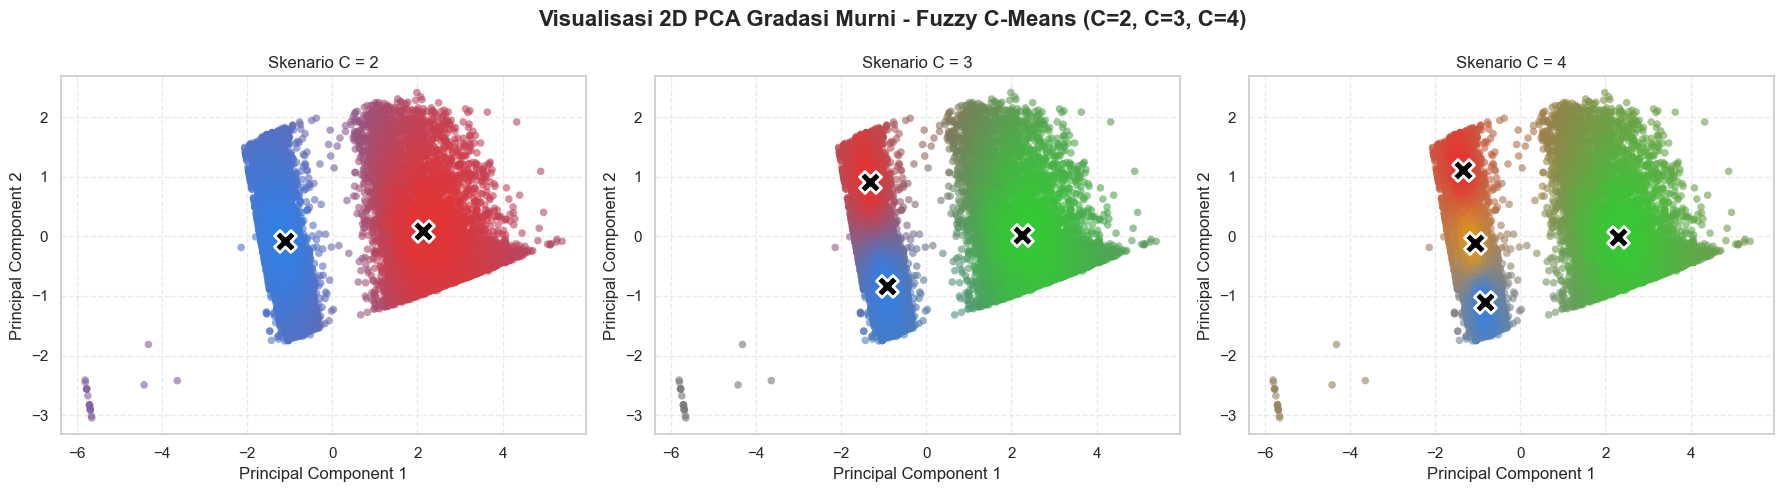

In [117]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import skfuzzy as fuzz

print("Memproses reduksi dimensi PCA dan visualisasi FCM Bergradien...")

# ==============================================================================
# 1. REDUKSI DIMENSI DENGAN PCA (4D -> 2D)
# ==============================================================================
# Memakai df_norm_murni dari blok sebelumnya (yang ditarik langsung dari database)
data_untuk_fcm = df_norm_murni.values.T

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_norm_murni)

explained_variance = pca.explained_variance_ratio_
print(f"Informasi data LRFM yang berhasil dipertahankan (PC1 + PC2): {(sum(explained_variance)*100):.2f}%\n")

df_pca = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])

# ==============================================================================
# 2. PERSIAPAN MATRIKS WARNA DASAR (RGB) & KANVAS PLOT
# ==============================================================================
# Definisi warna murni untuk maksimal 4 klaster: Merah, Biru, Hijau, dan Oranye
base_colors = np.array([
    [0.9, 0.2, 0.2],  # Klaster 0: Merah
    [0.2, 0.5, 0.9],  # Klaster 1: Biru
    [0.2, 0.8, 0.2],  # Klaster 2: Hijau
    [0.9, 0.6, 0.1]   # Klaster 3: Oranye (Khusus untuk C=4)
])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Visualisasi 2D PCA Gradasi Murni - Fuzzy C-Means (C=2, C=3, C=4)', fontsize=16, fontweight='bold')

kandidat_c = [2, 3, 4]
m_fuzzifier = 2.0
error_threshold = 1e-5
max_iter = 1000

# ==============================================================================
# 3. PROSES FCM DAN PLOTTING GRADASI
# ==============================================================================
for idx, c in enumerate(kandidat_c):
    # Jalankan algoritma FCM
    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        data_untuk_fcm, c=c, m=m_fuzzifier, error=error_threshold, maxiter=max_iter, init=None
    )
    
    # PERKALIHAN MATRIKS UNTUK GRADASI WARNA
    # u.T berukuran (jumlah_data, C), base_colors[:c] berukuran (C, 3)
    # Hasilnya adalah warna RGB spesifik untuk tiap-tiap pelanggan
    warna_campuran = np.dot(u.T, base_colors[:c])
    
    # Memastikan nilai RGB tidak keluar batas (0 sampai 1) akibat pembulatan
    warna_campuran = np.clip(warna_campuran, 0, 1)
    
    # Transformasi koordinat titik pusat (centroid) dari 4D ke 2D
    centroid_pca = pca.transform(cntr)
    
    # Visualisasi titik-titik pelanggan memakai plt.scatter bawaan agar bisa menerima RGB kustom
    axes[idx].scatter(
        df_pca['PC1'], df_pca['PC2'], 
        c=warna_campuran, 
        alpha=0.6, 
        s=30, 
        edgecolors='none'
    )
    
    # Visualisasi titik pusat (Centroid) dengan tanda "X" hitam besar
    axes[idx].scatter(
        centroid_pca[:, 0], centroid_pca[:, 1], 
        marker='X', s=250, c='black', edgecolors='white', linewidth=2, zorder=10
    )
    
    axes[idx].set_title(f'Skenario C = {c}')
    axes[idx].set_xlabel('Principal Component 1')
    axes[idx].set_ylabel('Principal Component 2')
    axes[idx].grid(True, linestyle='--', alpha=0.4)

# Rapikan spasi antar-grafik dan tampilkan
plt.tight_layout()
plt.show()

In [122]:
import pandas as pd
import numpy as np
import skfuzzy as fuzz
from scipy import stats

# Impor model Django
from babyspa_data.models.customer_segment import CustomerSegment

print("1. Mengambil data pelanggan (Riil & Normalisasi) dari database...")

# Mengambil data dari database
segments_queryset = CustomerSegment.active_objects.all()
data_dict = {}

for segment in segments_queryset:
    if segment.customer_id not in data_dict:
        data_dict[segment.customer_id] = {
            'customer_id': segment.customer_id,
            # Data Riil untuk Profiling & Statistik (Kruskal-Wallis)
            'L': segment.l_real,
            'R': segment.r_real,
            'F': segment.f_real,
            'M': segment.m_real,
            # Data Normalisasi untuk Algoritma FCM
            'L_norm': segment.l_normalized,
            'R_norm': segment.r_normalized,
            'F_norm': segment.f_normalized,
            'M_norm': segment.m_normalized
        }

# Mengubah dictionary menjadi DataFrame
df_full = pd.DataFrame(list(data_dict.values()))

if df_full.empty:
    print("⚠ Data kosong! Pastikan ada data pelanggan aktif di database.")
else:
    # Memisahkan dataset sesuai fungsinya
    fitur_lrfm_real = ['L', 'R', 'F', 'M']
    fitur_lrfm_norm = ['L_norm', 'R_norm', 'F_norm', 'M_norm']
    
    # df_real murni berisi angka riil untuk pengujian
    df_real = df_full[fitur_lrfm_real]
    
    # data_untuk_fcm ditranspose khusus untuk skfuzzy
    data_untuk_fcm = df_full[fitur_lrfm_norm].values.T
    
    print("2. Melakukan Uji Statistik dan Pembuatan Profil LRFM...\n")
    
    kandidat_c = [2, 3, 4, 5, 6]
    m_fuzzifier = 2.0
    error_threshold = 1e-5
    max_iter = 1000
    
    # ==========================================================================
    # HITUNG RATA-RATA GLOBAL (GLOBAL MEAN)
    # ==========================================================================
    global_mean = df_real.mean()
    print("="*50)
    print(" RATA-RATA GLOBAL PELANGGAN (GLOBAL MEAN)")
    print("="*50)
    for f in fitur_lrfm_real:
        print(f" - {f} : {global_mean[f]:.2f}")
    print("="*50 + "\n")
    
    hasil_statistik = []
    hasil_profiling = []
    
    # ==========================================================================
    # LOOPING EVALUASI FCM UNTUK SETIAP NILAI C
    # ==========================================================================
    for c in kandidat_c:
        # Jalankan FCM memakai data normalisasi
        cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
            data_untuk_fcm, c=c, m=m_fuzzifier, error=error_threshold, maxiter=max_iter, init=None
        )
        
        # Defuzzifikasi
        cluster_labels = np.argmax(u, axis=0)
        
        # Tempelkan label klaster ke dalam dataframe riil
        df_real_temp = df_real.copy()
        df_real_temp['Cluster'] = cluster_labels
        
        # A. UJI KRUSKAL-WALLIS
        for fitur in fitur_lrfm_real:
            grup_data = [df_real_temp[df_real_temp['Cluster'] == i][fitur].values for i in range(c)]
            
            if all(len(g) > 0 for g in grup_data):
                stat, p_value = stats.kruskal(*grup_data)
                status = "Signifikan" if p_value < 0.05 else "TIDAK Signifikan"
            else:
                p_value = 1.0
                status = "Error (Ada Klaster Kosong)"
                
            hasil_statistik.append({
                'Skenario (C)': f"C={c}",
                'Variabel': fitur,
                'P-Value': p_value,
                'Kesimpulan': status
            })
    
        # B. PROFILING KLASTER (ATAS/BAWAH RATA-RATA GLOBAL)
        for i in range(c):
            profil_klaster = {'Skenario (C)': f"C={c}", 'Klaster': f"Klaster {i}"}
            pola_lrfm = ""
            
            for fitur in fitur_lrfm_real:
                if len(df_real_temp[df_real_temp['Cluster'] == i]) > 0:
                    cluster_mean = df_real_temp[df_real_temp['Cluster'] == i][fitur].mean()
                    
                    if cluster_mean > global_mean[fitur]:
                        profil_klaster[fitur] = f"{cluster_mean:.2f} (↑)"
                        pola_lrfm += f"{fitur}↑ "
                    else:
                        profil_klaster[fitur] = f"{cluster_mean:.2f} (↓)"
                        pola_lrfm += f"{fitur}↓ "
                else:
                    profil_klaster[fitur] = "-"
                    pola_lrfm += f"{fitur}- "
                    
            profil_klaster['Pola'] = pola_lrfm.strip()
            hasil_profiling.append(profil_klaster)
    
    # ==========================================================================
    # TAMPILKAN HASIL AKHIR
    # ==========================================================================
    df_stat = pd.DataFrame(hasil_statistik)
    df_stat['P-Value'] = df_stat['P-Value'].apply(lambda x: f"{x:.5e}")
    
    print(" TABEL 1: HASIL UJI KRUSKAL-WALLIS PADA NILAI RIIL (ALPHA = 0.05)")
    print("-" * 75)
    print(df_stat.to_string(index=False))
    print("-" * 75 + "\n")
    
    df_profil = pd.DataFrame(hasil_profiling)
    print(" TABEL 2: PROFILING LRFM (PERBANDINGAN TERHADAP GLOBAL MEAN)")
    print("-" * 85)
    print(df_profil.to_string(index=False))
    print("-" * 85)
    print("* Catatan: (↑) Di ATAS rata-rata global | (↓) Di BAWAH rata-rata global.")

1. Mengambil data pelanggan (Riil & Normalisasi) dari database...
2. Melakukan Uji Statistik dan Pembuatan Profil LRFM...

 RATA-RATA GLOBAL PELANGGAN (GLOBAL MEAN)
 - L : 91.24
 - R : 513.87
 - F : 2.20
 - M : 283584.45

 TABEL 1: HASIL UJI KRUSKAL-WALLIS PADA NILAI RIIL (ALPHA = 0.05)
---------------------------------------------------------------------------
Skenario (C) Variabel      P-Value Kesimpulan
         C=2        L  0.00000e+00 Signifikan
         C=2        R 2.00375e-272 Signifikan
         C=2        F  0.00000e+00 Signifikan
         C=2        M  0.00000e+00 Signifikan
         C=3        L  0.00000e+00 Signifikan
         C=3        R  0.00000e+00 Signifikan
         C=3        F  0.00000e+00 Signifikan
         C=3        M  0.00000e+00 Signifikan
         C=4        L  0.00000e+00 Signifikan
         C=4        R  0.00000e+00 Signifikan
         C=4        F  0.00000e+00 Signifikan
         C=4        M  0.00000e+00 Signifikan
         C=5        L  0.00000e+00 Sig